# Vertebra Segmentation with YOLOv8-seg

## Purpose
This notebook prepares data, trains, evaluates, and runs inference for vertebra segmentation on AP scoliosis radiographs.

## Scope
- multiclass vertebra segmentation
- corrected-mask priority when corrected masks are available
- YOLOv8m-seg experiments
- evaluation with YOLO metrics and fixed-subset Dice/IoU
- single-image inference checks

## Notes
- This notebook is intended for experiment tracking and team collaboration.
- Dataset and output paths should be configured in the setup/config section.
- Large generated artifacts such as checkpoints, exported datasets, and training runs should not be committed to Git.

In [ ]:
# Standard library
from pathlib import Path
import os
import json
import random
import warnings

# Data / numerics
import numpy as np
import pandas as pd

# Imaging
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

# Better display defaults
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (14, 6)

print("Imports loaded successfully.")

Imports loaded successfully.


## Setup

Before running this notebook, update the dataset and project paths in the configuration cell below.

This notebook supports:
- local execution
- Google Colab execution with Drive-mounted paths

Corrected masks are prioritized over original masks when available.

In [ ]:
# =========================================================
# Configuration
# =========================================================

CONFIG = {
    # Execution mode
    # Set to "colab" when running in Google Colab
    "mode": "colab",          # "local" or "colab"
    "seed": 42,

    # Local paths
    "local_dataset_root": Path("~/Desktop/Programming/Scoliosis_Dataset").expanduser(),
    "local_project_root": Path("~/Desktop/Programming/yolo_vertebra_seg").expanduser(),

    # Google Drive paths
    "drive_mount_point": Path("/content/drive"),
    "colab_drive_project_base": Path(
        "ADD DIRECTORY HERE"
    ),
    "colab_dataset_root": Path(
        "ADD DIRECTORY HERE"
    ),
    "colab_project_root": Path(
        "ADD DIRECTORY HERE"
    ),

    # Official files/folders
    "index_csv_name": "indice_dataset.csv",
    "class_dict_json_name": "diccionario_etiquetas_T1_T12_L1_L5.json",

    # Expected folders
    "required_dirs": [
        "Normal",
        "Scoliosis",
        "LabelBinaryJPG",
        "LabelMultiClass_ID_PNG",
        "LabelMultiClass_Color_JPG",
        "LabelMultiClass_Gray_JPG",
        "RadiographMetrics",
    ],

    # Corrected-mask support
    "corrected_multiclass_mask_rel_dir": "vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected",
    "prefer_corrected_masks": True,

    # Ignore list
    "ignore_mask_stems": [
        "LabelMulti_S_137",
    ],

    # Protected reference run for comparison
    # IMPORTANT: replace this string with your actual current best corrected-mask run name if needed.
    "protected_reference_run_name": "vertebra_yolov8m_seg_v9_corrected_masks_pretrained_all_current_corrected_priority_ignorelist_colab_strong_img960_seed42",

    # Official class expectations
    "num_classes_total": 18,     # 0..17
    "background_id": 0,
    "thoracic_ids": list(range(1, 13)),   # T1..T12
    "lumbar_ids": list(range(13, 18)),    # L1..L5

    # Visualization
    "num_random_checks": 5,
    "num_visual_examples": 3,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print(json.dumps(
    {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
    indent=2
))

In [ ]:
# =========================================================
# Colab + Drive path setup
# =========================================================

def detect_colab():
    try:
        import google.colab  # noqa
        return True
    except Exception:
        return False

IS_COLAB_RUNTIME = detect_colab()

if CONFIG["mode"] == "colab" or IS_COLAB_RUNTIME:
    RUN_ENV = "colab"

    from google.colab import drive
    drive.mount(str(CONFIG["drive_mount_point"]), force_remount=False)

    DATASET_ROOT = CONFIG["colab_dataset_root"]
    PROJECT_ROOT = CONFIG["colab_project_root"]
else:
    RUN_ENV = "local"
    DATASET_ROOT = CONFIG["local_dataset_root"]
    PROJECT_ROOT = CONFIG["local_project_root"]

# Main project output locations
EXPORTS_ROOT = PROJECT_ROOT / "exports"
TRAINING_RUNS_ROOT = PROJECT_ROOT / "training_runs"
META_ROOT = PROJECT_ROOT / "meta"

# Keep these folders persistent
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
EXPORTS_ROOT.mkdir(parents=True, exist_ok=True)
TRAINING_RUNS_ROOT.mkdir(parents=True, exist_ok=True)
META_ROOT.mkdir(parents=True, exist_ok=True)

print(f"RUN_ENV            : {RUN_ENV}")
print(f"DATASET_ROOT       : {DATASET_ROOT}")
print(f"PROJECT_ROOT       : {PROJECT_ROOT}")
print(f"EXPORTS_ROOT       : {EXPORTS_ROOT}")
print(f"TRAINING_RUNS_ROOT : {TRAINING_RUNS_ROOT}")
print(f"META_ROOT          : {META_ROOT}")

print("\nExistence checks:")
print(f"DATASET_ROOT exists       : {DATASET_ROOT.exists()}")
print(f"PROJECT_ROOT exists       : {PROJECT_ROOT.exists()}")
print(f"EXPORTS_ROOT exists       : {EXPORTS_ROOT.exists()}")
print(f"TRAINING_RUNS_ROOT exists : {TRAINING_RUNS_ROOT.exists()}")
print(f"META_ROOT exists          : {META_ROOT.exists()}")

In [ ]:
# =========================================================
# Dataset discovery
# =========================================================

def list_relative_files(folder: Path, exts=None):
    if not folder.exists():
        return []
    if exts is None:
        files = [p for p in folder.rglob("*") if p.is_file()]
    else:
        exts = {e.lower() for e in exts}
        files = [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts]
    return sorted(files)

print("Checking required folders...\n")
for d in CONFIG["required_dirs"]:
    full_path = DATASET_ROOT / d
    print(f"{d:30s} -> {'OK' if full_path.exists() else 'MISSING'}")

INDEX_CSV_PATH = DATASET_ROOT / CONFIG["index_csv_name"]
CLASS_DICT_PATH = DATASET_ROOT / CONFIG["class_dict_json_name"]

print("\nKey files:")
print("INDEX_CSV_PATH :", INDEX_CSV_PATH, "->", INDEX_CSV_PATH.exists())
print("CLASS_DICT_PATH:", CLASS_DICT_PATH, "->", CLASS_DICT_PATH.exists())

# Basic folder counts
folder_ext_map = {
    "Normal": [".jpg", ".jpeg", ".png"],
    "Scoliosis": [".jpg", ".jpeg", ".png"],
    "LabelBinaryJPG": [".jpg", ".jpeg", ".png"],
    "LabelMultiClass_ID_PNG": [".png"],
    "LabelMultiClass_Color_JPG": [".jpg", ".jpeg", ".png"],
    "LabelMultiClass_Gray_JPG": [".jpg", ".jpeg", ".png"],
}

print("\nApproximate file counts:")
for folder_name, exts in folder_ext_map.items():
    count = len(list_relative_files(DATASET_ROOT / folder_name, exts=exts))
    print(f"{folder_name:30s} -> {count}")

In [ ]:
# =========================================================
# Load class dictionary
# =========================================================

assert CLASS_DICT_PATH.exists(), f"Class dictionary not found: {CLASS_DICT_PATH}"

with open(CLASS_DICT_PATH, "r", encoding="utf-8") as f:
    class_dict = json.load(f)

multiclass_map = class_dict["mascara_multiclase_id_png"]
binary_map = class_dict["mascara_binaria"]

# Convert JSON string keys to int
multiclass_map = {int(k): v for k, v in multiclass_map.items()}
binary_map = {int(k): v for k, v in binary_map.items()}

print("Binary map:", binary_map)
print("\nMulticlass map:")
for k in sorted(multiclass_map.keys()):
    print(f"{k:2d} -> {multiclass_map[k]}")

expected_ids = set(range(18))
found_ids = set(multiclass_map.keys())

print("\nValidation:")
print("Expected IDs 0..17:", expected_ids == found_ids)
print("Missing IDs       :", sorted(expected_ids - found_ids))
print("Extra IDs         :", sorted(found_ids - expected_ids))

Binary map: {0: 'background', 255: 'spine'}

Multiclass map:
 0 -> background
 1 -> T1
 2 -> T2
 3 -> T3
 4 -> T4
 5 -> T5
 6 -> T6
 7 -> T7
 8 -> T8
 9 -> T9
10 -> T10
11 -> T11
12 -> T12
13 -> L1
14 -> L2
15 -> L3
16 -> L4
17 -> L5

Validation:
Expected IDs 0..17: True
Missing IDs       : []
Extra IDs         : []


In [ ]:
# =========================================================
# Load and validate indice_dataset.csv
# =========================================================

assert INDEX_CSV_PATH.exists(), f"Index CSV not found: {INDEX_CSV_PATH}"

df_index = pd.read_csv(INDEX_CSV_PATH)

print("Shape:", df_index.shape)
display(df_index.head())

print("\nColumns:")
print(list(df_index.columns))

Shape: (250, 9)


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN



Columns:
['grupo', 'imagen', 'id_paciente', 'ruta_radiografia', 'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png', 'ruta_mascara_multiclase_grises_jpg', 'ruta_mascara_multiclase_color_jpg', 'metricas_json']


In [ ]:
# Expected columns based on your current index format
required_columns = [
    "grupo",
    "imagen",
    "id_paciente",
    "ruta_radiografia",
    "ruta_mascara_binaria",
    "ruta_mascara_multiclase_id_png",
]

optional_columns = [
    "ruta_mascara_multiclase_grises_jpg",
    "ruta_mascara_multiclase_color_jpg",
    "metricas_json",
]

missing_required = [c for c in required_columns if c not in df_index.columns]
missing_optional = [c for c in optional_columns if c not in df_index.columns]

print("Missing required columns:", missing_required)
print("Missing optional columns:", missing_optional)

assert len(missing_required) == 0, f"Missing required columns: {missing_required}"
print("Required columns are present.")

Missing required columns: []
Missing optional columns: []
Required columns are present.


In [ ]:
# =========================================================
# Build absolute paths
# =========================================================

def resolve_from_root(rel_path):
    if pd.isna(rel_path):
        return None
    return (DATASET_ROOT / str(rel_path)).resolve()

CORRECTED_MULTICLASS_DIR = (DATASET_ROOT / CONFIG["corrected_multiclass_mask_rel_dir"]).resolve()
print("CORRECTED_MULTICLASS_DIR:", CORRECTED_MULTICLASS_DIR)
print("Exists:", CORRECTED_MULTICLASS_DIR.exists())

df = df_index.copy()

df["image_path"] = df["ruta_radiografia"].apply(resolve_from_root)
df["binary_mask_path"] = df["ruta_mascara_binaria"].apply(resolve_from_root)
df["original_multiclass_mask_path"] = df["ruta_mascara_multiclase_id_png"].apply(resolve_from_root)

if "ruta_mascara_multiclase_grises_jpg" in df.columns:
    df["gray_mask_path"] = df["ruta_mascara_multiclase_grises_jpg"].apply(resolve_from_root)

if "ruta_mascara_multiclase_color_jpg" in df.columns:
    df["color_mask_path"] = df["ruta_mascara_multiclase_color_jpg"].apply(resolve_from_root)

if "metricas_json" in df.columns:
    df["metrics_json_path"] = df["metricas_json"].apply(resolve_from_root)

def resolve_priority_multiclass_mask(original_path):
    if original_path is None or pd.isna(original_path):
        return pd.Series({
            "corrected_multiclass_mask_candidate_path": None,
            "has_corrected_multiclass_mask": False,
            "multiclass_mask_path": None,
            "multiclass_mask_source": None,
            "multiclass_mask_filename": None,
            "mask_stem": None,
        })

    original_path = Path(original_path)
    corrected_candidate = CORRECTED_MULTICLASS_DIR / original_path.name
    has_corrected = corrected_candidate.exists()

    if CONFIG["prefer_corrected_masks"] and has_corrected:
        chosen_path = corrected_candidate
        source = "corrected"
    else:
        chosen_path = original_path
        source = "original"

    return pd.Series({
        "corrected_multiclass_mask_candidate_path": corrected_candidate,
        "has_corrected_multiclass_mask": bool(has_corrected),
        "multiclass_mask_path": chosen_path,
        "multiclass_mask_source": source,
        "multiclass_mask_filename": original_path.name,
        "mask_stem": original_path.stem,
    })

mask_priority_df = df["original_multiclass_mask_path"].apply(resolve_priority_multiclass_mask)
df = pd.concat([df, mask_priority_df], axis=1)

display(df.head())

print("\nMask source counts:")
display(df["multiclass_mask_source"].value_counts(dropna=False).rename("count").to_frame())

print("\nCorrected-mask availability:")
display(df["has_corrected_multiclass_mask"].value_counts(dropna=False).rename("count").to_frame())

CORRECTED_MULTICLASS_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected
Exists: True


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json,image_path,binary_mask_path,original_multiclass_mask_path,gray_mask_path,color_mask_path,metrics_json_path,corrected_multiclass_mask_candidate_path,has_corrected_multiclass_mask,multiclass_mask_path,multiclass_mask_source,multiclass_mask_filename,mask_stem
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_1.png,LabelMulti_N_1
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_2.png,LabelMulti_N_2
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_3.png,LabelMulti_N_3
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_4.png,LabelMulti_N_4
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_5.png,LabelMulti_N_5



Mask source counts:


,count
multiclass_mask_source,
corrected,147
original,103



Corrected-mask availability:


,count
has_corrected_multiclass_mask,
True,147
False,103


In [ ]:
# =========================================================
# Existence checks
# =========================================================

def exists_or_false(p):
    return (p is not None) and Path(p).exists()

df["image_exists"] = df["image_path"].apply(exists_or_false)
df["binary_exists"] = df["binary_mask_path"].apply(exists_or_false)
df["multiclass_exists"] = df["multiclass_mask_path"].apply(exists_or_false)

existence_summary = pd.DataFrame({
    "count_true": [
        df["image_exists"].sum(),
        df["binary_exists"].sum(),
        df["multiclass_exists"].sum(),
    ],
    "count_false": [
        (~df["image_exists"]).sum(),
        (~df["binary_exists"]).sum(),
        (~df["multiclass_exists"]).sum(),
    ]
}, index=["image_exists", "binary_exists", "multiclass_exists"])

display(existence_summary)

bad_rows = df[~(df["image_exists"] & df["binary_exists"] & df["multiclass_exists"])].copy()
print(f"Rows with any missing critical file: {len(bad_rows)}")

if len(bad_rows) > 0:
    display(
        bad_rows[
            [
                "grupo", "imagen",
                "ruta_radiografia", "ruta_mascara_binaria", "ruta_mascara_multiclase_id_png",
                "image_exists", "binary_exists", "multiclass_exists"
            ]
        ].head(20)
    )

,count_true,count_false
image_exists,249,1
binary_exists,249,1
multiclass_exists,249,1


Rows with any missing critical file: 1


,grupo,imagen,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,image_exists,binary_exists,multiclass_exists
155,Scoliosis,S_107.jpg,Scoliosis/S_107.jpg,LabelBinaryJPG/Label_S_107.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_107.png,False,False,False


In [ ]:
# =========================================================
# Duplicate / basic integrity checks
# =========================================================

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate imagen values:", df["imagen"].duplicated().sum())

print("\nGroup distribution:")
display(df["grupo"].value_counts(dropna=False))

print("\nNull counts:")
display(df[required_columns].isna().sum())

# Keep only rows with all critical files present
df_valid = df[df["image_exists"] & df["binary_exists"] & df["multiclass_exists"]].copy()
df_valid = df_valid.reset_index(drop=True)

print(f"\nValid rows kept for downstream work: {len(df_valid)} / {len(df)}")

Duplicate rows: 0
Duplicate imagen values: 0

Group distribution:


,count
grupo,
Scoliosis,179
Normal,71



Null counts:


,0
grupo,0
imagen,0
id_paciente,0
ruta_radiografia,0
ruta_mascara_binaria,0
ruta_mascara_multiclase_id_png,0



Valid rows kept for downstream work: 249 / 250


In [ ]:
# =========================================================
# Loaders
# =========================================================

def load_image_grayscale(path):
    """Load radiograph as grayscale uint8."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.uint8)

def load_mask_binary(path):
    """
    Load binary mask as uint8.
    Expected original values often are 0 and 255.
    """
    mask = Image.open(path).convert("L")
    mask = np.array(mask, dtype=np.uint8)
    return mask

def load_mask_multiclass_id(path):
    """
    Load official multiclass ID PNG.
    Must preserve exact class IDs (nearest-neighbor semantics later).
    """
    mask = Image.open(path)
    mask = np.array(mask)
    return mask

def get_unique_values(arr, max_items=30):
    vals = np.unique(arr)
    if len(vals) > max_items:
        return vals[:max_items], len(vals)
    return vals, len(vals)

In [ ]:
# =========================================================
# Sample integrity checks
# =========================================================

assert len(df_valid) > 0, "No valid rows found. Fix path/index issues first."

sample_indices = random.sample(range(len(df_valid)), k=min(CONFIG["num_random_checks"], len(df_valid)))

records = []
for idx in sample_indices:
    row = df_valid.iloc[idx]

    img = load_image_grayscale(row["image_path"])
    bmask = load_mask_binary(row["binary_mask_path"])
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])

    img_shape = img.shape
    bmask_shape = bmask.shape
    mmask_shape = mmask.shape

    bvals, bcount = get_unique_values(bmask)
    mvals, mcount = get_unique_values(mmask)

    records.append({
        "row_idx": idx,
        "grupo": row["grupo"],
        "imagen": row["imagen"],
        "image_shape": img_shape,
        "binary_shape": bmask_shape,
        "multiclass_shape": mmask_shape,
        "same_hw_image_binary": img_shape[:2] == bmask_shape[:2],
        "same_hw_image_multiclass": img_shape[:2] == mmask_shape[:2],
        "binary_unique_values": bvals.tolist(),
        "multiclass_unique_values": mvals.tolist(),
        "multiclass_min": int(np.min(mmask)),
        "multiclass_max": int(np.max(mmask)),
    })

df_checks = pd.DataFrame(records)
display(df_checks)

,row_idx,grupo,imagen,image_shape,binary_shape,multiclass_shape,same_hw_image_binary,same_hw_image_multiclass,binary_unique_values,multiclass_unique_values,multiclass_min,multiclass_max
0,163,Scoliosis,S_119.jpg,"(1884, 705)","(1884, 705)","(1884, 705)",True,True,"[0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,17
1,28,Normal,N_29.jpg,"(844, 155)","(844, 155)","(844, 155)",True,True,"[0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,17
2,6,Normal,N_7.jpg,"(937, 220)","(937, 220)","(937, 220)",True,True,"[0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,17
3,189,Scoliosis,S_145.jpg,"(1020, 479)","(1020, 479)","(1020, 479)",True,True,"[0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,17
4,70,Normal,N_71.jpg,"(595, 150)","(595, 150)","(595, 150)",True,True,"[0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 2...","[0, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 1...",0,17


In [ ]:
# =========================================================
# Full-dataset multiclass ID validation
# =========================================================

allowed_ids = set(range(18))
all_seen_ids = set()
problem_rows = []

for i in range(len(df_valid)):
    row = df_valid.iloc[i]
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])
    unique_ids = set(np.unique(mmask).tolist())
    all_seen_ids |= unique_ids

    bad_ids = sorted(unique_ids - allowed_ids)
    if len(bad_ids) > 0:
        problem_rows.append({
            "row_idx": i,
            "imagen": row["imagen"],
            "bad_ids": bad_ids
        })

print("All IDs seen across dataset:", sorted(all_seen_ids))
print("Unexpected IDs found:", sorted(all_seen_ids - allowed_ids))
print("Rows with unexpected IDs:", len(problem_rows))

if len(problem_rows) > 0:
    display(pd.DataFrame(problem_rows).head(20))

All IDs seen across dataset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Unexpected IDs found: []
Rows with unexpected IDs: 0


In [ ]:
# =========================================================
# Binary mask sanity check
# =========================================================

all_binary_values = set()
binary_problem_rows = []

for i in range(len(df_valid)):
    row = df_valid.iloc[i]
    bmask = load_mask_binary(row["binary_mask_path"])
    vals = set(np.unique(bmask).tolist())
    all_binary_values |= vals

    # We allow a small tolerance here because JPG masks can sometimes contain compression artifacts.
    # We do NOT force exact 0/255 at this stage; we only report unusual values.
    if not vals.issubset(set(range(256))):
        binary_problem_rows.append({
            "row_idx": i,
            "imagen": row["imagen"],
            "binary_values": sorted(vals)
        })

print("Unique binary values seen (sampled globally):")
print(sorted(all_binary_values)[:50], "..." if len(all_binary_values) > 50 else "")

print("\nImportant note:")
print("If binary JPG masks contain many values beyond {0,255}, that may be JPG compression.")
print("Later we can threshold them safely for binary-only usage.")

Unique binary values seen (sampled globally):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255] 

Important note:
If binary JPG masks contain many values beyond {0,255}, that may be JPG compression.
Later we can threshold them safely for binary-only usage.


In [ ]:
# =========================================================
# Visualization helpers
# =========================================================

# Simple discrete colormap for classes 0..17
# Background is black; others use a visible palette.
class_colors = [
    (0.00, 0.00, 0.00),  # 0 background
    (0.95, 0.82, 0.05),  # 1
    (0.92, 0.95, 0.05),  # 2
    (0.77, 0.95, 0.05),  # 3
    (0.61, 0.95, 0.05),  # 4
    (0.46, 0.95, 0.05),  # 5
    (0.30, 0.95, 0.05),  # 6
    (0.15, 0.95, 0.05),  # 7
    (0.05, 0.95, 0.10),  # 8
    (0.05, 0.95, 0.25),  # 9
    (0.05, 0.95, 0.41),  # 10
    (0.05, 0.95, 0.56),  # 11
    (0.05, 0.95, 0.72),  # 12
    (0.05, 0.95, 0.87),  # 13
    (0.05, 0.87, 0.95),  # 14
    (0.05, 0.72, 0.95),  # 15
    (0.05, 0.56, 0.95),  # 16
    (0.05, 0.41, 0.95),  # 17
]
vertebra_cmap = ListedColormap(class_colors)

def overlay_mask_on_image(image_gray, mask, alpha=0.45, cmap=vertebra_cmap):
    plt.figure(figsize=(7, 10))
    plt.imshow(image_gray, cmap="gray")
    plt.imshow(mask, cmap=cmap, alpha=alpha, interpolation="nearest")
    plt.axis("off")
    plt.show()

def visualize_sample(row):
    img = load_image_grayscale(row["image_path"])
    bmask = load_mask_binary(row["binary_mask_path"])
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])

    fig, axes = plt.subplots(1, 4, figsize=(22, 7))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(f"Radiograph\n{row['imagen']}")
    axes[0].axis("off")

    axes[1].imshow(bmask, cmap="gray")
    axes[1].set_title(f"Binary mask\nunique={np.unique(bmask)[:10]}")
    axes[1].axis("off")

    axes[2].imshow(mmask, cmap=vertebra_cmap, interpolation="nearest", vmin=0, vmax=17)
    axes[2].set_title(f"Multiclass ID mask\nunique={np.unique(mmask).tolist()}")
    axes[2].axis("off")

    axes[3].imshow(img, cmap="gray")
    axes[3].imshow(mmask, cmap=vertebra_cmap, alpha=0.45, interpolation="nearest", vmin=0, vmax=17)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

row_idx=62 | grupo=Normal | imagen=N_63.jpg
image_path        : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Normal/N_63.jpg
binary_mask_path  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelBinaryJPG/Label_N_63.jpg
multiclass_path   : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelMultiClass_ID_PNG/LabelMulti_N_63.png


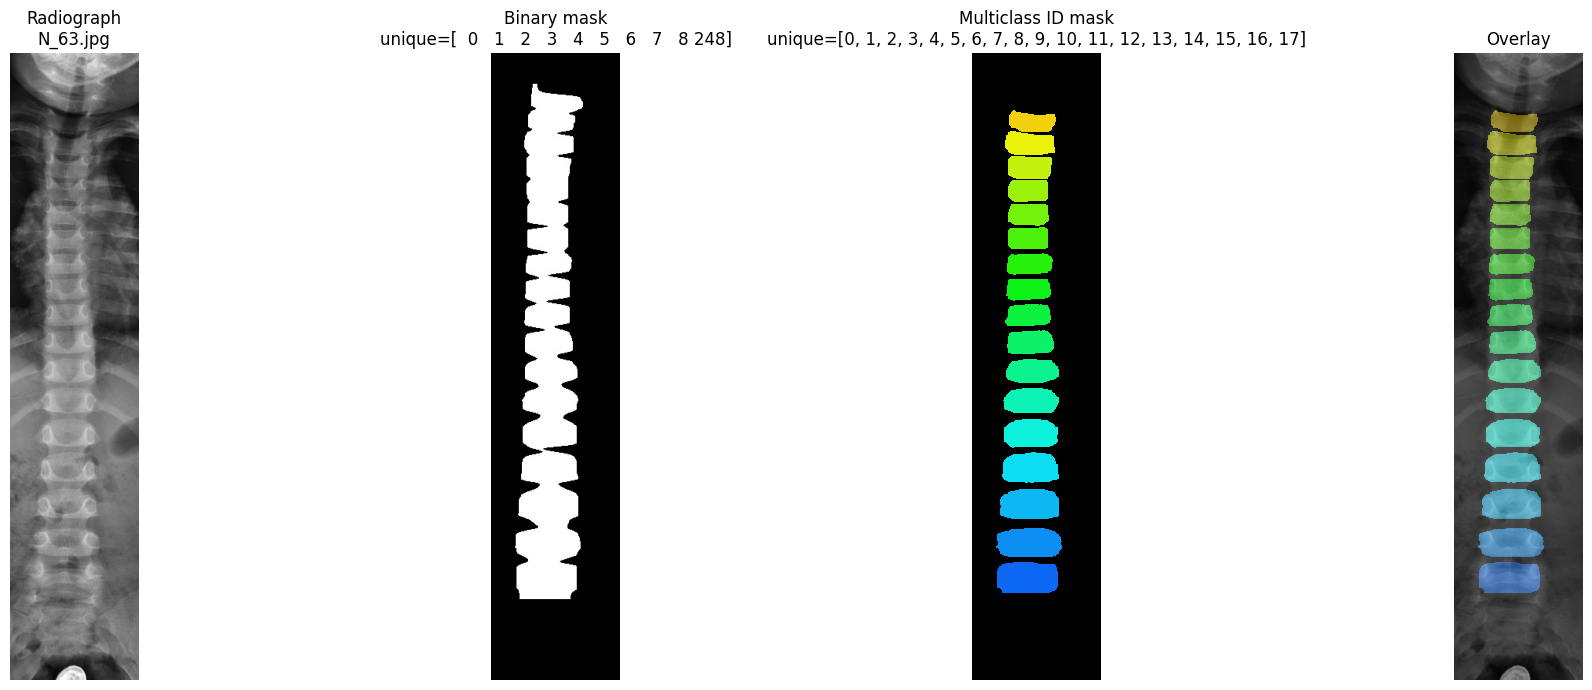

row_idx=57 | grupo=Normal | imagen=N_58.jpg
image_path        : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Normal/N_58.jpg
binary_mask_path  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelBinaryJPG/Label_N_58.jpg
multiclass_path   : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelMultiClass_ID_PNG/LabelMulti_N_58.png


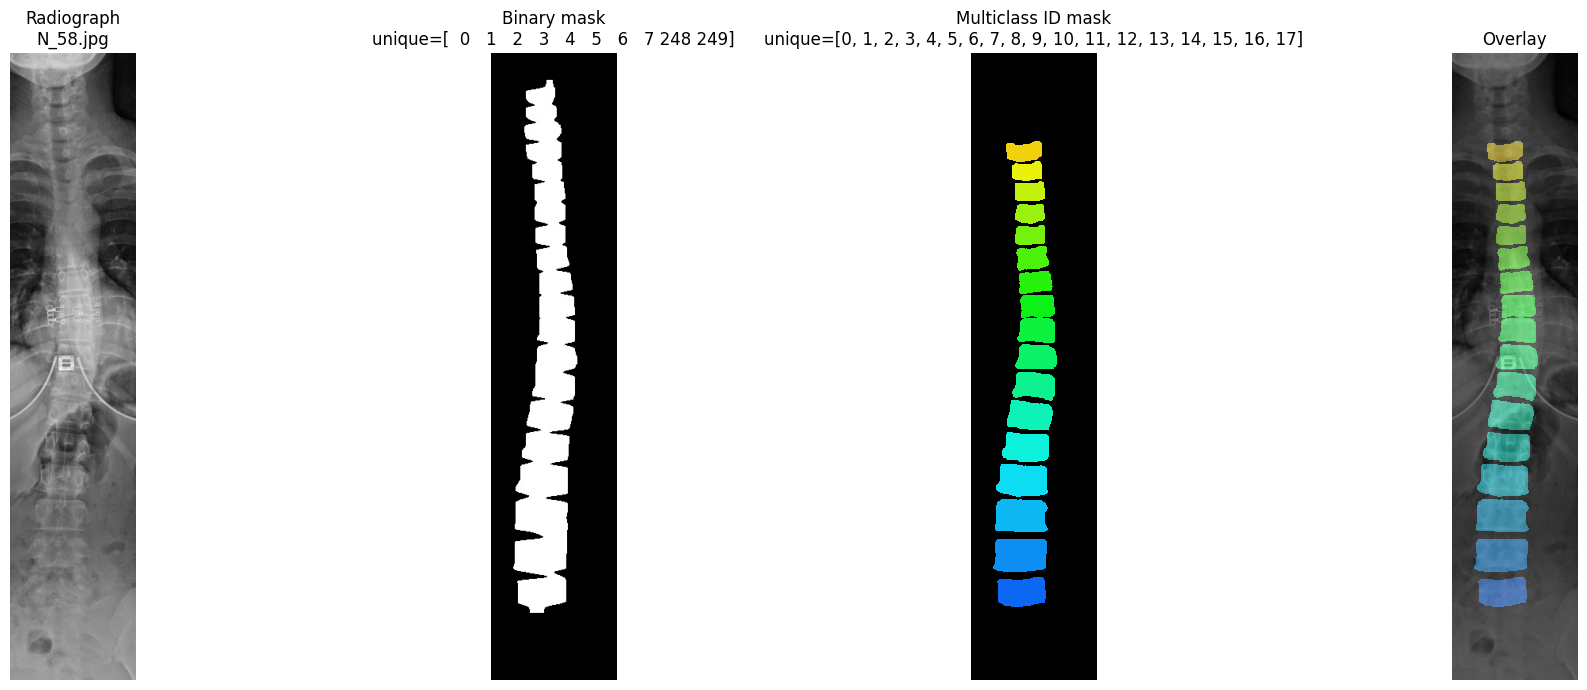

row_idx=35 | grupo=Normal | imagen=N_36.jpg
image_path        : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Normal/N_36.jpg
binary_mask_path  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelBinaryJPG/Label_N_36.jpg
multiclass_path   : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected/LabelMulti_N_36.png


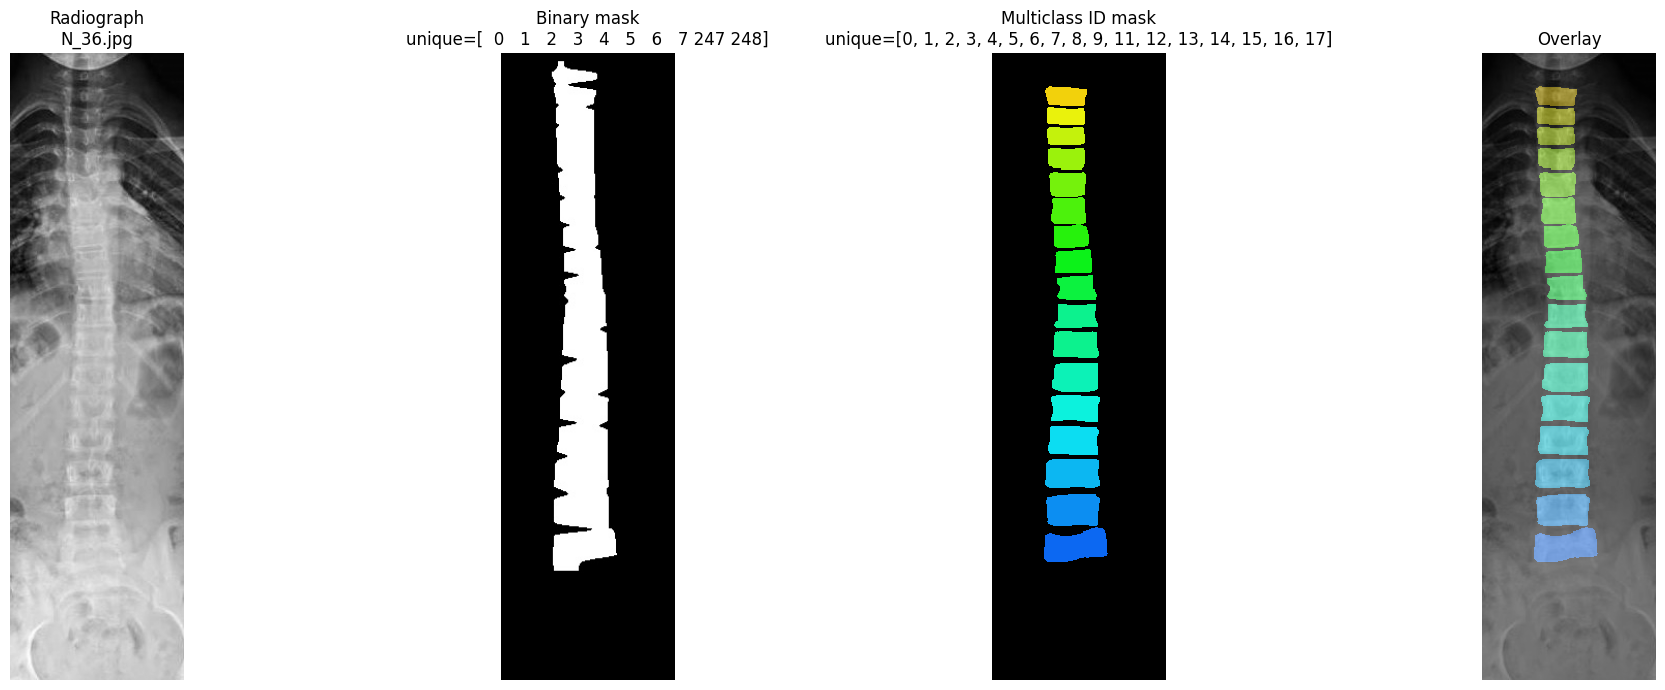

In [ ]:
# =========================================================
# Visual checks
# =========================================================

num_examples = min(CONFIG["num_visual_examples"], len(df_valid))
example_indices = random.sample(range(len(df_valid)), k=num_examples)

for idx in example_indices:
    row = df_valid.iloc[idx]
    print("=" * 100)
    print(f"row_idx={idx} | grupo={row['grupo']} | imagen={row['imagen']}")
    print(f"image_path        : {row['image_path']}")
    print(f"binary_mask_path  : {row['binary_mask_path']}")
    print(f"multiclass_path   : {row['multiclass_mask_path']}")
    visualize_sample(row)

In [ ]:
# =========================================================
# Section 1 summary
# =========================================================

summary = {
    "dataset_root": str(DATASET_ROOT),
    "run_env": RUN_ENV,
    "total_rows_in_index": int(len(df)),
    "valid_rows_after_file_checks": int(len(df_valid)),
    "groups": df_valid["grupo"].value_counts(dropna=False).to_dict(),
}

print(json.dumps(summary, indent=2))
print("\nSection 1 complete.")

{
  "dataset_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset",
  "run_env": "colab",
  "total_rows_in_index": 250,
  "valid_rows_after_file_checks": 249,
  "groups": {
    "Scoliosis": 178,
    "Normal": 71
  }
}

Section 1 complete.


# Section 2 — Preprocessing and Split Logic

This section does:

1. Build a clean training manifest from validated rows
2. Add lightweight metadata useful for splitting and debugging
3. Create a reproducible train/val/test split
4. Prefer patient-level splitting to avoid leakage
5. Export split CSV files for later training/evaluation

Notes:
- No model training yet
- No heavy preprocessing yet
- No augmentation yet
- We keep the official multiclass ID PNG masks as the target source

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [ ]:
# =========================================================
# Dataset filter config (applied BEFORE YOLO export and training)
# =========================================================

FILTER_CONFIG = {
    # Options:
    # - "all_current"    : keep all currently valid rows after ignore list + shape checks
    # - "complete_only"  : keep only masks with all final vertebra labels T1..T12 + L1..L5
    # - "near_complete"  : keep masks with at least N final labels present
    #
    # Keep corrected-mask experiment broad, but add one moderate quality gate
    "filter_mode": "all_current",

    # File from DATASET_ROOT
    "report_csv_name": "reporte_por_mascara_version_final.csv",

    # Final labels expected in the current dataset version
    "required_final_labels": [
        "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11", "T12",
        "L1", "L2", "L3", "L4", "L5"
    ],

    # Only used when filter_mode == "near_complete"
    "near_complete_min_labels": 15,

    # Keep report only as diagnostics / metadata support
    "require_report_match_for_all_current": False,
    "use_report_for_diagnostics": True,

    # Ignore list
    "exclude_mask_stems": CONFIG["ignore_mask_stems"],

    # New controlled experiment:
    # apply a minimum foreground vertebra count based on the ACTUAL chosen mask
    # (corrected mask if present, otherwise original)
    "apply_min_fg_classes_filter": True,
    "min_fg_classes_required": 10,

    # Save filter summary under existing meta structure
    "save_filter_summary": True,
}

REQUIRED_FINAL_LABELS_SET = set(FILTER_CONFIG["required_final_labels"])
IGNORE_MASK_STEMS_SET = set(FILTER_CONFIG["exclude_mask_stems"])
REPORT_MASK_PATH = DATASET_ROOT / FILTER_CONFIG["report_csv_name"]

print("FILTER_CONFIG")
print(json.dumps(FILTER_CONFIG, indent=2, ensure_ascii=False))
print("REPORT_MASK_PATH:", REPORT_MASK_PATH)
print("Exists:", REPORT_MASK_PATH.exists())

FILTER_CONFIG
{
  "filter_mode": "all_current",
  "report_csv_name": "reporte_por_mascara_version_final.csv",
  "required_final_labels": [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6",
    "T7",
    "T8",
    "T9",
    "T10",
    "T11",
    "T12",
    "L1",
    "L2",
    "L3",
    "L4",
    "L5"
  ],
  "near_complete_min_labels": 15,
  "require_report_match_for_all_current": false,
  "use_report_for_diagnostics": true,
  "exclude_mask_stems": [
    "LabelMulti_S_137"
  ],
  "apply_min_fg_classes_filter": true,
  "min_fg_classes_required": 10,
  "save_filter_summary": true
}
REPORT_MASK_PATH: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/reporte_por_mascara_version_final.csv
Exists: True


In [ ]:
# =========================================================
# Split / preprocessing config
# =========================================================

SPLIT_CONFIG = {
    "test_size": 0.15,
    "val_size_within_remaining": 0.17647058823529413,
    # This makes final split about:
    # train = 70%
    # val   = 15%
    # test  = 15%

    "prefer_patient_level_split": True,
    "stratify_by_group_if_possible": True,

    # Future-ready preprocessing settings
    "image_mode": "grayscale",          # AP X-rays are grayscale
    "mask_mode": "multiclass_id",
    "keep_original_resolution_in_manifest": True,

    # Export
    "manifest_dir_name": "manifests",
}

MANIFEST_DIR = META_ROOT / SPLIT_CONFIG["manifest_dir_name"]
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("SPLIT_CONFIG")
print(json.dumps(SPLIT_CONFIG, indent=2))
print("MANIFEST_DIR:", MANIFEST_DIR)

SPLIT_CONFIG
{
  "test_size": 0.15,
  "val_size_within_remaining": 0.17647058823529413,
  "prefer_patient_level_split": true,
  "stratify_by_group_if_possible": true,
  "image_mode": "grayscale",
  "mask_mode": "multiclass_id",
  "keep_original_resolution_in_manifest": true,
  "manifest_dir_name": "manifests"
}
MANIFEST_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests


In [ ]:
# =========================================================
# Build clean manifest for downstream work
# =========================================================

manifest = df_valid.copy()

# Keep only columns we want downstream
base_cols = [
    "grupo",
    "imagen",
    "id_paciente",
    "ruta_radiografia",
    "ruta_mascara_binaria",
    "ruta_mascara_multiclase_id_png",
    "image_path",
    "binary_mask_path",
    "original_multiclass_mask_path",
    "corrected_multiclass_mask_candidate_path",
    "has_corrected_multiclass_mask",
    "multiclass_mask_path",
    "multiclass_mask_source",
    "multiclass_mask_filename",
    "mask_stem",
]

extra_cols = []
for c in [
    "ruta_mascara_multiclase_grises_jpg",
    "ruta_mascara_multiclase_color_jpg",
    "gray_mask_path",
    "color_mask_path",
    "metrics_json_path",
]:
    if c in manifest.columns:
        extra_cols.append(c)

manifest = manifest[base_cols + extra_cols].copy()

# Normalize text fields a bit
for c in ["grupo", "imagen", "id_paciente", "multiclass_mask_source", "multiclass_mask_filename", "mask_stem"]:
    if c in manifest.columns:
        manifest[c] = manifest[c].astype(str).str.strip()

manifest = manifest.reset_index(drop=True)

print("Manifest shape:", manifest.shape)
display(manifest.head())

Manifest shape: (249, 20)


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,image_path,binary_mask_path,original_multiclass_mask_path,corrected_multiclass_mask_candidate_path,has_corrected_multiclass_mask,multiclass_mask_path,multiclass_mask_source,multiclass_mask_filename,mask_stem,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,gray_mask_path,color_mask_path,metrics_json_path
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_1.png,LabelMulti_N_1,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_2.png,LabelMulti_N_2,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_3.png,LabelMulti_N_3,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_4.png,LabelMulti_N_4,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_5.png,LabelMulti_N_5,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,None


In [ ]:
# =========================================================
# Add lightweight metadata
# =========================================================

def get_array_shape(path, kind="image"):
    arr = load_image_grayscale(path) if kind == "image" else load_mask_multiclass_id(path)
    return arr.shape[:2]

def count_present_classes(mask):
    vals = np.unique(mask)
    vals = vals[vals != 0]   # ignore background for presence summary
    return vals.tolist(), len(vals)

image_h = []
image_w = []
mask_h = []
mask_w = []
num_fg_classes = []
present_class_ids = []

for _, row in manifest.iterrows():
    ih, iw = get_array_shape(row["image_path"], kind="image")
    mh, mw = get_array_shape(row["multiclass_mask_path"], kind="mask")
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])
    present_ids, n_present = count_present_classes(mmask)

    image_h.append(int(ih))
    image_w.append(int(iw))
    mask_h.append(int(mh))
    mask_w.append(int(mw))
    num_fg_classes.append(int(n_present))
    present_class_ids.append(present_ids)

manifest["image_h"] = image_h
manifest["image_w"] = image_w
manifest["mask_h"] = mask_h
manifest["mask_w"] = mask_w
manifest["num_fg_classes"] = num_fg_classes
manifest["present_class_ids"] = present_class_ids
manifest["same_hw"] = (manifest["image_h"] == manifest["mask_h"]) & (manifest["image_w"] == manifest["mask_w"])

print("same_hw all true:", manifest["same_hw"].all())
display(manifest[["imagen", "grupo", "id_paciente", "image_h", "image_w", "mask_h", "mask_w", "num_fg_classes", "same_hw"]].head())

same_hw all true: True


,imagen,grupo,id_paciente,image_h,image_w,mask_h,mask_w,num_fg_classes,same_hw
0,N_1.jpg,Normal,1,971,259,971,259,17,True
1,N_2.jpg,Normal,2,828,218,828,218,17,True
2,N_3.jpg,Normal,3,939,206,939,206,17,True
3,N_4.jpg,Normal,4,878,204,878,204,17,True
4,N_5.jpg,Normal,5,666,172,666,172,17,True


In [ ]:
# =========================================================
# Keep only shape-consistent rows + apply optional mask completeness filter
# =========================================================

manifest_pre_filter = manifest.copy()

manifest_pre_filter["is_ignored_by_mask_stem"] = manifest_pre_filter["mask_stem"].isin(IGNORE_MASK_STEMS_SET)
manifest_after_ignore = manifest_pre_filter[~manifest_pre_filter["is_ignored_by_mask_stem"]].copy().reset_index(drop=True)
manifest_shape_clean = manifest_after_ignore[manifest_after_ignore["same_hw"]].copy().reset_index(drop=True)

print(f"Rows before ignore list    : {len(manifest_pre_filter)}")
print(f"Rows removed by ignore list: {len(manifest_pre_filter) - len(manifest_after_ignore)}")
print(f"Rows before shape filter   : {len(manifest_after_ignore)}")
print(f"Rows after shape filter    : {len(manifest_shape_clean)}")
print(f"Rows removed by shape      : {len(manifest_after_ignore) - len(manifest_shape_clean)}")

assert len(manifest_shape_clean) > 0, "No valid rows remain after ignore list + shape filtering."

# New controlled filter: use actual chosen-mask foreground class count
if FILTER_CONFIG.get("apply_min_fg_classes_filter", False):
    min_fg_required = int(FILTER_CONFIG["min_fg_classes_required"])
    manifest_after_fg_filter = manifest_shape_clean[
        manifest_shape_clean["num_fg_classes"] >= min_fg_required
    ].copy().reset_index(drop=True)
else:
    min_fg_required = None
    manifest_after_fg_filter = manifest_shape_clean.copy().reset_index(drop=True)

print(f"\nRows before min_fg filter  : {len(manifest_shape_clean)}")
print(f"Rows after min_fg filter   : {len(manifest_after_fg_filter)}")
print(f"Rows removed by min_fg     : {len(manifest_shape_clean) - len(manifest_after_fg_filter)}")
if min_fg_required is not None:
    print(f"min_fg_classes_required    : {min_fg_required}")

assert len(manifest_after_fg_filter) > 0, "No valid rows remain after min_fg_classes filter."

report_available = REPORT_MASK_PATH.exists() and FILTER_CONFIG.get("use_report_for_diagnostics", True)
print("\nReport available for diagnostics:", report_available)

if report_available:
    report_df = pd.read_csv(REPORT_MASK_PATH)

    print("\nLoaded report CSV:")
    print("Shape:", report_df.shape)
    display(report_df.head())

    expected_report_cols = [
        "archivo_mascara",
        "etiquetas_presentes_en_version_final",
        "numero_etiquetas_presentes_en_version_final",
    ]
    missing_report_cols = [c for c in expected_report_cols if c not in report_df.columns]
    assert len(missing_report_cols) == 0, f"Missing required report columns: {missing_report_cols}"

    def parse_present_labels(label_text):
        if pd.isna(label_text):
            return set()
        text = str(label_text).strip()
        if text == "":
            return set()
        return {part.strip() for part in text.split(",") if part.strip()}

    report_df = report_df.copy()
    report_df["present_final_labels_set"] = report_df["etiquetas_presentes_en_version_final"].apply(parse_present_labels)
    report_df["present_final_labels_count"] = report_df["present_final_labels_set"].apply(len)
    report_df["is_complete_final_set"] = report_df["present_final_labels_set"].apply(
        lambda x: x == REQUIRED_FINAL_LABELS_SET
    )

    manifest_after_fg_filter["archivo_mascara"] = manifest_after_fg_filter["multiclass_mask_path"].apply(lambda p: Path(p).name)

    manifest_with_report = manifest_after_fg_filter.merge(
        report_df[
            [
                "archivo_mascara",
                "etiquetas_presentes_en_version_final",
                "numero_etiquetas_presentes_en_version_final",
                "present_final_labels_set",
                "present_final_labels_count",
                "is_complete_final_set",
            ]
        ],
        on="archivo_mascara",
        how="left",
    )

    manifest_with_report["has_report_match"] = manifest_with_report["present_final_labels_count"].notna()
else:
    manifest_with_report = manifest_after_fg_filter.copy()
    manifest_with_report["archivo_mascara"] = manifest_with_report["multiclass_mask_path"].apply(lambda p: Path(p).name)
    manifest_with_report["etiquetas_presentes_en_version_final"] = np.nan
    manifest_with_report["numero_etiquetas_presentes_en_version_final"] = np.nan
    manifest_with_report["present_final_labels_set"] = None
    manifest_with_report["present_final_labels_count"] = np.nan
    manifest_with_report["is_complete_final_set"] = False
    manifest_with_report["has_report_match"] = False

missing_report_match = (~manifest_with_report["has_report_match"]).sum()
print("\nRows without report match:", int(missing_report_match))

def is_row_eligible(row, cfg):
    mode = cfg["filter_mode"]
    has_report_match = bool(row["has_report_match"])

    if mode == "all_current":
        if cfg.get("require_report_match_for_all_current", False):
            return has_report_match
        return True

    if not has_report_match:
        return False

    if mode == "complete_only":
        return bool(row["is_complete_final_set"])

    if mode == "near_complete":
        return int(row["present_final_labels_count"]) >= int(cfg["near_complete_min_labels"])

    raise ValueError(f"Unknown filter_mode: {mode}")

manifest_with_report["filter_mode"] = FILTER_CONFIG["filter_mode"]
manifest_with_report["near_complete_min_labels"] = FILTER_CONFIG["near_complete_min_labels"]
manifest_with_report["require_report_match_for_all_current"] = FILTER_CONFIG.get("require_report_match_for_all_current", False)
manifest_with_report["apply_min_fg_classes_filter"] = FILTER_CONFIG.get("apply_min_fg_classes_filter", False)
manifest_with_report["min_fg_classes_required"] = FILTER_CONFIG.get("min_fg_classes_required", None)
manifest_with_report["is_filter_eligible"] = manifest_with_report.apply(
    lambda row: is_row_eligible(row, FILTER_CONFIG),
    axis=1
)

manifest_clean = manifest_with_report[manifest_with_report["is_filter_eligible"]].copy().reset_index(drop=True)

FILTER_SUMMARY = {
    "filter_mode": FILTER_CONFIG["filter_mode"],
    "near_complete_min_labels": FILTER_CONFIG["near_complete_min_labels"],
    "require_report_match_for_all_current": bool(FILTER_CONFIG.get("require_report_match_for_all_current", False)),
    "apply_min_fg_classes_filter": bool(FILTER_CONFIG.get("apply_min_fg_classes_filter", False)),
    "min_fg_classes_required": FILTER_CONFIG.get("min_fg_classes_required", None),
    "num_rows_initial": int(len(manifest_pre_filter)),
    "num_rows_removed_by_ignore_list": int(len(manifest_pre_filter) - len(manifest_after_ignore)),
    "num_rows_after_ignore_list": int(len(manifest_after_ignore)),
    "num_rows_removed_by_shape_filter": int(len(manifest_after_ignore) - len(manifest_shape_clean)),
    "num_rows_after_shape_filter": int(len(manifest_shape_clean)),
    "num_rows_removed_by_min_fg_filter": int(len(manifest_shape_clean) - len(manifest_after_fg_filter)),
    "num_rows_after_min_fg_filter": int(len(manifest_after_fg_filter)),
    "images_kept": int(len(manifest_clean)),
    "images_excluded_final": int(len(manifest_after_fg_filter) - len(manifest_clean)),
    "rows_without_report_match": int(missing_report_match),
    "num_corrected_masks_used": int((manifest_clean["multiclass_mask_source"] == "corrected").sum()),
    "num_original_masks_used": int((manifest_clean["multiclass_mask_source"] == "original").sum()),
    "ignored_mask_stems": sorted(list(IGNORE_MASK_STEMS_SET)),
}

print("\nFilter summary:")
print(json.dumps(FILTER_SUMMARY, indent=2, ensure_ascii=False))

label_count_distribution_df = (
    manifest_with_report["present_final_labels_count"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "present_final_labels_count"})
)

fg_count_distribution_df = (
    manifest_after_ignore["num_fg_classes"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "num_fg_classes"})
)

eligibility_distribution_df = (
    manifest_with_report["is_filter_eligible"]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "is_filter_eligible"})
)

mask_source_distribution_df = (
    manifest_clean["multiclass_mask_source"]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "multiclass_mask_source"})
)

print("\nLabel-count distribution (diagnostic only):")
display(label_count_distribution_df)

print("\nForeground-class-count distribution:")
display(fg_count_distribution_df)

print("\nEligibility distribution:")
display(eligibility_distribution_df)

print("\nMask source distribution in final dataset:")
display(mask_source_distribution_df)

print(f"\nRows after final filter: {len(manifest_clean)} / {len(manifest_pre_filter)}")

if FILTER_CONFIG["save_filter_summary"]:
    MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

    filter_stub = FILTER_CONFIG["filter_mode"]
    if CONFIG["prefer_corrected_masks"]:
        filter_stub += "_corrected_priority"
    if FILTER_CONFIG.get("apply_min_fg_classes_filter", False):
        filter_stub += f"_minfg{FILTER_CONFIG['min_fg_classes_required']}"
    if len(IGNORE_MASK_STEMS_SET) > 0:
        filter_stub += "_ignorelist"

    filter_summary_path = MANIFEST_DIR / f"filter_summary_{filter_stub}.json"
    label_count_distribution_path = MANIFEST_DIR / f"label_count_distribution_{filter_stub}.csv"
    fg_count_distribution_path = MANIFEST_DIR / f"fg_count_distribution_{filter_stub}.csv"
    eligibility_distribution_path = MANIFEST_DIR / f"eligibility_distribution_{filter_stub}.csv"
    mask_source_distribution_path = MANIFEST_DIR / f"mask_source_distribution_{filter_stub}.csv"

    with open(filter_summary_path, "w", encoding="utf-8") as f:
        json.dump(FILTER_SUMMARY, f, indent=2, ensure_ascii=False)

    label_count_distribution_df.to_csv(label_count_distribution_path, index=False)
    fg_count_distribution_df.to_csv(fg_count_distribution_path, index=False)
    eligibility_distribution_df.to_csv(eligibility_distribution_path, index=False)
    mask_source_distribution_df.to_csv(mask_source_distribution_path, index=False)

    print("\nSaved filter artifacts:")
    print("filter_summary_path           :", filter_summary_path)
    print("label_count_distribution_path :", label_count_distribution_path)
    print("fg_count_distribution_path    :", fg_count_distribution_path)
    print("eligibility_distribution_path :", eligibility_distribution_path)
    print("mask_source_distribution_path :", mask_source_distribution_path)

display(
    manifest_clean[
        [
            "imagen",
            "grupo",
            "id_paciente",
            "mask_stem",
            "num_fg_classes",
            "multiclass_mask_source",
            "has_corrected_multiclass_mask",
            "archivo_mascara",
            "present_final_labels_count",
            "filter_mode",
            "is_filter_eligible",
        ]
    ].head()
)

Rows before ignore list    : 249
Rows removed by ignore list: 1
Rows before shape filter   : 248
Rows after shape filter    : 248
Rows removed by shape      : 0

Rows before min_fg filter  : 248
Rows after min_fg filter   : 248
Rows removed by min_fg     : 0
min_fg_classes_required    : 10

Report available for diagnostics: True

Loaded report CSV:
Shape: (250, 5)


,archivo_mascara,etiquetas_presentes_en_version_final,otras_etiquetas_identificadas_en_mascara_original,numero_otras_etiquetas_identificadas,numero_etiquetas_presentes_en_version_final
0,LabelMulti_N_1.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","C7, C6, C5, C4",4,17
1,LabelMulti_N_10.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","C7, C6",2,17
2,LabelMulti_N_11.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","C7, C6, C5",3,17
3,LabelMulti_N_12.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","C7, C6",2,17
4,LabelMulti_N_13.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","C7, C6",2,17



Rows without report match: 0

Filter summary:
{
  "filter_mode": "all_current",
  "near_complete_min_labels": 15,
  "require_report_match_for_all_current": false,
  "apply_min_fg_classes_filter": true,
  "min_fg_classes_required": 10,
  "num_rows_initial": 249,
  "num_rows_removed_by_ignore_list": 1,
  "num_rows_after_ignore_list": 248,
  "num_rows_removed_by_shape_filter": 0,
  "num_rows_after_shape_filter": 248,
  "num_rows_removed_by_min_fg_filter": 0,
  "num_rows_after_min_fg_filter": 248,
  "images_kept": 248,
  "images_excluded_final": 0,
  "rows_without_report_match": 0,
  "num_corrected_masks_used": 146,
  "num_original_masks_used": 102,
  "ignored_mask_stems": [
    "LabelMulti_S_137"
  ]
}

Label-count distribution (diagnostic only):


,present_final_labels_count,count
0,3,2
1,4,6
2,5,5
3,6,4
4,7,5
5,8,5
6,9,6
7,10,17
8,11,16
9,12,19



Foreground-class-count distribution:


...

,is_filter_eligible,count
0,True,248



Mask source distribution in final dataset:


,multiclass_mask_source,count
0,corrected,146
1,original,102



Rows after final filter: 248 / 249

Saved filter artifacts:
filter_summary_path           : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/filter_summary_all_current_corrected_priority_minfg10_ignorelist.json
label_count_distribution_path : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/label_count_distribution_all_current_corrected_priority_minfg10_ignorelist.csv
fg_count_distribution_path    : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/fg_count_distribution_all_current_corrected_priority_minfg10_ignorelist.csv
eligibility_distribution_path : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_verteb

,imagen,grupo,id_paciente,mask_stem,num_fg_classes,multiclass_mask_source,has_corrected_multiclass_mask,archivo_mascara,present_final_labels_count,filter_mode,is_filter_eligible
0,N_1.jpg,Normal,1,LabelMulti_N_1,17,original,False,LabelMulti_N_1.png,17,all_current,True
1,N_2.jpg,Normal,2,LabelMulti_N_2,17,original,False,LabelMulti_N_2.png,17,all_current,True
2,N_3.jpg,Normal,3,LabelMulti_N_3,17,original,False,LabelMulti_N_3.png,17,all_current,True
3,N_4.jpg,Normal,4,LabelMulti_N_4,17,original,False,LabelMulti_N_4.png,17,all_current,True
4,N_5.jpg,Normal,5,LabelMulti_N_5,17,original,False,LabelMulti_N_5.png,17,all_current,True


In [ ]:
# =========================================================
# Patient-level summary
# =========================================================

patient_col_usable = (
    "id_paciente" in manifest_clean.columns
    and manifest_clean["id_paciente"].notna().all()
    and manifest_clean["id_paciente"].astype(str).str.strip().ne("").all()
)

print("Patient column usable:", patient_col_usable)

if patient_col_usable:
    patient_summary = (
        manifest_clean
        .groupby("id_paciente")
        .agg(
            n_images=("imagen", "count"),
            grupo_mode=("grupo", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
            avg_num_fg_classes=("num_fg_classes", "mean"),
        )
        .reset_index()
    )
    print("Unique patients:", len(patient_summary))
    display(patient_summary.head())
else:
    print("Falling back to image-level splitting later because id_paciente is not safely usable.")

Patient column usable: True
Unique patients: 197


,id_paciente,n_images,grupo_mode,avg_num_fg_classes
0,1,1,Normal,17.0
1,10,1,Normal,17.0
2,100,1,Scoliosis,15.0
3,101,1,Scoliosis,17.0
4,102,1,Scoliosis,17.0


In [ ]:
# =========================================================
# Split helpers
# =========================================================

def safe_train_test_split_df(df_in, test_size, stratify_col=None, random_state=42):
    """
    Wrapper that tries stratified split first when possible.
    Falls back to unstratified split if stratification is not feasible.
    """
    if stratify_col is not None:
        value_counts = df_in[stratify_col].value_counts()
        min_count = value_counts.min() if len(value_counts) > 0 else 0

        if len(value_counts) >= 2 and min_count >= 2:
            return train_test_split(
                df_in,
                test_size=test_size,
                random_state=random_state,
                stratify=df_in[stratify_col]
            )

    return train_test_split(
        df_in,
        test_size=test_size,
        random_state=random_state,
        stratify=None
    )

def assign_split_column(df_split, split_name):
    out = df_split.copy()
    out["split"] = split_name
    return out

def summarize_split(df_split, name):
    print(f"\n{name.upper()} SUMMARY")
    print("-" * 50)
    print("Rows     :", len(df_split))
    if "id_paciente" in df_split.columns:
        print("Patients :", df_split["id_paciente"].nunique())
    print("Groups   :")
    display(df_split["grupo"].value_counts(dropna=False).rename("count").to_frame())

In [ ]:
# =========================================================
# Create train / val / test split
# =========================================================

RANDOM_STATE = CONFIG["seed"]

if SPLIT_CONFIG["prefer_patient_level_split"] and patient_col_usable:
    split_unit_df = patient_summary.copy()
    split_id_col = "id_paciente"
    stratify_col = "grupo_mode" if SPLIT_CONFIG["stratify_by_group_if_possible"] else None
    print("Using PATIENT-LEVEL split.")
else:
    split_unit_df = manifest_clean[["imagen", "grupo"]].copy()
    split_unit_df["id_for_split"] = split_unit_df["imagen"]
    split_id_col = "id_for_split"
    stratify_col = "grupo" if SPLIT_CONFIG["stratify_by_group_if_possible"] else None
    print("Using IMAGE-LEVEL split.")

# 1) held-out test
split_trainval_units, split_test_units = safe_train_test_split_df(
    split_unit_df,
    test_size=SPLIT_CONFIG["test_size"],
    stratify_col=stratify_col,
    random_state=RANDOM_STATE
)

# 2) validation from remaining
val_stratify_col = stratify_col if stratify_col in split_trainval_units.columns else None

split_train_units, split_val_units = safe_train_test_split_df(
    split_trainval_units,
    test_size=SPLIT_CONFIG["val_size_within_remaining"],
    stratify_col=val_stratify_col,
    random_state=RANDOM_STATE
)

print("Split unit sizes:")
print("train units:", len(split_train_units))
print("val units  :", len(split_val_units))
print("test units :", len(split_test_units))

Using PATIENT-LEVEL split.
Split unit sizes:
train units: 137
val units  : 30
test units : 30


In [ ]:
# =========================================================
# Expand unit splits back to image rows
# =========================================================

if SPLIT_CONFIG["prefer_patient_level_split"] and patient_col_usable:
    train_ids = set(split_train_units["id_paciente"])
    val_ids = set(split_val_units["id_paciente"])
    test_ids = set(split_test_units["id_paciente"])

    train_df = manifest_clean[manifest_clean["id_paciente"].isin(train_ids)].copy()
    val_df   = manifest_clean[manifest_clean["id_paciente"].isin(val_ids)].copy()
    test_df  = manifest_clean[manifest_clean["id_paciente"].isin(test_ids)].copy()
else:
    train_ids = set(split_train_units[split_id_col])
    val_ids = set(split_val_units[split_id_col])
    test_ids = set(split_test_units[split_id_col])

    train_df = manifest_clean[manifest_clean["imagen"].isin(train_ids)].copy()
    val_df   = manifest_clean[manifest_clean["imagen"].isin(val_ids)].copy()
    test_df  = manifest_clean[manifest_clean["imagen"].isin(test_ids)].copy()

train_df = assign_split_column(train_df, "train")
val_df = assign_split_column(val_df, "val")
test_df = assign_split_column(test_df, "test")

split_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

summarize_split(train_df, "train")
summarize_split(val_df, "val")
summarize_split(test_df, "test")


TRAIN SUMMARY
--------------------------------------------------
Rows     : 173
Patients : 137
Groups   :


,count
grupo,
Scoliosis,124
Normal,49



VAL SUMMARY
--------------------------------------------------
Rows     : 37
Patients : 30
Groups   :


,count
grupo,
Scoliosis,26
Normal,11



TEST SUMMARY
--------------------------------------------------
Rows     : 38
Patients : 30
Groups   :


,count
grupo,
Scoliosis,27
Normal,11


In [ ]:
# =========================================================
# Leakage checks
# =========================================================

print("Row overlap checks")
print("-" * 50)

train_images = set(train_df["imagen"])
val_images = set(val_df["imagen"])
test_images = set(test_df["imagen"])

print("train ∩ val  :", len(train_images & val_images))
print("train ∩ test :", len(train_images & test_images))
print("val ∩ test   :", len(val_images & test_images))

if patient_col_usable:
    train_patients = set(train_df["id_paciente"])
    val_patients = set(val_df["id_paciente"])
    test_patients = set(test_df["id_paciente"])

    print("\nPatient overlap checks")
    print("-" * 50)
    print("train ∩ val  :", len(train_patients & val_patients))
    print("train ∩ test :", len(train_patients & test_patients))
    print("val ∩ test   :", len(val_patients & test_patients))

    assert len(train_patients & val_patients) == 0
    assert len(train_patients & test_patients) == 0
    assert len(val_patients & test_patients) == 0

assert len(train_images & val_images) == 0
assert len(train_images & test_images) == 0
assert len(val_images & test_images) == 0

print("\nLeakage checks passed.")

Row overlap checks
--------------------------------------------------
train ∩ val  : 0
train ∩ test : 0
val ∩ test   : 0

Patient overlap checks
--------------------------------------------------
train ∩ val  : 0
train ∩ test : 0
val ∩ test   : 0

Leakage checks passed.


In [ ]:
# =========================================================
# Split ratios
# =========================================================

n_total = len(split_df)
ratio_table = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
})
ratio_table["fraction"] = ratio_table["rows"] / n_total

display(ratio_table)

if patient_col_usable:
    patient_ratio_table = pd.DataFrame({
        "split": ["train", "val", "test"],
        "patients": [
            train_df["id_paciente"].nunique(),
            val_df["id_paciente"].nunique(),
            test_df["id_paciente"].nunique(),
        ]
    })
    display(patient_ratio_table)

,split,rows,fraction
0,train,173,0.697581
1,val,37,0.149194
2,test,38,0.153226


,split,patients
0,train,137
1,val,30
2,test,30


In [ ]:
# =========================================================
# Per-class presence by split
# =========================================================

CLASS_NAME_MAP = multiclass_map.copy()

def class_presence_summary(df_subset):
    counts = Counter()
    pixel_presence_rows = []

    for _, row in df_subset.iterrows():
        mmask = load_mask_multiclass_id(row["multiclass_mask_path"])
        present = np.unique(mmask)
        present = present[present != 0]

        for cls_id in present.tolist():
            counts[int(cls_id)] += 1

    rows = []
    for cls_id in range(1, 18):
        rows.append({
            "class_id": cls_id,
            "class_name": CLASS_NAME_MAP[cls_id],
            "num_images_where_present": counts.get(cls_id, 0),
            "fraction_of_split": counts.get(cls_id, 0) / len(df_subset) if len(df_subset) > 0 else 0.0,
        })
    return pd.DataFrame(rows)

train_class_presence = class_presence_summary(train_df)
val_class_presence = class_presence_summary(val_df)
test_class_presence = class_presence_summary(test_df)

print("Train class presence")
display(train_class_presence)

print("Val class presence")
display(val_class_presence)

print("Test class presence")
display(test_class_presence)

Train class presence


,class_id,class_name,num_images_where_present,fraction_of_split
0,1,T1,165,0.953757
1,2,T2,172,0.994220
2,3,T3,173,1.000000
3,4,T4,173,1.000000
4,5,T5,173,1.000000
5,6,T6,172,0.994220
6,7,T7,173,1.000000
7,8,T8,172,0.994220
8,9,T9,172,0.994220
9,10,T10,171,0.988439


Val class presence


,class_id,class_name,num_images_where_present,fraction_of_split
0,1,T1,35,0.945946
1,2,T2,35,0.945946
2,3,T3,36,0.972973
3,4,T4,37,1.000000
4,5,T5,36,0.972973
5,6,T6,37,1.000000
6,7,T7,37,1.000000
7,8,T8,36,0.972973
8,9,T9,37,1.000000
9,10,T10,37,1.000000


Test class presence


,class_id,class_name,num_images_where_present,fraction_of_split
0,1,T1,38,1.000000
1,2,T2,38,1.000000
2,3,T3,38,1.000000
3,4,T4,38,1.000000
4,5,T5,38,1.000000
5,6,T6,38,1.000000
6,7,T7,37,0.973684
7,8,T8,38,1.000000
8,9,T9,38,1.000000
9,10,T10,38,1.000000


In [ ]:
# =========================================================
# Warnings for missing classes in splits
# =========================================================

def report_missing_classes(df_presence, split_name):
    missing = df_presence[df_presence["num_images_where_present"] == 0]
    rare = df_presence[(df_presence["num_images_where_present"] > 0) & (df_presence["num_images_where_present"] < 3)]

    print(f"\n{split_name.upper()} warnings")
    print("-" * 50)

    if len(missing) == 0:
        print("No completely missing vertebra classes.")
    else:
        print("Missing classes:")
        display(missing[["class_id", "class_name", "num_images_where_present"]])

    if len(rare) == 0:
        print("No extremely rare classes (<3 images).")
    else:
        print("Rare classes (<3 images):")
        display(rare[["class_id", "class_name", "num_images_where_present"]])

report_missing_classes(train_class_presence, "train")
report_missing_classes(val_class_presence, "val")
report_missing_classes(test_class_presence, "test")


TRAIN warnings
--------------------------------------------------
No completely missing vertebra classes.
No extremely rare classes (<3 images).

VAL warnings
--------------------------------------------------
No completely missing vertebra classes.
No extremely rare classes (<3 images).

TEST warnings
--------------------------------------------------
No completely missing vertebra classes.
No extremely rare classes (<3 images).


In [ ]:
# =========================================================
# Final split manifests
# =========================================================

final_cols = [
    "split",
    "grupo",
    "imagen",
    "id_paciente",
    "ruta_radiografia",
    "ruta_mascara_binaria",
    "ruta_mascara_multiclase_id_png",
    "image_path",
    "binary_mask_path",
    "original_multiclass_mask_path",
    "corrected_multiclass_mask_candidate_path",
    "has_corrected_multiclass_mask",
    "multiclass_mask_path",
    "multiclass_mask_source",
    "multiclass_mask_filename",
    "mask_stem",
    "image_h",
    "image_w",
    "mask_h",
    "mask_w",
    "num_fg_classes",
    "present_class_ids",
]

# Optional filter/report columns
optional_final_cols = [
    "archivo_mascara",
    "etiquetas_presentes_en_version_final",
    "numero_etiquetas_presentes_en_version_final",
    "present_final_labels_count",
    "is_complete_final_set",
    "has_report_match",
    "filter_mode",
    "is_filter_eligible",
]

final_cols = [c for c in final_cols if c in split_df.columns]
final_cols += [c for c in optional_final_cols if c in split_df.columns]

train_manifest = train_df[final_cols].copy().reset_index(drop=True)
val_manifest = val_df[final_cols].copy().reset_index(drop=True)
test_manifest = test_df[final_cols].copy().reset_index(drop=True)
all_manifest = split_df[final_cols].copy().reset_index(drop=True)

display(train_manifest.head())
display(val_manifest.head())
display(test_manifest.head())

,split,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,image_path,binary_mask_path,original_multiclass_mask_path,corrected_multiclass_mask_candidate_path,has_corrected_multiclass_mask,multiclass_mask_path,multiclass_mask_source,multiclass_mask_filename,mask_stem,image_h,image_w,mask_h,mask_w,num_fg_classes,present_class_ids,archivo_mascara,etiquetas_presentes_en_version_final,numero_etiquetas_presentes_en_version_final,present_final_labels_count,is_complete_final_set,has_report_match,filter_mode,is_filter_eligible
0,train,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_2.png,LabelMulti_N_2,828,218,828,218,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_2.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
1,train,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_4.png,LabelMulti_N_4,878,204,878,204,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_4.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
2,train,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_5.png,LabelMulti_N_5,666,172,666,172,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_5.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
3,train,Normal,N_6.jpg,6,Normal/N_6.jpg,LabelBinaryJPG/Label_N_6.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_6.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_6.png,LabelMulti_N_6,920,186,920,186,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_6.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
4,train,Normal,N_9.jpg,9,Normal/N_9.jpg,LabelBinaryJPG/Label_N_9.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_9.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_9.png,LabelMulti_N_9,633,157,633,157,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_9.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True


,split,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,image_path,binary_mask_path,original_multiclass_mask_path,corrected_multiclass_mask_candidate_path,has_corrected_multiclass_mask,multiclass_mask_path,multiclass_mask_source,multiclass_mask_filename,mask_stem,image_h,image_w,mask_h,mask_w,num_fg_classes,present_class_ids,archivo_mascara,etiquetas_presentes_en_version_final,numero_etiquetas_presentes_en_version_final,present_final_labels_count,is_complete_final_set,has_report_match,filter_mode,is_filter_eligible
0,val,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_1.png,LabelMulti_N_1,971,259,971,259,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_1.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
1,val,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_3.png,LabelMulti_N_3,939,206,939,206,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_3.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
2,val,Normal,N_8.jpg,8,Normal/N_8.jpg,LabelBinaryJPG/Label_N_8.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_8.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_8.png,LabelMulti_N_8,858,229,858,229,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_8.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
3,val,Normal,N_14.jpg,14,Normal/N_14.jpg,LabelBinaryJPG/Label_N_14.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_14.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_14.png,LabelMulti_N_14,734,169,734,169,16,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 1...",LabelMulti_N_14.png,"T1, T2, T3, T4, T5, T6, T7, T9, T10, T11, T12,...",16,16,False,True,all_current,True
4,val,Normal,N_23.jpg,23,Normal/N_23.jpg,LabelBinaryJPG/Label_N_23.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_23.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_23.png,LabelMulti_N_23,878,241,878,241,16,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_23.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",16,16,False,True,all_current,True


,split,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,image_path,binary_mask_path,original_multiclass_mask_path,corrected_multiclass_mask_candidate_path,has_corrected_multiclass_mask,multiclass_mask_path,multiclass_mask_source,multiclass_mask_filename,mask_stem,image_h,image_w,mask_h,mask_w,num_fg_classes,present_class_ids,archivo_mascara,etiquetas_presentes_en_version_final,numero_etiquetas_presentes_en_version_final,present_final_labels_count,is_complete_final_set,has_report_match,filter_mode,is_filter_eligible
0,test,Normal,N_7.jpg,7,Normal/N_7.jpg,LabelBinaryJPG/Label_N_7.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_7.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_7.png,LabelMulti_N_7,937,220,937,220,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_7.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
1,test,Normal,N_10.jpg,10,Normal/N_10.jpg,LabelBinaryJPG/Label_N_10.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_10.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_10.png,LabelMulti_N_10,778,311,778,311,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_10.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
2,test,Normal,N_11.jpg,11,Normal/N_11.jpg,LabelBinaryJPG/Label_N_11.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_11.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_11.png,LabelMulti_N_11,727,181,727,181,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_11.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
3,test,Normal,N_22.jpg,22,Normal/N_22.jpg,LabelBinaryJPG/Label_N_22.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_22.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,/content/drive/MyDrive/Artificial Intelligence...,original,LabelMulti_N_22.png,LabelMulti_N_22,929,205,929,205,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",LabelMulti_N_22.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,17,True,True,all_current,True
4,test,Normal,N_28.jpg,28,Normal/N_28.jpg,LabelBinaryJPG/Label_N_28.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_28.png,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,True,/content/drive/MyDrive/Artificial Intelligence...,corrected,LabelMulti_N_28.png,LabelMulti_N_28,780,165,780,165,16,"[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...",LabelMulti_N_28.png,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",15,15,False,True,all_current,True


In [ ]:
# =========================================================
# Save split CSVs
# =========================================================

train_manifest_path = MANIFEST_DIR / "train_manifest.csv"
val_manifest_path = MANIFEST_DIR / "val_manifest.csv"
test_manifest_path = MANIFEST_DIR / "test_manifest.csv"
all_manifest_path = MANIFEST_DIR / "all_manifest_with_splits.csv"

train_manifest.to_csv(train_manifest_path, index=False)
val_manifest.to_csv(val_manifest_path, index=False)
test_manifest.to_csv(test_manifest_path, index=False)
all_manifest.to_csv(all_manifest_path, index=False)

print("Saved:")
print(train_manifest_path)
print(val_manifest_path)
print(test_manifest_path)
print(all_manifest_path)

Saved:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/train_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/val_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/test_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/all_manifest_with_splits.csv


In [ ]:
# =========================================================
# Save split metadata
# =========================================================

split_metadata = {
    "dataset_root": str(DATASET_ROOT),
    "random_seed": CONFIG["seed"],
    "split_strategy": "patient_level" if (SPLIT_CONFIG["prefer_patient_level_split"] and patient_col_usable) else "image_level",
    "test_size": SPLIT_CONFIG["test_size"],
    "val_size_within_remaining": SPLIT_CONFIG["val_size_within_remaining"],
    "num_total_rows": int(len(all_manifest)),
    "num_train_rows": int(len(train_manifest)),
    "num_val_rows": int(len(val_manifest)),
    "num_test_rows": int(len(test_manifest)),
    "num_train_patients": int(train_df["id_paciente"].nunique()) if patient_col_usable else None,
    "num_val_patients": int(val_df["id_paciente"].nunique()) if patient_col_usable else None,
    "num_test_patients": int(test_df["id_paciente"].nunique()) if patient_col_usable else None,
    "class_mapping": {int(k): v for k, v in CLASS_NAME_MAP.items()},
    "notes": [
        "Official target masks come from LabelMultiClass_ID_PNG.",
        "Held-out test set created before any training.",
        "Patient-level split used when possible to avoid leakage.",
    ],
}

split_metadata_path = MANIFEST_DIR / "split_metadata.json"
with open(split_metadata_path, "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=2, ensure_ascii=False)

print("Saved:", split_metadata_path)
print(json.dumps(split_metadata, indent=2, ensure_ascii=False))

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/manifests/split_metadata.json
{
  "dataset_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset",
  "random_seed": 42,
  "split_strategy": "patient_level",
  "test_size": 0.15,
  "val_size_within_remaining": 0.17647058823529413,
  "num_total_rows": 248,
  "num_train_rows": 173,
  "num_val_rows": 37,
  "num_test_rows": 38,
  "num_train_patients": 137,
  "num_val_patients": 30,
  "num_test_patients": 30,
  "class_mapping": {
    "0": "background",
    "1": "T1",
    "2": "T2",
    "3": "T3",
    "4": "T4",
    "5": "T5",
    "6": "T6",
    "7": "T7",
    "8": "T8",
    "9": "T9",
    "10": "T10",
    "11": "T11",
    "12": "T12",
    "13": "L1",
    "14": "L2",
    "15": "L3",
    "16": "L4",
    "17": "L5"
  },
  "notes": [
    "Official target masks

In [ ]:
print("Section 2 complete.")
print(f"Train rows: {len(train_manifest)}")
print(f"Val rows  : {len(val_manifest)}")
print(f"Test rows : {len(test_manifest)}")
print("Next section will use these manifests directly.")

Section 2 complete.
Train rows: 173
Val rows  : 37
Test rows : 38
Next section will use these manifests directly.


# Section 3 — Preprocessing and YOLO Export

This section does:

1. Define export modes for local debug and stronger Colab runs
2. Preprocess radiographs safely
3. Preserve multiclass masks exactly
4. Convert each vertebra region into YOLO segmentation polygons
5. Export a YOLO-ready dataset directory
6. Save dataset YAML and class mapping files
7. Visualize a few exported examples for sanity checking

Notes:
- No training yet
- Nearest-neighbor is used for mask resizing
- Geometric integrity is preserved
- Export uses the official multiclass ID PNG masks as source

In [ ]:
# =========================================================
# Section 3 config
# =========================================================

EXPORT_CONFIG = {
    # Export modes:
    # - local_debug   : quick subset for testing pipeline on Mac
    # - local_full    : full local export
    # - colab_strong  : full export, intended for stronger training later
    "export_mode": "local_full",   # change later to "local_full" or "colab_strong"

    # Image export size
    # Keep moderate size for baseline practicality
    # YOLO will train later at imgsz possibly same or different
    "local_debug_img_size": 640,
    "local_full_img_size": 960,
    "colab_strong_img_size": 1280,

    # Debug subset sizes
    "local_debug_max_train": 32,
    "local_debug_max_val": 8,
    "local_debug_max_test": 8,

    # Image preprocessing
    "apply_clahe": False,         # keep off for first robust baseline
    "clahe_clip_limit": 2.0,
    "clahe_tile_grid_size": (8, 8),

    # Polygon export
    "min_contour_area_px": 20,    # ignore tiny noise fragments
    "polygon_epsilon_ratio": 0.002,  # contour simplification
    "min_polygon_points": 3,

    # File format
    "export_image_ext": ".png",   # lossless for X-rays
    "save_debug_overlay_masks": True,

    # Directory names
    "yolo_root_name": "yolo_vertebra_seg",

    # Reproducibility
    "seed": CONFIG["seed"],
}

random.seed(EXPORT_CONFIG["seed"])
np.random.seed(EXPORT_CONFIG["seed"])

print(json.dumps(EXPORT_CONFIG, indent=2))

{
  "export_mode": "local_full",
  "local_debug_img_size": 640,
  "local_full_img_size": 960,
  "colab_strong_img_size": 1280,
  "local_debug_max_train": 32,
  "local_debug_max_val": 8,
  "local_debug_max_test": 8,
  "apply_clahe": false,
  "clahe_clip_limit": 2.0,
  "clahe_tile_grid_size": [
    8,
    8
  ],
  "min_contour_area_px": 20,
  "polygon_epsilon_ratio": 0.002,
  "min_polygon_points": 3,
  "export_image_ext": ".png",
  "save_debug_overlay_masks": true,
  "yolo_root_name": "yolo_vertebra_seg",
  "seed": 42
}


In [ ]:
# =========================================================
# Resolve mode-specific settings
# =========================================================

def get_active_img_size(cfg):
    mode = cfg["export_mode"]
    if mode == "local_debug":
        return cfg["local_debug_img_size"]
    elif mode == "local_full":
        return cfg["local_full_img_size"]
    elif mode == "colab_strong":
        return cfg["colab_strong_img_size"]
    else:
        raise ValueError(f"Unknown export_mode: {mode}")

ACTIVE_IMG_SIZE = get_active_img_size(EXPORT_CONFIG)

def build_dataset_variant_name(filter_cfg):
    variant = filter_cfg["filter_mode"]

    if variant == "near_complete":
        variant = f"near_complete_min{filter_cfg['near_complete_min_labels']}"
    elif variant == "complete_only":
        variant = "complete_only"
    elif variant == "all_current":
        variant = "all_current"
    else:
        raise ValueError(f"Unknown filter_mode for dataset variant: {variant}")

    if CONFIG.get("prefer_corrected_masks", False):
        variant += "_corrected_priority"

    if filter_cfg.get("apply_min_fg_classes_filter", False):
        variant += f"_minfg{filter_cfg['min_fg_classes_required']}"

    if len(CONFIG.get("ignore_mask_stems", [])) > 0:
        variant += "_ignorelist"

    return variant

YOLO_EXPORT_BASE_ROOT = EXPORTS_ROOT / "yolo_vertebra_seg"

YOLO_DATASET_VARIANT = build_dataset_variant_name(FILTER_CONFIG)
YOLO_ROOT = YOLO_EXPORT_BASE_ROOT / YOLO_DATASET_VARIANT

YOLO_IMAGES_DIR = YOLO_ROOT / "images"
YOLO_LABELS_DIR = YOLO_ROOT / "labels"
YOLO_DEBUG_DIR = YOLO_ROOT / "debug"
YOLO_META_DIR = YOLO_ROOT / "meta"

for split_name in ["train", "val", "test"]:
    (YOLO_IMAGES_DIR / split_name).mkdir(parents=True, exist_ok=True)
    (YOLO_LABELS_DIR / split_name).mkdir(parents=True, exist_ok=True)
    if EXPORT_CONFIG["save_debug_overlay_masks"]:
        (YOLO_DEBUG_DIR / split_name).mkdir(parents=True, exist_ok=True)

YOLO_META_DIR.mkdir(parents=True, exist_ok=True)

print("ACTIVE_IMG_SIZE      :", ACTIVE_IMG_SIZE)
print("YOLO_EXPORT_BASE_ROOT:", YOLO_EXPORT_BASE_ROOT)
print("YOLO_DATASET_VARIANT :", YOLO_DATASET_VARIANT)
print("YOLO_ROOT            :", YOLO_ROOT)
print("YOLO_IMAGES_DIR      :", YOLO_IMAGES_DIR)
print("YOLO_LABELS_DIR      :", YOLO_LABELS_DIR)
print("YOLO_DEBUG_DIR       :", YOLO_DEBUG_DIR)
print("YOLO_META_DIR        :", YOLO_META_DIR)

ACTIVE_IMG_SIZE      : 960
YOLO_EXPORT_BASE_ROOT: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg
YOLO_DATASET_VARIANT : all_current_corrected_priority_minfg10_ignorelist
YOLO_ROOT            : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist
YOLO_IMAGES_DIR      : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/images
YOLO_LABELS_DIR      : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist

In [ ]:
# =========================================================
# Class mappings
# =========================================================

# Original mask IDs: 0..17
# Foreground vertebra IDs used for training: 1..17
ORIGINAL_TO_YOLO_CLASS = {orig_id: orig_id - 1 for orig_id in range(1, 18)}
YOLO_TO_ORIGINAL_CLASS = {v: k for k, v in ORIGINAL_TO_YOLO_CLASS.items()}

YOLO_CLASS_NAMES = [multiclass_map[orig_id] for orig_id in range(1, 18)]

print("YOLO class mapping:")
for yolo_id in range(17):
    orig_id = YOLO_TO_ORIGINAL_CLASS[yolo_id]
    print(f"YOLO {yolo_id:2d} -> original {orig_id:2d} -> {multiclass_map[orig_id]}")

YOLO class mapping:
YOLO  0 -> original  1 -> T1
YOLO  1 -> original  2 -> T2
YOLO  2 -> original  3 -> T3
YOLO  3 -> original  4 -> T4
YOLO  4 -> original  5 -> T5
YOLO  5 -> original  6 -> T6
YOLO  6 -> original  7 -> T7
YOLO  7 -> original  8 -> T8
YOLO  8 -> original  9 -> T9
YOLO  9 -> original 10 -> T10
YOLO 10 -> original 11 -> T11
YOLO 11 -> original 12 -> T12
YOLO 12 -> original 13 -> L1
YOLO 13 -> original 14 -> L2
YOLO 14 -> original 15 -> L3
YOLO 15 -> original 16 -> L4
YOLO 16 -> original 17 -> L5


In [ ]:
# =========================================================
# Optional debug subset helper
# =========================================================

def maybe_limit_split_for_debug(df_split, split_name, cfg):
    if cfg["export_mode"] != "local_debug":
        return df_split.copy().reset_index(drop=True)

    limit_map = {
        "train": cfg["local_debug_max_train"],
        "val": cfg["local_debug_max_val"],
        "test": cfg["local_debug_max_test"],
    }
    n_keep = min(limit_map[split_name], len(df_split))
    return df_split.sample(n=n_keep, random_state=cfg["seed"]).reset_index(drop=True)

train_export_df = maybe_limit_split_for_debug(train_manifest, "train", EXPORT_CONFIG)
val_export_df = maybe_limit_split_for_debug(val_manifest, "val", EXPORT_CONFIG)
test_export_df = maybe_limit_split_for_debug(test_manifest, "test", EXPORT_CONFIG)

print("Export rows:")
print("train:", len(train_export_df))
print("val  :", len(val_export_df))
print("test :", len(test_export_df))

Export rows:
train: 173
val  : 37
test : 38


In [ ]:
# =========================================================
# Image preprocessing
# =========================================================

def apply_clahe_to_uint8(gray_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_uint8)

def preprocess_radiograph_for_export(image_gray_uint8, cfg):
    """
    Safe preprocessing for AP X-rays.
    Keeps anatomy intact.
    No geometric distortion here.
    """
    img = image_gray_uint8.copy()

    # Optional local contrast enhancement
    if cfg["apply_clahe"]:
        img = apply_clahe_to_uint8(
            img,
            clip_limit=cfg["clahe_clip_limit"],
            tile_grid_size=cfg["clahe_tile_grid_size"]
        )

    return img

def resize_image_and_mask(image_gray_uint8, mask_uint8_or_int, out_size):
    """
    Resize image and mask together.
    - Image: bilinear interpolation
    - Mask : nearest-neighbor interpolation (critical)
    """
    h, w = image_gray_uint8.shape[:2]

    image_resized = cv2.resize(
        image_gray_uint8,
        (out_size, out_size),
        interpolation=cv2.INTER_LINEAR
    )

    mask_resized = cv2.resize(
        mask_uint8_or_int.astype(np.uint8),
        (out_size, out_size),
        interpolation=cv2.INTER_NEAREST
    )

    return image_resized, mask_resized

def gray_to_rgb(gray_uint8):
    return np.stack([gray_uint8, gray_uint8, gray_uint8], axis=-1)

In [ ]:
# =========================================================
# Polygon extraction from multiclass masks
# =========================================================

def contour_to_normalized_polygon(contour, img_w, img_h, epsilon_ratio=0.002):
    """
    Convert one contour to simplified normalized polygon coordinates.
    Returns flat list [x1, y1, x2, y2, ...] in YOLO format.
    """
    perimeter = cv2.arcLength(contour, True)
    epsilon = epsilon_ratio * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)

    pts = approx.reshape(-1, 2)

    # Need at least 3 polygon points
    if len(pts) < 3:
        return None

    polygon = []
    for x, y in pts:
        x_norm = np.clip(x / img_w, 0.0, 1.0)
        y_norm = np.clip(y / img_h, 0.0, 1.0)
        polygon.extend([float(x_norm), float(y_norm)])

    return polygon

def extract_yolo_segments_from_multiclass_mask(mask_resized, cfg):
    """
    For each original vertebra class ID 1..17:
    - isolate class mask
    - find connected contours
    - convert each contour to a YOLO segmentation line

    Returns:
    - label_lines: list[str]
    - segment_records: list[dict]
    """
    img_h, img_w = mask_resized.shape[:2]
    label_lines = []
    segment_records = []

    for orig_class_id in range(1, 18):
        yolo_class_id = ORIGINAL_TO_YOLO_CLASS[orig_class_id]

        binary = (mask_resized == orig_class_id).astype(np.uint8) * 255

        if binary.sum() == 0:
            continue

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)
            if area < cfg["min_contour_area_px"]:
                continue

            polygon = contour_to_normalized_polygon(
                contour,
                img_w=img_w,
                img_h=img_h,
                epsilon_ratio=cfg["polygon_epsilon_ratio"]
            )

            if polygon is None:
                continue

            num_points = len(polygon) // 2
            if num_points < cfg["min_polygon_points"]:
                continue

            line = [str(yolo_class_id)] + [f"{v:.6f}" for v in polygon]
            label_lines.append(" ".join(line))

            segment_records.append({
                "orig_class_id": orig_class_id,
                "yolo_class_id": yolo_class_id,
                "class_name": multiclass_map[orig_class_id],
                "contour_area_px": float(area),
                "num_polygon_points": int(num_points),
            })

    return label_lines, segment_records

In [ ]:
# =========================================================
# Debug overlay renderer
# =========================================================

def render_overlay_rgb(image_gray_uint8, mask_resized, alpha=0.45):
    rgb = gray_to_rgb(image_gray_uint8).astype(np.float32) / 255.0
    color_mask = vertebra_cmap(mask_resized / 17.0)[..., :3] if mask_resized.max() <= 1 else vertebra_cmap(mask_resized)[..., :3]

    # Handle direct integer indexing more robustly
    color_mask = np.zeros((mask_resized.shape[0], mask_resized.shape[1], 3), dtype=np.float32)
    for cls_id in range(18):
        color_mask[mask_resized == cls_id] = class_colors[cls_id]

    overlay = rgb.copy()
    fg = mask_resized > 0
    overlay[fg] = (1 - alpha) * rgb[fg] + alpha * color_mask[fg]
    overlay = np.clip(overlay * 255.0, 0, 255).astype(np.uint8)
    return overlay

In [ ]:
# =========================================================
# Export one sample
# =========================================================

def export_one_sample(row, split_name, cfg):
    image_path = Path(row["image_path"])
    mask_path = Path(row["multiclass_mask_path"])

    image_gray = load_image_grayscale(image_path)
    multiclass_mask = load_mask_multiclass_id(mask_path)

    # Safe radiograph preprocessing
    image_gray = preprocess_radiograph_for_export(image_gray, cfg)

    # Synchronized resize
    image_resized, mask_resized = resize_image_and_mask(
        image_gray,
        multiclass_mask,
        out_size=ACTIVE_IMG_SIZE
    )

    # Convert grayscale image to RGB for YOLO
    image_rgb = gray_to_rgb(image_resized)

    # Generate YOLO segmentation labels
    label_lines, segment_records = extract_yolo_segments_from_multiclass_mask(mask_resized, cfg)

    # Build output filenames
    stem = Path(str(row["imagen"])).stem
    export_image_name = f"{stem}{cfg['export_image_ext']}"
    export_label_name = f"{stem}.txt"

    out_image_path = YOLO_IMAGES_DIR / split_name / export_image_name
    out_label_path = YOLO_LABELS_DIR / split_name / export_label_name

    # Save image
    Image.fromarray(image_rgb).save(out_image_path)

    # Save label txt (empty file is allowed if ever no objects; here unlikely)
    with open(out_label_path, "w", encoding="utf-8") as f:
        for line in label_lines:
            f.write(line + "\n")

    debug_overlay_path = None
    if cfg["save_debug_overlay_masks"]:
        overlay = render_overlay_rgb(image_resized, mask_resized, alpha=0.45)
        debug_overlay_path = YOLO_DEBUG_DIR / split_name / export_image_name
        Image.fromarray(overlay).save(debug_overlay_path)

    export_record = {
        "split": split_name,
        "imagen": row["imagen"],
        "id_paciente": row["id_paciente"],
        "source_image_path": str(image_path),
        "source_multiclass_mask_path": str(mask_path),
        "export_image_path": str(out_image_path),
        "export_label_path": str(out_label_path),
        "debug_overlay_path": str(debug_overlay_path) if debug_overlay_path is not None else None,
        "num_segments": len(segment_records),
        "present_orig_class_ids_after_resize": sorted(np.unique(mask_resized)[np.unique(mask_resized) > 0].tolist()),
        "export_size": ACTIVE_IMG_SIZE,
    }

    return export_record, segment_records

In [ ]:
# =========================================================
# Export all splits
# =========================================================

all_export_records = []
all_segment_records = []

for split_name, split_df in [
    ("train", train_export_df),
    ("val", val_export_df),
    ("test", test_export_df),
]:
    print(f"\nExporting split: {split_name} ({len(split_df)} samples)")
    for _, row in split_df.iterrows():
        export_record, segment_records = export_one_sample(row, split_name, EXPORT_CONFIG)
        all_export_records.append(export_record)

        for seg in segment_records:
            seg_row = export_record.copy()
            seg_row.update(seg)
            all_segment_records.append(seg_row)

export_manifest_df = pd.DataFrame(all_export_records)
export_segments_df = pd.DataFrame(all_segment_records)

print("\nExport complete.")
print("Exported images:", len(export_manifest_df))
print("Exported segments:", len(export_segments_df))

display(export_manifest_df.head())
display(export_segments_df.head())


Exporting split: train (173 samples)

Exporting split: val (37 samples)

Exporting split: test (38 samples)

Export complete.
Exported images: 248
Exported segments: 4137


,split,imagen,id_paciente,source_image_path,source_multiclass_mask_path,export_image_path,export_label_path,debug_overlay_path,num_segments,present_orig_class_ids_after_resize,export_size
0,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960
1,train,N_4.jpg,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960
2,train,N_5.jpg,5,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960
3,train,N_6.jpg,6,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960
4,train,N_9.jpg,9,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960


,split,imagen,id_paciente,source_image_path,source_multiclass_mask_path,export_image_path,export_label_path,debug_overlay_path,num_segments,present_orig_class_ids_after_resize,export_size,orig_class_id,yolo_class_id,class_name,contour_area_px,num_polygon_points
0,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960,1,0,T1,5043.5,28
1,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960,2,1,T2,5404.5,21
2,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960,3,2,T3,5117.5,20
3,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960,4,3,T4,5227.0,20
4,train,N_2.jpg,2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",960,5,4,T5,6147.0,20


In [ ]:
# =========================================================
# Save export manifests
# =========================================================

export_manifest_path = YOLO_META_DIR / "export_manifest.csv"
export_segments_path = YOLO_META_DIR / "export_segments.csv"

export_manifest_df.to_csv(export_manifest_path, index=False)
export_segments_df.to_csv(export_segments_path, index=False)

print("Saved:")
print(export_manifest_path)
print(export_segments_path)

Saved:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/meta/export_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/meta/export_segments.csv


In [ ]:
# =========================================================
# Save YOLO dataset YAML
# =========================================================

yolo_yaml_text = f"""path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

names:
"""

for i, name in enumerate(YOLO_CLASS_NAMES):
    yolo_yaml_text += f"  {i}: {name}\n"

yolo_yaml_path = YOLO_ROOT / "dataset.yaml"
with open(yolo_yaml_path, "w", encoding="utf-8") as f:
    f.write(yolo_yaml_text)

print("Saved:", yolo_yaml_path)
print("\n" + yolo_yaml_text)

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/dataset.yaml

path: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist
train: images/train
val: images/val
test: images/test

names:
  0: T1
  1: T2
  2: T3
  3: T4
  4: T5
  5: T6
  6: T7
  7: T8
  8: T9
  9: T10
  10: T11
  11: T12
  12: L1
  13: L2
  14: L3
  15: L4
  16: L5



In [ ]:
# =========================================================
# Save explicit mapping file
# =========================================================

mapping_payload = {
    "description": "Mapping between original multiclass mask IDs and YOLO segmentation class IDs.",
    "background_original_id": 0,
    "foreground_original_ids": list(range(1, 18)),
    "original_to_yolo_class": {str(k): int(v) for k, v in ORIGINAL_TO_YOLO_CLASS.items()},
    "yolo_to_original_class": {str(k): int(v) for k, v in YOLO_TO_ORIGINAL_CLASS.items()},
    "yolo_class_names": {str(i): YOLO_CLASS_NAMES[i] for i in range(len(YOLO_CLASS_NAMES))},
}

mapping_json_path = YOLO_META_DIR / "class_mapping_yolo.json"
with open(mapping_json_path, "w", encoding="utf-8") as f:
    json.dump(mapping_payload, f, indent=2, ensure_ascii=False)

print("Saved:", mapping_json_path)
print(json.dumps(mapping_payload, indent=2, ensure_ascii=False))

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/meta/class_mapping_yolo.json
{
  "description": "Mapping between original multiclass mask IDs and YOLO segmentation class IDs.",
  "background_original_id": 0,
  "foreground_original_ids": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17
  ],
  "original_to_yolo_class": {
    "1": 0,
    "2": 1,
    "3": 2,
    "4": 3,
    "5": 4,
    "6": 5,
    "7": 6,
    "8": 7,
    "9": 8,
    "10": 9,
    "11": 10,
    "12": 11,
    "13": 12,
    "14": 13,
    "15": 14,
    "16": 15,
    "17": 16
  },
  "yolo_to_original_class": {
    "0": 1,
    "1": 2,
    "2": 3,
    "3": 4,
    "4": 5,
    "5": 6,
    "6": 7,
    "7": 8,
    "8": 9,
    "9": 10,
    "10": 11,
    "11": 12,
    "12": 13,
    "13": 14

In [ ]:
# =========================================================
# Export quality checks
# =========================================================

print("Export summary by split:")
display(export_manifest_df.groupby("split").size().rename("num_images").to_frame())

print("Segments by split:")
display(export_segments_df.groupby("split").size().rename("num_segments").to_frame())

print("Segments by class:")
display(
    export_segments_df.groupby(["yolo_class_id", "class_name"]).size()
    .rename("num_segments")
    .reset_index()
    .sort_values("yolo_class_id")
)

empty_label_files = []
for _, row in export_manifest_df.iterrows():
    label_path = Path(row["export_label_path"])
    if label_path.exists():
        text = label_path.read_text(encoding="utf-8").strip()
        if text == "":
            empty_label_files.append(str(label_path))

print("Empty label files:", len(empty_label_files))
if len(empty_label_files) > 0:
    print("First few empty labels:")
    for p in empty_label_files[:10]:
        print(p)

Export summary by split:


,num_images
split,
test,38
train,173
val,37


Segments by split:


,num_segments
split,
test,634
train,2890
val,613


Segments by class:


,yolo_class_id,class_name,num_segments
0,0,T1,238
1,1,T2,245
2,2,T3,247
3,3,T4,248
4,4,T5,247
5,5,T6,248
6,6,T7,247
7,7,T8,246
8,8,T9,247
9,9,T10,246


Empty label files: 0


Example from train
image : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/images/train/S_190.png
label : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/labels/train/S_190.txt
debug : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/debug/train/S_190.png


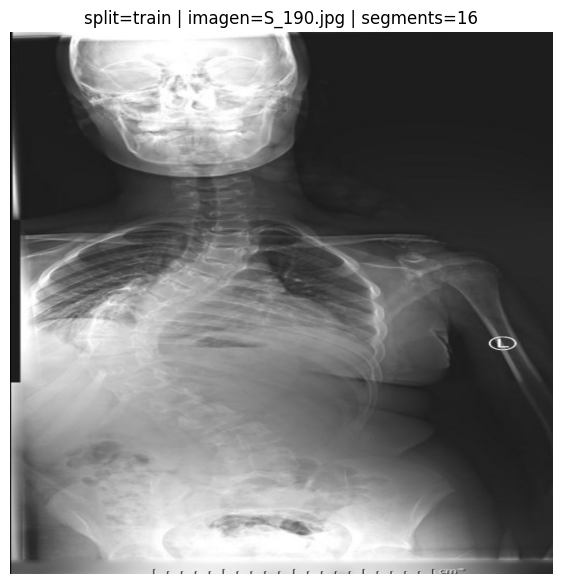

Example from val
image : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/images/val/S_67.png
label : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/labels/val/S_67.txt
debug : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/debug/val/S_67.png


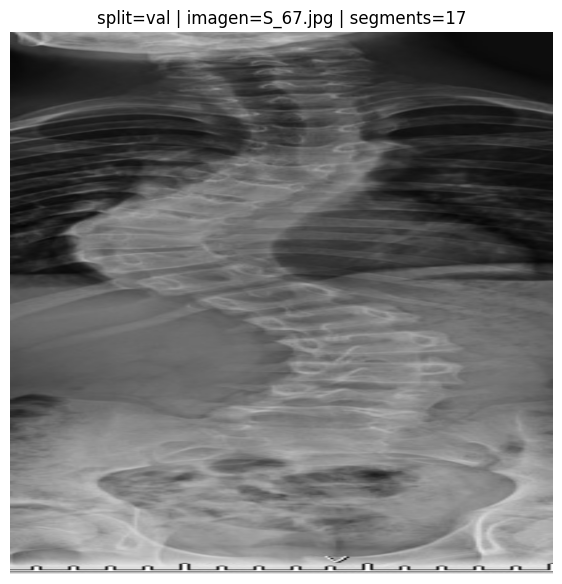

Example from test
image : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/images/test/S_186.png
label : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/labels/test/S_186.txt
debug : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/debug/test/S_186.png


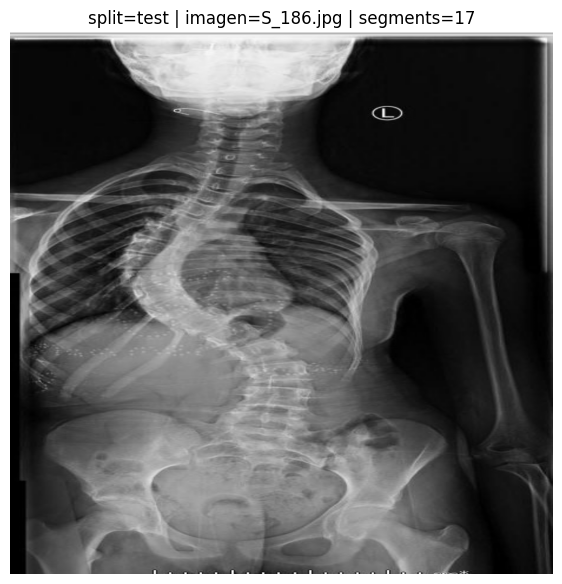

In [ ]:
# =========================================================
# Visualize exported results
# =========================================================

def show_exported_example(export_row):
    img = np.array(Image.open(export_row["export_image_path"]).convert("RGB"))

    fig, ax = plt.subplots(1, 1, figsize=(7, 9))
    ax.imshow(img)
    ax.set_title(
        f"split={export_row['split']} | imagen={export_row['imagen']} | "
        f"segments={export_row['num_segments']}"
    )
    ax.axis("off")
    plt.show()

for split_name in ["train", "val", "test"]:
    subset = export_manifest_df[export_manifest_df["split"] == split_name]
    if len(subset) == 0:
        continue

    sample_row = subset.sample(1, random_state=EXPORT_CONFIG["seed"]).iloc[0]
    print("=" * 100)
    print(f"Example from {split_name}")
    print("image :", sample_row["export_image_path"])
    print("label :", sample_row["export_label_path"])
    print("debug :", sample_row["debug_overlay_path"])
    show_exported_example(sample_row)

In [ ]:
# =========================================================
# Preview a YOLO label file
# =========================================================

preview_row = export_manifest_df.sample(1, random_state=EXPORT_CONFIG["seed"]).iloc[0]
preview_label_path = Path(preview_row["export_label_path"])

print("Preview sample:")
print("imagen:", preview_row["imagen"])
print("label :", preview_label_path)

if preview_label_path.exists():
    preview_text = preview_label_path.read_text(encoding="utf-8")
    print("\nLabel file contents (first 20 lines):")
    print("\n".join(preview_text.splitlines()[:20]))
else:
    print("Label file does not exist.")

Preview sample:
imagen: N_50.jpg
label : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/labels/train/N_50.txt

Label file contents (first 20 lines):
0 0.463542 0.119792 0.463542 0.121875 0.468750 0.121875 0.469792 0.126042 0.476042 0.126042 0.477083 0.128125 0.489583 0.128125 0.490625 0.126042 0.543750 0.126042 0.550000 0.125000 0.551042 0.122917 0.632292 0.126042 0.633333 0.128125 0.693750 0.128125 0.694792 0.126042 0.713542 0.125000 0.713542 0.107292 0.701042 0.106250 0.700000 0.104167 0.680208 0.103125 0.496875 0.104167 0.495833 0.106250 0.483333 0.106250 0.482292 0.109375 0.469792 0.110417 0.469792 0.118750
1 0.456250 0.157292 0.462500 0.157292 0.463542 0.159375 0.482292 0.160417 0.483333 0.162500 0.536458 0.163542 0.537500 0.165625 0.693750 0.165625 0.694792 0.163542 0.713542 0.162500 0.714583 0.160417 0.727083 0.1593

In [ ]:
# =========================================================
# Save section metadata
# =========================================================

section3_meta = {
    "export_mode": EXPORT_CONFIG["export_mode"],
    "active_img_size": ACTIVE_IMG_SIZE,
    "yolo_root": str(YOLO_ROOT),
    "dataset_yaml": str(yolo_yaml_path),
    "mapping_json": str(mapping_json_path),
    "num_train_exported": int((export_manifest_df["split"] == "train").sum()),
    "num_val_exported": int((export_manifest_df["split"] == "val").sum()),
    "num_test_exported": int((export_manifest_df["split"] == "test").sum()),
    "num_total_segments": int(len(export_segments_df)),
    "notes": [
        "Images were resized with bilinear interpolation.",
        "Masks were resized with nearest-neighbor interpolation.",
        "Multiclass ID masks were converted into YOLO polygon segmentation labels.",
        "Original class IDs 1..17 map to YOLO classes 0..16.",
    ],
}

section3_meta_path = YOLO_META_DIR / "section3_export_metadata.json"
with open(section3_meta_path, "w", encoding="utf-8") as f:
    json.dump(section3_meta, f, indent=2, ensure_ascii=False)

print("Saved:", section3_meta_path)
print(json.dumps(section3_meta, indent=2, ensure_ascii=False))

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/meta/section3_export_metadata.json
{
  "export_mode": "local_full",
  "active_img_size": 960,
  "yolo_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist",
  "dataset_yaml": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/dataset.yaml",
  "mapping_json": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_prio

In [ ]:
print("Section 3 complete.")
print("YOLO-ready export created at:")
print("YOLO_EXPORT_BASE_ROOT :", YOLO_EXPORT_BASE_ROOT)
print("YOLO_DATASET_VARIANT  :", YOLO_DATASET_VARIANT)
print("YOLO_ROOT             :", YOLO_ROOT)
print("YOLO_IMAGES_DIR       :", YOLO_IMAGES_DIR)
print("YOLO_LABELS_DIR       :", YOLO_LABELS_DIR)
print("YOLO_DEBUG_DIR        :", YOLO_DEBUG_DIR)
print("YOLO_META_DIR         :", YOLO_META_DIR)
print("dataset.yaml          :", yolo_yaml_path)
print("mapping json          :", mapping_json_path)
print("export manifest       :", export_manifest_path)
print("segment manifest      :", export_segments_path)
print("section3 meta         :", section3_meta_path)

Section 3 complete.
YOLO-ready export created at:
YOLO_EXPORT_BASE_ROOT : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg
YOLO_DATASET_VARIANT  : all_current_corrected_priority_minfg10_ignorelist
YOLO_ROOT             : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist
YOLO_IMAGES_DIR       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/images
YOLO_LABELS_DIR       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected

# Section 4 — YOLOv8m-seg Training

This section does:

1. Check/install Ultralytics
2. Define training modes for local and Colab
3. Configure a conservative medical-imaging augmentation policy
4. Train YOLOv8m-seg
5. Save run metadata and key artifact paths

Notes:
- This is the first reproducible baseline
- Augmentations are intentionally mild
- Horizontal flip is disabled
- We use the held-out test set only for later evaluation, not for model selection

In [ ]:
# =========================================================
# Install / check dependencies
# =========================================================

import sys
import subprocess
import importlib

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        return importlib.import_module(import_name)

ultralytics = ensure_package("ultralytics")
torch = ensure_package("torch")

from ultralytics import YOLO

print("Ultralytics version:", ultralytics.__version__)
print("Torch version      :", torch.__version__)
print("MPS available      :", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
print("CUDA available     :", torch.cuda.is_available())

Installing ultralytics ...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.41
Torch version      : 2.10.0+cu128
MPS available      : False
CUDA available     : True


In [ ]:
# =========================================================
# Training config
# =========================================================

TRAIN_CONFIG = {
    # Modes:
    # - local_debug    : quick sanity training
    # - local_full     : real local baseline
    # - colab_strong   : stronger run in Colab GPU
    "train_mode": "colab_strong" if RUN_ENV == "colab" else "local_full",

    # Model
    "model_name": "yolov8m-seg.pt",

    # Dataset variant / paths
    "dataset_variant": YOLO_DATASET_VARIANT,
    "dataset_yaml": str(YOLO_ROOT / "dataset.yaml"),
    "training_runs_root": str(TRAINING_RUNS_ROOT),

    # New controlled experiment: moderate coverage filter, same general recipe
    "run_name_prefix": "vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained",

    # Reproducibility
    "seed": CONFIG["seed"],

    # Workers
    "local_debug_workers": 0,
    "local_full_workers": 0,
    "colab_strong_workers": 2,

    # Keep the current corrected-mask recipe stable
    "local_debug_epochs": 8,
    "local_full_epochs": 120,
    "colab_strong_epochs": 120,

    "local_debug_batch": 4,
    "local_full_batch": 2,
    "colab_strong_batch": 8,

    "local_debug_imgsz": 640,
    "local_full_imgsz": ACTIVE_IMG_SIZE,
    "colab_strong_imgsz": ACTIVE_IMG_SIZE,

    # Early stopping remains enabled
    "patience_local": 15,
    "patience_colab": 18,

    # Optimization unchanged
    "optimizer": "AdamW",
    "lr0": 5.0e-4,
    "lrf": 1e-2,
    "weight_decay": 5e-4,

    # Validation / saving
    "val": True,
    "save": True,
    "save_period": 10,

    # Precision
    "amp": False,

    # Determinism
    "deterministic": True,

    # Conservative medical augmentations
    "degrees": 3.0,
    "translate": 0.02,
    "scale": 0.08,
    "shear": 0.0,
    "perspective": 0.0,
    "fliplr": 0.0,
    "flipud": 0.0,
    "mosaic": 0.0,
    "mixup": 0.0,
    "copy_paste": 0.0,

    # Mild appearance changes only
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.03,

    # Segmentation / mask behavior
    "overlap_mask": False,
    "mask_ratio": 1,

    # Plotting
    "plots": True,
}

print(json.dumps(TRAIN_CONFIG, indent=2))
print("\nTraining outputs will be written under:")
print(TRAIN_CONFIG["training_runs_root"])

print("\nNext controlled experiment notes:")
print("- corrected-mask priority remains active")
print("- fallback to original mask remains active")
print("- moderate actual-mask foreground filter added: min_fg_classes_required = 10")
print("- training recipe otherwise remains stable")

{
  "train_mode": "colab_strong",
  "model_name": "yolov8m-seg.pt",
  "dataset_variant": "all_current_corrected_priority_minfg10_ignorelist",
  "dataset_yaml": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/dataset.yaml",
  "training_runs_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs",
  "run_name_prefix": "vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained",
  "seed": 42,
  "local_debug_workers": 0,
  "local_full_workers": 0,
  "colab_strong_workers": 2,
  "local_debug_epochs": 8,
  "local_full_epochs": 120,
  "colab_strong_epochs": 120,
  "local_debug_batch": 4,
  "local_full_batch": 2,
  "colab_strong_batch": 8,
  "local_debug_imgsz": 640,
  "local_full_imgsz": 960,
  "colab_strong_imgsz": 960,
  "p

In [ ]:
# =========================================================
# Training initialization config
# =========================================================

TRAIN_INIT_CONFIG = {
    # Explicit initialization modes:
    # - "pretrained"         : start from base pretrained model weights
    # - "resume_same_run"    : resume the CURRENT run from its own last.pt
    # - "finetune_from_best" : start a NEW/FRESH run from a PREVIOUS run's best.pt
    #
    # Corrected-mask experiment:
    # use pretrained start so improved labels can be judged more fairly
    "init_mode": "pretrained",

    # Not used in pretrained mode
    "source_run_name": None,
    "source_best_weights_path": None,
}

print("TRAIN_INIT_CONFIG")
print(json.dumps(TRAIN_INIT_CONFIG, indent=2))

TRAIN_INIT_CONFIG
{
  "init_mode": "pretrained",
  "source_run_name": null,
  "source_best_weights_path": null
}


In [ ]:
# =========================================================
# New-run safety guard (prevents accidental reuse of finished runs)
# =========================================================

# This guard is only for non-resume modes.
# It helps catch cases where a reused run name causes training to appear to finish instantly.

if TRAIN_INIT_CONFIG["init_mode"] != "resume_same_run":
    candidate_run_name = (
        f"{TRAIN_CONFIG['run_name_prefix']}"
        f"_{TRAIN_CONFIG['dataset_variant']}"
        f"_{TRAIN_CONFIG['train_mode']}"
        f"_img{ACTIVE_IMG_SIZE}"
        f"_seed{TRAIN_CONFIG['seed']}"
    )

    candidate_run_dir = Path(TRAIN_CONFIG["training_runs_root"]) / candidate_run_name
    candidate_results_csv = candidate_run_dir / "results.csv"
    candidate_best_pt = candidate_run_dir / "weights" / "best.pt"
    candidate_last_pt = candidate_run_dir / "weights" / "last.pt"

    print("Candidate V10 run name :", candidate_run_name)
    print("Candidate V10 run dir  :", candidate_run_dir)

    if candidate_run_dir.exists():
        print("\nWARNING: candidate run directory already exists.")
        print("results.csv exists:", candidate_results_csv.exists())
        print("best.pt exists     :", candidate_best_pt.exists())
        print("last.pt exists     :", candidate_last_pt.exists())

        raise FileExistsError(
            "Non-resume training would reuse an existing run directory. "
            "Change run_name_prefix before training, or switch to resume_same_run only if you truly want to continue that exact run."
        )
    else:
        print("OK: candidate V10 run directory does not exist yet. Safe to start a new run.")
else:
    print("resume_same_run mode is active; skip new-run safety guard.")

Candidate V10 run name : vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
Candidate V10 run dir  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
OK: candidate V10 run directory does not exist yet. Safe to start a new run.


In [ ]:
# =========================================================
# Protected corrected-mask reference run config
# =========================================================

REFERENCE_RUN_CONFIG = {
    "reference_run_name": CONFIG["protected_reference_run_name"],
    "reference_label": "protected_corrected_reference",
}

print("REFERENCE_RUN_CONFIG")
print(json.dumps(REFERENCE_RUN_CONFIG, indent=2))

REFERENCE_RUN_CONFIG
{
  "reference_run_name": "vertebra_yolov8m_seg_v9_corrected_masks_pretrained_all_current_corrected_priority_ignorelist_colab_strong_img960_seed42",
  "reference_label": "protected_corrected_reference"
}


In [ ]:
# =========================================================
# Resolve active settings
# =========================================================

def detect_training_device():
    if torch.cuda.is_available():
        return 0
    return "cpu"

def resolve_mode_params(cfg):
    mode = cfg["train_mode"]

    if mode == "local_debug":
        return {
            "epochs": cfg["local_debug_epochs"],
            "batch": cfg["local_debug_batch"],
            "imgsz": cfg["local_debug_imgsz"],
            "workers": cfg["local_debug_workers"],
            "patience": min(cfg["patience_local"], cfg["local_debug_epochs"]),
        }
    elif mode == "local_full":
        return {
            "epochs": cfg["local_full_epochs"],
            "batch": cfg["local_full_batch"],
            "imgsz": cfg["local_full_imgsz"],
            "workers": cfg["local_full_workers"],
            "patience": cfg["patience_local"],
        }
    elif mode == "colab_strong":
        return {
            "epochs": cfg["colab_strong_epochs"],
            "batch": cfg["colab_strong_batch"],
            "imgsz": cfg["colab_strong_imgsz"],
            "workers": cfg["colab_strong_workers"],
            "patience": cfg["patience_colab"],
        }
    else:
        raise ValueError(f"Unknown train_mode: {mode}")

ACTIVE_TRAIN_PARAMS = resolve_mode_params(TRAIN_CONFIG)
DEVICE = detect_training_device()

run_suffix = ""
try:
    if TRAIN_INIT_CONFIG["init_mode"] == "finetune_from_best":
        if TRAIN_INIT_CONFIG.get("source_run_name"):
            source_stub = TRAIN_INIT_CONFIG["source_run_name"].replace("vertebra_yolov8m_seg_", "")
            run_suffix = f"_ft_from_{source_stub}"
        else:
            run_suffix = "_ft_from_best"
    elif TRAIN_INIT_CONFIG["init_mode"] == "resume_same_run":
        run_suffix = ""
    elif TRAIN_INIT_CONFIG["init_mode"] == "pretrained":
        run_suffix = ""
except Exception:
    run_suffix = ""

# Include near-complete threshold in run naming only when relevant
filter_suffix = ""
if FILTER_CONFIG["filter_mode"] == "near_complete":
    filter_suffix = f"_min{FILTER_CONFIG['near_complete_min_labels']}"

RUN_NAME = (
    f"{TRAIN_CONFIG['run_name_prefix']}_"
    f"{TRAIN_CONFIG['dataset_variant']}{filter_suffix}_"
    f"{TRAIN_CONFIG['train_mode']}_"
    f"img{ACTIVE_TRAIN_PARAMS['imgsz']}_"
    f"seed{TRAIN_CONFIG['seed']}"
    f"{run_suffix}"
)

RUN_DIR = Path(TRAIN_CONFIG["training_runs_root"]) / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_WEIGHTS_PATH = WEIGHTS_DIR / "best.pt"
LAST_WEIGHTS_PATH = WEIGHTS_DIR / "last.pt"
RESULTS_CSV_PATH = RUN_DIR / "results.csv"
ARGS_YAML_PATH = RUN_DIR / "args.yaml"

print("DEVICE              :", DEVICE)
print("ACTIVE_TRAIN_PARAMS :", ACTIVE_TRAIN_PARAMS)
print("RUN_NAME            :", RUN_NAME)
print("RUN_DIR             :", RUN_DIR)
print("WEIGHTS_DIR         :", WEIGHTS_DIR)
print("BEST_WEIGHTS_PATH   :", BEST_WEIGHTS_PATH)
print("LAST_WEIGHTS_PATH   :", LAST_WEIGHTS_PATH)

DEVICE              : 0
ACTIVE_TRAIN_PARAMS : {'epochs': 120, 'batch': 8, 'imgsz': 960, 'workers': 2, 'patience': 18}
RUN_NAME            : vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
RUN_DIR             : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
WEIGHTS_DIR         : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights
BEST_WEIGHTS_PATH   : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grad

In [ ]:
# =========================================================
# Pre-flight checks
# =========================================================

DATASET_YAML_PATH = Path(TRAIN_CONFIG["dataset_yaml"])
assert DATASET_YAML_PATH.exists(), f"Dataset YAML not found: {DATASET_YAML_PATH}"

for split_name in ["train", "val", "test"]:
    img_dir = YOLO_IMAGES_DIR / split_name
    lbl_dir = YOLO_LABELS_DIR / split_name
    print(f"{split_name:5s} images exists:", img_dir.exists(), "| count:", len(list(img_dir.glob("*"))))
    print(f"{split_name:5s} labels exists:", lbl_dir.exists(), "| count:", len(list(lbl_dir.glob("*.txt"))))

print("\nDataset YAML:")
print(DATASET_YAML_PATH.read_text(encoding="utf-8"))

train images exists: True | count: 173
train labels exists: True | count: 173
val   images exists: True | count: 37
val   labels exists: True | count: 37
test  images exists: True | count: 38
test  labels exists: True | count: 38

Dataset YAML:
path: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist
train: images/train
val: images/val
test: images/test

names:
  0: T1
  1: T2
  2: T3
  3: T4
  4: T5
  5: T6
  6: T7
  7: T8
  8: T9
  9: T10
  10: T11
  11: T12
  12: L1
  13: L2
  14: L3
  15: L4
  16: L5



In [ ]:
# =========================================================
# Practical note
# =========================================================

if DEVICE == "cpu":
    print("Training will be very slow on CPU.")
elif DEVICE == "mps":
    print("Using Apple Silicon MPS. Good for local baseline, but batch size may need to stay small.")
elif DEVICE == 0:
    print("Using CUDA GPU.")

print("\nIf you hit memory errors on Mac, reduce batch from 4 to 2.")
print("If training is stable and memory is fine, you can later try batch=6 or batch=8.")

Using CUDA GPU.

If you hit memory errors on Mac, reduce batch from 4 to 2.
If training is stable and memory is fine, you can later try batch=6 or batch=8.


In [ ]:
# =========================================================
# Training args
# =========================================================

train_args = {
    "data": TRAIN_CONFIG["dataset_yaml"],
    "epochs": ACTIVE_TRAIN_PARAMS["epochs"],
    "imgsz": ACTIVE_TRAIN_PARAMS["imgsz"],
    "batch": ACTIVE_TRAIN_PARAMS["batch"],
    "device": DEVICE,
    "workers": ACTIVE_TRAIN_PARAMS["workers"],
    "project": TRAIN_CONFIG["training_runs_root"],
    "name": RUN_NAME,
    "seed": TRAIN_CONFIG["seed"],
    "deterministic": TRAIN_CONFIG["deterministic"],

    # Optimization
    "optimizer": TRAIN_CONFIG["optimizer"],
    "lr0": TRAIN_CONFIG["lr0"],
    "lrf": TRAIN_CONFIG["lrf"],
    "weight_decay": TRAIN_CONFIG["weight_decay"],

    # Saving / validation
    "val": TRAIN_CONFIG["val"],
    "save": TRAIN_CONFIG["save"],
    "save_period": TRAIN_CONFIG["save_period"],
    "patience": ACTIVE_TRAIN_PARAMS["patience"],
    "plots": TRAIN_CONFIG["plots"],
    "amp": TRAIN_CONFIG["amp"],

    # Augmentation (mild)
    "degrees": TRAIN_CONFIG["degrees"],
    "translate": TRAIN_CONFIG["translate"],
    "scale": TRAIN_CONFIG["scale"],
    "shear": TRAIN_CONFIG["shear"],
    "perspective": TRAIN_CONFIG["perspective"],
    "fliplr": TRAIN_CONFIG["fliplr"],
    "flipud": TRAIN_CONFIG["flipud"],
    "mosaic": TRAIN_CONFIG["mosaic"],
    "mixup": TRAIN_CONFIG["mixup"],
    "copy_paste": TRAIN_CONFIG["copy_paste"],
    "hsv_h": TRAIN_CONFIG["hsv_h"],
    "hsv_s": TRAIN_CONFIG["hsv_s"],
    "hsv_v": TRAIN_CONFIG["hsv_v"],

    # Segmentation-specific behavior
    "overlap_mask": TRAIN_CONFIG["overlap_mask"],
    "mask_ratio": TRAIN_CONFIG["mask_ratio"],
}

print(json.dumps(train_args, indent=2, default=str))
print("\nTraining setup summary:")
print("RUN_DIR            :", RUN_DIR)
print("RESULTS_CSV_PATH   :", RESULTS_CSV_PATH)
print("BEST_WEIGHTS_PATH  :", BEST_WEIGHTS_PATH)
print("LAST_WEIGHTS_PATH  :", LAST_WEIGHTS_PATH)
print("INIT_MODE          :", TRAIN_INIT_CONFIG["init_mode"])

{
  "data": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/dataset.yaml",
  "epochs": 120,
  "imgsz": 960,
  "batch": 8,
  "device": 0,
  "workers": 2,
  "project": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs",
  "name": "vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42",
  "seed": 42,
  "deterministic": true,
  "optimizer": "AdamW",
  "lr0": 0.0005,
  "lrf": 0.01,
  "weight_decay": 0.0005,
  "val": true,
  "save": true,
  "save_period": 10,
  "patience": 18,
  "plots": true,
  "amp": false,
  "degrees": 3.0,
  "translate": 0.02,
  "scale": 0.08,
  "shear": 0.0,
  "perspective": 0.0,
  "fliplr": 0.0,
  "flipud": 0.0,
  "mosaic": 

In [ ]:
# =========================================================
# Checkpoint resolution
# =========================================================

CURRENT_RUN_LAST_PATH = LAST_WEIGHTS_PATH
CURRENT_RUN_BEST_PATH = BEST_WEIGHTS_PATH

SOURCE_RUN_DIR = None
SOURCE_BEST_FROM_RUN = None

if TRAIN_INIT_CONFIG["source_run_name"]:
    SOURCE_RUN_DIR = Path(TRAIN_CONFIG["training_runs_root"]) / TRAIN_INIT_CONFIG["source_run_name"]
    SOURCE_BEST_FROM_RUN = SOURCE_RUN_DIR / "weights" / "best.pt"

DIRECT_SOURCE_BEST_PATH = (
    Path(TRAIN_INIT_CONFIG["source_best_weights_path"])
    if TRAIN_INIT_CONFIG["source_best_weights_path"] not in [None, ""]
    else None
)

CHECKPOINT_INFO = {
    "current_run_dir_exists": RUN_DIR.exists(),
    "current_weights_dir_exists": WEIGHTS_DIR.exists(),
    "current_best_exists": CURRENT_RUN_BEST_PATH.exists(),
    "current_last_exists": CURRENT_RUN_LAST_PATH.exists(),
    "source_run_dir": str(SOURCE_RUN_DIR) if SOURCE_RUN_DIR is not None else None,
    "source_best_from_run": str(SOURCE_BEST_FROM_RUN) if SOURCE_BEST_FROM_RUN is not None else None,
    "source_best_from_run_exists": SOURCE_BEST_FROM_RUN.exists() if SOURCE_BEST_FROM_RUN is not None else False,
    "direct_source_best_path": str(DIRECT_SOURCE_BEST_PATH) if DIRECT_SOURCE_BEST_PATH is not None else None,
    "direct_source_best_exists": DIRECT_SOURCE_BEST_PATH.exists() if DIRECT_SOURCE_BEST_PATH is not None else False,
}

print("Checkpoint status:")
print(json.dumps(CHECKPOINT_INFO, indent=2))

init_mode = TRAIN_INIT_CONFIG["init_mode"]

TRAIN_LAUNCH_MODE = None
TRAIN_MODEL_SOURCE = None
RESUME_FLAG = False
TRAIN_MODE_DESCRIPTION = None

if init_mode == "pretrained":
    TRAIN_LAUNCH_MODE = "pretrained"
    TRAIN_MODEL_SOURCE = TRAIN_CONFIG["model_name"]
    RESUME_FLAG = False
    TRAIN_MODE_DESCRIPTION = "pretrained start from base YOLO weights"

elif init_mode == "resume_same_run":
    assert CURRENT_RUN_LAST_PATH.exists(), (
        f"init_mode='resume_same_run' requires existing last.pt at: {CURRENT_RUN_LAST_PATH}"
    )
    TRAIN_LAUNCH_MODE = "resume_same_run"
    TRAIN_MODEL_SOURCE = str(CURRENT_RUN_LAST_PATH)
    RESUME_FLAG = True
    TRAIN_MODE_DESCRIPTION = "resume from SAME run last.pt"

elif init_mode == "finetune_from_best":
    if DIRECT_SOURCE_BEST_PATH is not None:
        assert DIRECT_SOURCE_BEST_PATH.exists(), (
            f"Provided source_best_weights_path does not exist: {DIRECT_SOURCE_BEST_PATH}"
        )
        TRAIN_LAUNCH_MODE = "finetune_from_best"
        TRAIN_MODEL_SOURCE = str(DIRECT_SOURCE_BEST_PATH)
        RESUME_FLAG = False
        TRAIN_MODE_DESCRIPTION = "fine-tune from PREVIOUS run best.pt (direct path)"
    elif SOURCE_BEST_FROM_RUN is not None:
        assert SOURCE_BEST_FROM_RUN.exists(), (
            f"Could not find best.pt in source_run_name folder: {SOURCE_BEST_FROM_RUN}"
        )
        TRAIN_LAUNCH_MODE = "finetune_from_best"
        TRAIN_MODEL_SOURCE = str(SOURCE_BEST_FROM_RUN)
        RESUME_FLAG = False
        TRAIN_MODE_DESCRIPTION = "fine-tune from PREVIOUS run best.pt (source_run_name)"
    else:
        raise ValueError(
            "init_mode='finetune_from_best' requires either source_run_name or source_best_weights_path."
        )
else:
    raise ValueError(f"Unknown init_mode: {init_mode}")

print("\nResolved training initialization:")
print(f"- init_mode              : {TRAIN_INIT_CONFIG['init_mode']}")
print(f"- current run name       : {RUN_NAME}")
print(f"- resolved launch mode   : {TRAIN_LAUNCH_MODE}")
print(f"- training description   : {TRAIN_MODE_DESCRIPTION}")
print(f"- resolved weights source: {TRAIN_MODEL_SOURCE}")
print(f"- resume flag            : {RESUME_FLAG}")

if TRAIN_LAUNCH_MODE == "pretrained":
    print("\nStarting new training from pretrained base model weights.")
elif TRAIN_LAUNCH_MODE == "resume_same_run":
    print("\nResuming training from the SAME run's last checkpoint.")
elif TRAIN_LAUNCH_MODE == "finetune_from_best":
    print("\nStarting a NEW run by fine-tuning from a PREVIOUS run's best checkpoint.")

Checkpoint status:
{
  "current_run_dir_exists": false,
  "current_weights_dir_exists": false,
  "current_best_exists": false,
  "current_last_exists": false,
  "source_run_dir": null,
  "source_best_from_run": null,
  "source_best_from_run_exists": false,
  "direct_source_best_path": null,
  "direct_source_best_exists": false
}

Resolved training initialization:
- init_mode              : pretrained
- current run name       : vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
- resolved launch mode   : pretrained
- training description   : pretrained start from base YOLO weights
- resolved weights source: yolov8m-seg.pt
- resume flag            : False

Starting new training from pretrained base model weights.


In [ ]:
# =========================================================
# Train YOLOv8m-seg
# =========================================================

print("Training launch summary:")
print(f"- RUN_NAME          : {RUN_NAME}")
print(f"- TRAIN_LAUNCH_MODE : {TRAIN_LAUNCH_MODE}")
print(f"- TRAIN_MODEL_SOURCE: {TRAIN_MODEL_SOURCE}")
print(f"- RESUME_FLAG       : {RESUME_FLAG}")

model = YOLO(TRAIN_MODEL_SOURCE)

if RESUME_FLAG:
    train_results = model.train(resume=True)
else:
    train_results = model.train(**train_args)

print("\nTraining finished.")
print("TRAIN_LAUNCH_MODE :", TRAIN_LAUNCH_MODE)
print("TRAIN_MODEL_SOURCE:", TRAIN_MODEL_SOURCE)
print("RESUME_FLAG       :", RESUME_FLAG)
print(train_results)

Training launch summary:
- RUN_NAME          : vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
- TRAIN_LAUNCH_MODE : pretrained
- TRAIN_MODEL_SOURCE: yolov8m-seg.pt
- RESUME_FLAG       : False
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_vertebra_seg/all_current_corrected_priority_minfg10_ignorelist/dataset.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=No

In [ ]:
# =========================================================
# Resolve run output paths
# =========================================================

# Re-resolve from the known run directory so later cells stay stable
RUN_DIR = Path(TRAIN_CONFIG["training_runs_root"]) / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_WEIGHTS_PATH = WEIGHTS_DIR / "best.pt"
LAST_WEIGHTS_PATH = WEIGHTS_DIR / "last.pt"
RESULTS_CSV_PATH = RUN_DIR / "results.csv"
ARGS_YAML_PATH = RUN_DIR / "args.yaml"

print("RUN_DIR           :", RUN_DIR)
print("WEIGHTS_DIR       :", WEIGHTS_DIR)
print("BEST_WEIGHTS_PATH :", BEST_WEIGHTS_PATH, "| exists:", BEST_WEIGHTS_PATH.exists())
print("LAST_WEIGHTS_PATH :", LAST_WEIGHTS_PATH, "| exists:", LAST_WEIGHTS_PATH.exists())
print("RESULTS_CSV_PATH  :", RESULTS_CSV_PATH, "| exists:", RESULTS_CSV_PATH.exists())
print("ARGS_YAML_PATH    :", ARGS_YAML_PATH, "| exists:", ARGS_YAML_PATH.exists())

RUN_DIR           : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
WEIGHTS_DIR       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights
BEST_WEIGHTS_PATH : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights/best.pt | exists: True
LAST_WEIGHTS_PATH : /content/drive/My

In [ ]:
# =========================================================
# Load training history
# =========================================================

if RESULTS_CSV_PATH.exists():
    results_df = pd.read_csv(RESULTS_CSV_PATH)
    print("results.csv shape:", results_df.shape)
    display(results_df.head())
    display(results_df.tail())
else:
    results_df = None
    print("results.csv not found.")

results.csv shape: (56, 23)


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),metrics/precision(M),metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,56.3165,1.84672,3.51888,3.51471,1.87086,0,0.21755,0.16450,0.04708,0.02050,0.13664,0.01636,0.00214,0.00074,2.13882,36.35710,4.88869,2.00642,0,0.000105,0.000105,0.079105
1,2,102.7620,1.28897,2.61322,2.23118,1.40862,0,0.16078,0.32539,0.08095,0.05147,0.00000,0.00000,0.00000,0.00000,1.46041,48.19360,32.93240,1.51465,0,0.000213,0.000213,0.057213
2,3,157.4980,1.20708,2.34238,1.84728,1.33143,0,0.25539,0.62368,0.31169,0.20238,0.13960,0.17436,0.08370,0.02824,1.20655,17.92670,3.92169,1.36239,0,0.000320,0.000320,0.035320
3,4,210.2820,1.13722,2.16714,1.75084,1.28138,0,0.19199,0.56481,0.23457,0.15199,0.10094,0.27228,0.09864,0.04895,1.24956,9.01076,2.65400,1.34322,0,0.000424,0.000424,0.013424
4,5,258.5700,1.07254,2.03569,1.68664,1.24219,0,0.31694,0.68622,0.41110,0.27397,0.27615,0.59333,0.31093,0.15518,1.12272,4.83324,2.26997,1.27484,0,0.000483,0.000483,0.000483


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),metrics/precision(M),metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
51,52,2660.29,0.42729,0.79572,0.29402,0.85057,0,0.79105,0.81554,0.83863,0.61338,0.78451,0.81040,0.82652,0.57984,0.93689,1.88801,0.77099,1.20594,0,0.000290,0.000290,0.000290
52,53,2712.52,0.41496,0.77629,0.28444,0.85079,0,0.80965,0.81185,0.85763,0.63350,0.80616,0.80174,0.84764,0.59579,0.93266,1.86120,0.72174,1.20243,0,0.000286,0.000286,0.000286
53,54,2765.12,0.41663,0.76674,0.28362,0.84207,0,0.75263,0.78653,0.82023,0.60389,0.74614,0.78121,0.81006,0.56972,0.94485,1.85665,0.80392,1.22238,0,0.000281,0.000281,0.000281
54,55,2816.90,0.42721,0.75855,0.28957,0.85161,0,0.75116,0.83824,0.84304,0.62058,0.74375,0.82836,0.82849,0.58774,0.93925,1.89772,0.74622,1.21861,0,0.000277,0.000277,0.000277
55,56,2865.18,0.41294,0.76552,0.28268,0.84925,0,0.76855,0.82281,0.84328,0.62178,0.76253,0.81693,0.83256,0.58858,0.93971,1.94586,0.73735,1.21415,0,0.000273,0.000273,0.000273


Available columns:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


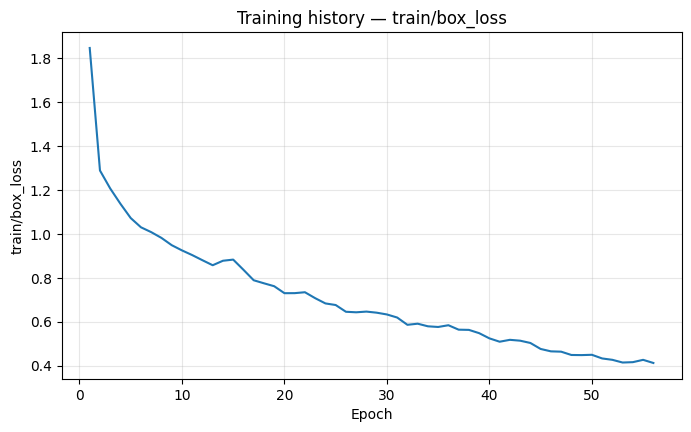

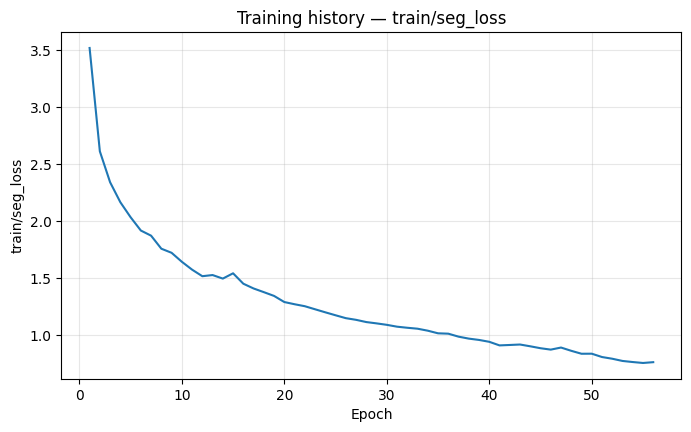

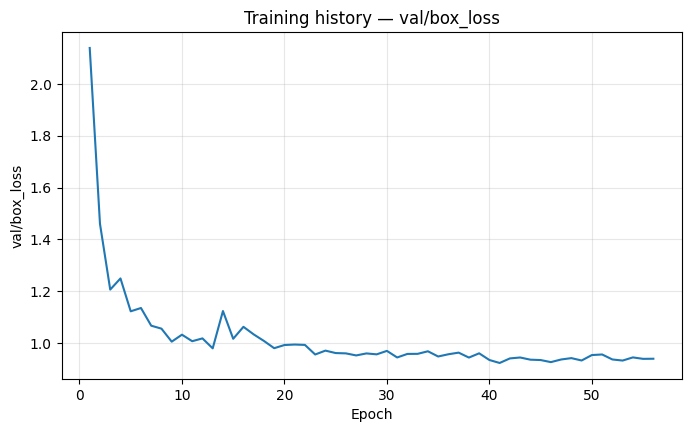

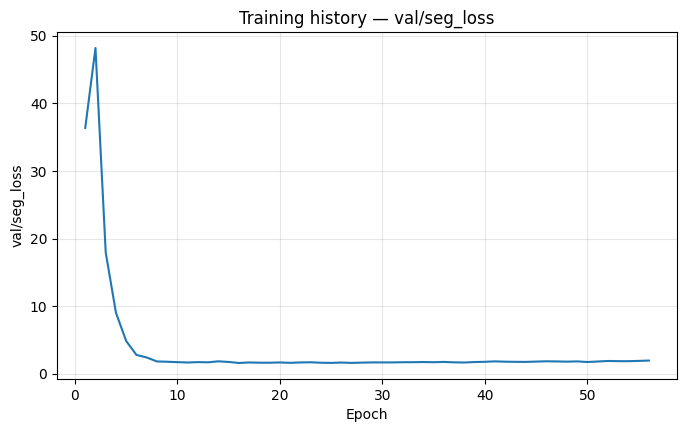

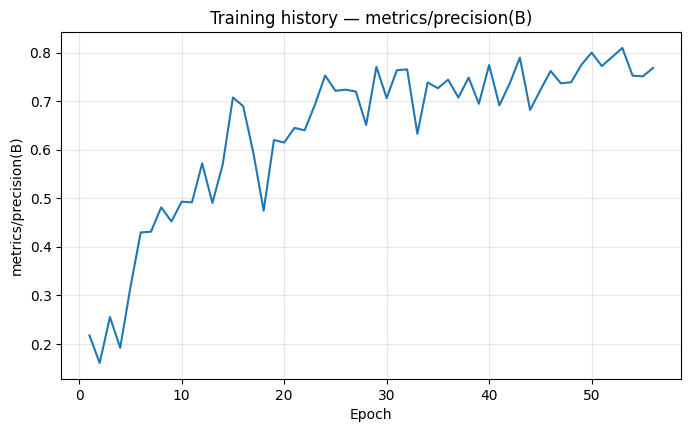

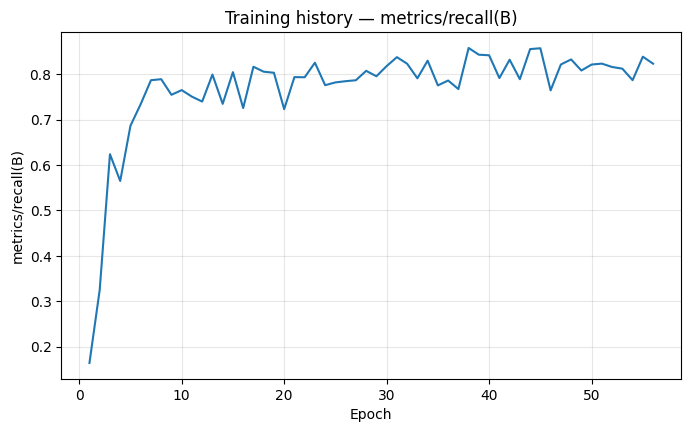

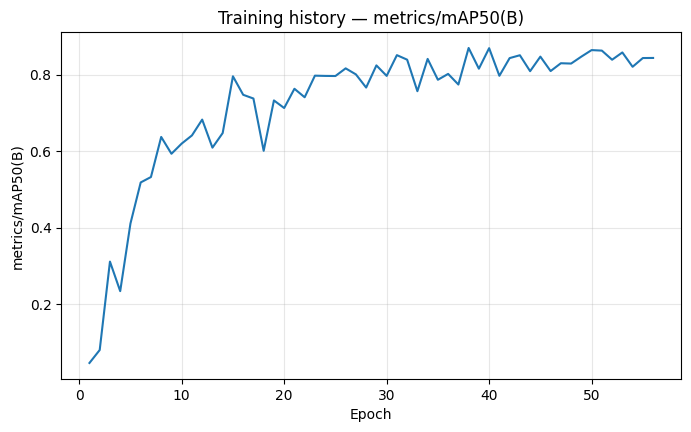

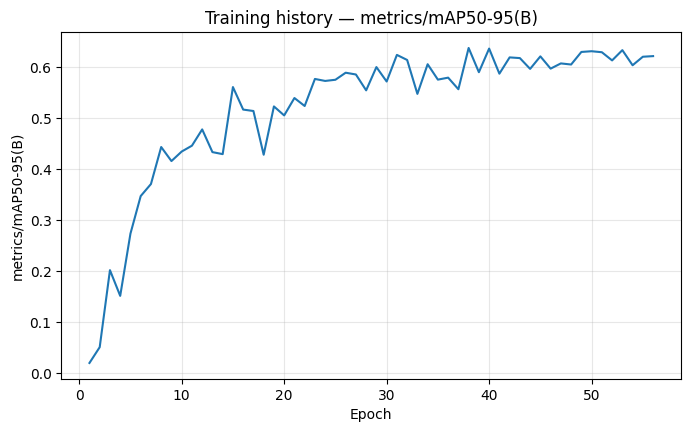

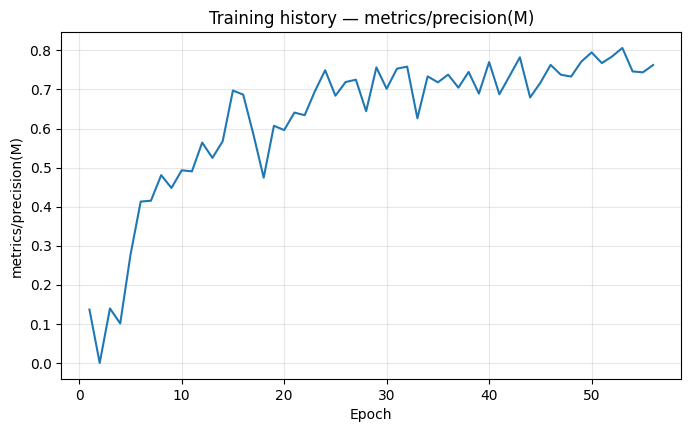

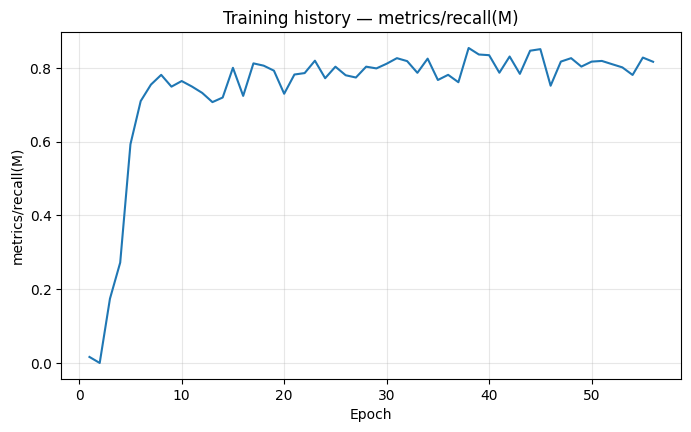

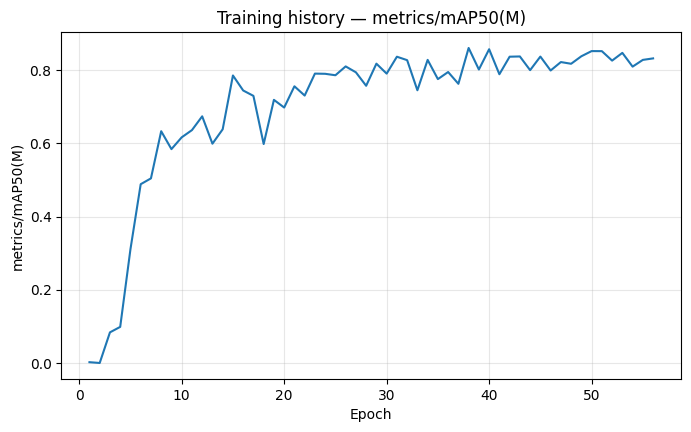

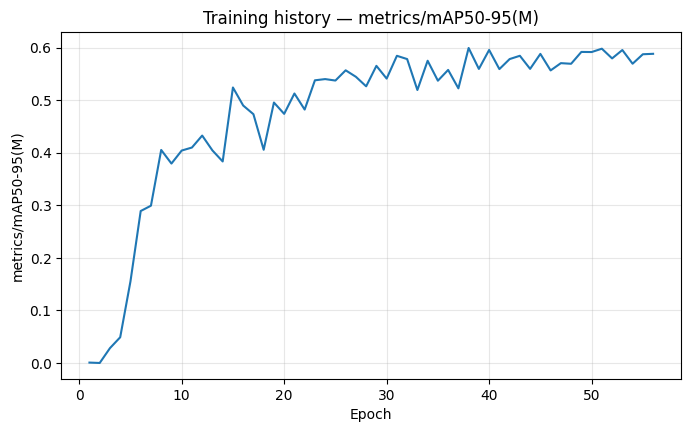

In [ ]:
# =========================================================
# Plot key curves from results.csv
# =========================================================

if results_df is not None:
    available_cols = results_df.columns.tolist()
    print("Available columns:")
    print(available_cols)

    def plot_metric(df, y_col, title):
        if y_col not in df.columns:
            print(f"Skipping missing column: {y_col}")
            return
        plt.figure(figsize=(8, 4.5))
        plt.plot(df["epoch"], df[y_col])
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(y_col)
        plt.grid(True, alpha=0.3)
        plt.show()

    likely_cols = [
        "train/box_loss",
        "train/seg_loss",
        "val/box_loss",
        "val/seg_loss",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "metrics/precision(M)",
        "metrics/recall(M)",
        "metrics/mAP50(M)",
        "metrics/mAP50-95(M)",
    ]

    for col in likely_cols:
        plot_metric(results_df, col, f"Training history — {col}")
else:
    print("No results dataframe available.")

In [ ]:
# =========================================================
# Save compact training summary
# =========================================================

def safe_last_value(df, col):
    if df is None or col not in df.columns or len(df) == 0:
        return None
    val = df[col].iloc[-1]
    try:
        return float(val)
    except Exception:
        return str(val)

training_summary = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),
    "device": str(DEVICE),
    "model_name": TRAIN_CONFIG["model_name"],
    "train_mode": TRAIN_CONFIG["train_mode"],
    "dataset_yaml": TRAIN_CONFIG["dataset_yaml"],
    "best_weights_path": str(BEST_WEIGHTS_PATH),
    "last_weights_path": str(LAST_WEIGHTS_PATH),
    "results_csv_path": str(RESULTS_CSV_PATH),
    "args_yaml_path": str(ARGS_YAML_PATH),
    "epochs_requested": ACTIVE_TRAIN_PARAMS["epochs"],
    "batch": ACTIVE_TRAIN_PARAMS["batch"],
    "imgsz": ACTIVE_TRAIN_PARAMS["imgsz"],
    "patience": ACTIVE_TRAIN_PARAMS["patience"],

    "final_metrics": {
        "precision_box": safe_last_value(results_df, "metrics/precision(B)"),
        "recall_box": safe_last_value(results_df, "metrics/recall(B)"),
        "map50_box": safe_last_value(results_df, "metrics/mAP50(B)"),
        "map50_95_box": safe_last_value(results_df, "metrics/mAP50-95(B)"),
        "precision_mask": safe_last_value(results_df, "metrics/precision(M)"),
        "recall_mask": safe_last_value(results_df, "metrics/recall(M)"),
        "map50_mask": safe_last_value(results_df, "metrics/mAP50(M)"),
        "map50_95_mask": safe_last_value(results_df, "metrics/mAP50-95(M)"),
        "train_seg_loss": safe_last_value(results_df, "train/seg_loss"),
        "val_seg_loss": safe_last_value(results_df, "val/seg_loss"),
    },

    "augmentation_policy": {
        "degrees": TRAIN_CONFIG["degrees"],
        "translate": TRAIN_CONFIG["translate"],
        "scale": TRAIN_CONFIG["scale"],
        "shear": TRAIN_CONFIG["shear"],
        "perspective": TRAIN_CONFIG["perspective"],
        "fliplr": TRAIN_CONFIG["fliplr"],
        "flipud": TRAIN_CONFIG["flipud"],
        "mosaic": TRAIN_CONFIG["mosaic"],
        "mixup": TRAIN_CONFIG["mixup"],
        "copy_paste": TRAIN_CONFIG["copy_paste"],
        "hsv_v": TRAIN_CONFIG["hsv_v"],
    }
}

training_summary_path = RUN_DIR / "training_summary.json"
with open(training_summary_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2, ensure_ascii=False)

print("Saved:", training_summary_path)
print(json.dumps(training_summary, indent=2, ensure_ascii=False))

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/training_summary.json
{
  "run_name": "vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42",
  "run_dir": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42",
  "device": "0",
  "model_name": "yolov8m-seg.pt",
  "train_mode": "colab_strong",
  "dataset_yaml": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yo

In [ ]:
# =========================================================
# Compact training summary (best epoch vs final epoch)
# =========================================================

assert results_df is not None and len(results_df) > 0, "results_df is empty or missing."

metric_candidates_for_best = [
    "metrics/mAP50-95(M)",
    "metrics/mAP50(M)",
    "metrics/mAP50-95(B)",
    "metrics/mAP50(B)",
]

best_metric_col = None
for col in metric_candidates_for_best:
    if col in results_df.columns:
        best_metric_col = col
        break

assert best_metric_col is not None, "Could not find a usable validation metric column in results_df."

best_idx = results_df[best_metric_col].astype(float).idxmax()
best_row = results_df.loc[best_idx]
final_row = results_df.iloc[-1]

def safe_metric(row, col):
    if col not in row.index:
        return None
    try:
        return float(row[col])
    except Exception:
        return row[col]

compact_summary_df = pd.DataFrame([
    {
        "summary_type": "best_epoch",
        "epoch": int(best_row["epoch"]),
        "mAP50(B)": safe_metric(best_row, "metrics/mAP50(B)"),
        "mAP50-95(B)": safe_metric(best_row, "metrics/mAP50-95(B)"),
        "mAP50(M)": safe_metric(best_row, "metrics/mAP50(M)"),
        "mAP50-95(M)": safe_metric(best_row, "metrics/mAP50-95(M)"),
    },
    {
        "summary_type": "final_epoch",
        "epoch": int(final_row["epoch"]),
        "mAP50(B)": safe_metric(final_row, "metrics/mAP50(B)"),
        "mAP50-95(B)": safe_metric(final_row, "metrics/mAP50-95(B)"),
        "mAP50(M)": safe_metric(final_row, "metrics/mAP50(M)"),
        "mAP50-95(M)": safe_metric(final_row, "metrics/mAP50-95(M)"),
    },
])

print("Best metric used to select best epoch:", best_metric_col)
display(compact_summary_df)

best_epoch_num = int(best_row["epoch"])
final_epoch_num = int(final_row["epoch"])

best_metric_value = float(best_row[best_metric_col])
final_metric_value = float(final_row[best_metric_col])
delta_best_to_final = final_metric_value - best_metric_value

print("\nReadable summary:")
print(f"- Best epoch      : {best_epoch_num}")
print(f"- Best mAP50(B)   : {safe_metric(best_row, 'metrics/mAP50(B)')}")
print(f"- Best mAP50-95(B): {safe_metric(best_row, 'metrics/mAP50-95(B)')}")
print(f"- Best mAP50(M)   : {safe_metric(best_row, 'metrics/mAP50(M)')}")
print(f"- Best mAP50-95(M): {safe_metric(best_row, 'metrics/mAP50-95(M)')}")

print("\nFinal epoch metrics:")
print(f"- Final epoch      : {final_epoch_num}")
print(f"- Final mAP50(B)   : {safe_metric(final_row, 'metrics/mAP50(B)')}")
print(f"- Final mAP50-95(B): {safe_metric(final_row, 'metrics/mAP50-95(B)')}")
print(f"- Final mAP50(M)   : {safe_metric(final_row, 'metrics/mAP50(M)')}")
print(f"- Final mAP50-95(M): {safe_metric(final_row, 'metrics/mAP50-95(M)')}")

print("\nShort interpretation:")
if best_epoch_num == final_epoch_num:
    print("- Improved until the end.")
elif abs(delta_best_to_final) <= 0.003:
    print("- Validation plateaued near the end.")
elif delta_best_to_final < -0.003:
    print("- Best checkpoint peaked early; later epochs did not clearly improve validation.")
else:
    print("- Validation remained competitive, but best checkpoint was still earlier than the final epoch.")

Best metric used to select best epoch: metrics/mAP50-95(M)


,summary_type,epoch,mAP50(B),mAP50-95(B),mAP50(M),mAP50-95(M)
0,best_epoch,38,0.86932,0.63775,0.86106,0.59970
1,final_epoch,56,0.84328,0.62178,0.83256,0.58858



Readable summary:
- Best epoch      : 38
- Best mAP50(B)   : 0.86932
- Best mAP50-95(B): 0.63775
- Best mAP50(M)   : 0.86106
- Best mAP50-95(M): 0.5997

Final epoch metrics:
- Final epoch      : 56
- Final mAP50(B)   : 0.84328
- Final mAP50-95(B): 0.62178
- Final mAP50(M)   : 0.83256
- Final mAP50-95(M): 0.58858

Short interpretation:
- Best checkpoint peaked early; later epochs did not clearly improve validation.


In [ ]:
# =========================================================
# Quick comparison vs protected corrected-mask reference run
# =========================================================

def load_results_if_exists(run_name, training_runs_root):
    if run_name in [None, ""]:
        return None, None
    run_dir = Path(training_runs_root) / run_name
    results_path = run_dir / "results.csv"
    if not results_path.exists():
        return run_dir, None
    return run_dir, pd.read_csv(results_path)

def extract_best_metric_row(df):
    if df is None or len(df) == 0:
        return None, None, None

    metric_candidates = [
        "metrics/mAP50-95(M)",
        "metrics/mAP50(M)",
        "metrics/mAP50-95(B)",
        "metrics/mAP50(B)",
    ]

    chosen_col = None
    for col in metric_candidates:
        if col in df.columns:
            chosen_col = col
            break

    if chosen_col is None:
        return None, None, None

    idx = df[chosen_col].astype(float).idxmax()
    row = df.loc[idx]
    return row, chosen_col, int(row["epoch"])

reference_run_name = REFERENCE_RUN_CONFIG["reference_run_name"]
reference_run_dir, reference_results_df = load_results_if_exists(
    reference_run_name,
    TRAIN_CONFIG["training_runs_root"]
)

comparison_rows = []

current_best_row, current_best_metric_col, current_best_epoch = extract_best_metric_row(results_df)
if current_best_row is not None:
    comparison_rows.append({
        "run_role": "current_run",
        "run_name": RUN_NAME,
        "best_metric_used": current_best_metric_col,
        "best_epoch": current_best_epoch,
        "mAP50(B)": float(current_best_row["metrics/mAP50(B)"]) if "metrics/mAP50(B)" in current_best_row.index else None,
        "mAP50-95(B)": float(current_best_row["metrics/mAP50-95(B)"]) if "metrics/mAP50-95(B)" in current_best_row.index else None,
        "mAP50(M)": float(current_best_row["metrics/mAP50(M)"]) if "metrics/mAP50(M)" in current_best_row.index else None,
        "mAP50-95(M)": float(current_best_row["metrics/mAP50-95(M)"]) if "metrics/mAP50-95(M)" in current_best_row.index else None,
    })

reference_best_row, reference_best_metric_col, reference_best_epoch = extract_best_metric_row(reference_results_df)
if reference_best_row is not None:
    comparison_rows.append({
        "run_role": REFERENCE_RUN_CONFIG["reference_label"],
        "run_name": reference_run_name,
        "best_metric_used": reference_best_metric_col,
        "best_epoch": reference_best_epoch,
        "mAP50(B)": float(reference_best_row["metrics/mAP50(B)"]) if "metrics/mAP50(B)" in reference_best_row.index else None,
        "mAP50-95(B)": float(reference_best_row["metrics/mAP50-95(B)"]) if "metrics/mAP50-95(B)" in reference_best_row.index else None,
        "mAP50(M)": float(reference_best_row["metrics/mAP50(M)"]) if "metrics/mAP50(M)" in reference_best_row.index else None,
        "mAP50-95(M)": float(reference_best_row["metrics/mAP50-95(M)"]) if "metrics/mAP50-95(M)" in reference_best_row.index else None,
    })

comparison_df = pd.DataFrame(comparison_rows)

COMPARISON_OUTPUT_DIR = RUN_DIR / "comparison"
COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Protected reference run:", reference_run_name)
print("Reference run dir      :", reference_run_dir)
print("Current run dir        :", RUN_DIR)
print("Comparison output dir  :", COMPARISON_OUTPUT_DIR)

if len(comparison_df) > 0:
    display(comparison_df)

    comparison_out_path = COMPARISON_OUTPUT_DIR / "comparison_vs_protected_corrected_reference.csv"
    comparison_df.to_csv(comparison_out_path, index=False)
    print("Saved comparison CSV:", comparison_out_path)

    if len(comparison_df) == 2:
        current_map = comparison_df.loc[comparison_df["run_role"] == "current_run", "mAP50-95(M)"].iloc[0]
        reference_map = comparison_df.loc[
            comparison_df["run_role"] == REFERENCE_RUN_CONFIG["reference_label"],
            "mAP50-95(M)"
        ].iloc[0]
        if pd.notna(current_map) and pd.notna(reference_map):
            print("\nDelta mAP50-95(M) current_run - protected_corrected_reference:", float(current_map - reference_map))
else:
    print("No comparison table generated. Protected corrected reference results.csv may be missing.")

Protected reference run: vertebra_yolov8m_seg_v9_corrected_masks_pretrained_all_current_corrected_priority_ignorelist_colab_strong_img960_seed42
Reference run dir      : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v9_corrected_masks_pretrained_all_current_corrected_priority_ignorelist_colab_strong_img960_seed42
Current run dir        : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
Comparison output dir  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_curren

,run_role,run_name,best_metric_used,best_epoch,mAP50(B),mAP50-95(B),mAP50(M),mAP50-95(M)
0,current_run,vertebra_yolov8m_seg_v11_corrected_masks_minfg...,metrics/mAP50-95(M),38,0.86932,0.63775,0.86106,0.59970
1,protected_corrected_reference,vertebra_yolov8m_seg_v9_corrected_masks_pretra...,metrics/mAP50-95(M),56,0.86135,0.63480,0.84766,0.59265


Saved comparison CSV: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/comparison/comparison_vs_protected_corrected_reference.csv

Delta mAP50-95(M) current_run - protected_corrected_reference: 0.007050000000000001


In [ ]:
# =========================================================
# Fixed-subset Dice / IoU evaluation: current run vs protected corrected reference
# =========================================================

EVAL_FIXED_SUBSET_CONFIG = {
    "enabled": True,
    "split": "test",
    "max_samples": 16,
    "imgsz": ACTIVE_TRAIN_PARAMS["imgsz"],
    "conf_threshold": 0.10,
    "iou_threshold": 0.50,
    "max_det": 30,
    "save_outputs": True,
}

EVAL_OUTPUT_DIR = RUN_DIR / "evaluation"
if EVAL_FIXED_SUBSET_CONFIG["save_outputs"]:
    EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_manifest_for_eval_split(split_name):
    if split_name == "train":
        return train_manifest
    elif split_name == "val":
        return val_manifest
    elif split_name == "test":
        return test_manifest
    else:
        raise ValueError(f"Unknown split: {split_name}")

def resolve_run_weight_paths(run_dir):
    run_dir = Path(run_dir)
    weights_dir = run_dir / "weights"
    best_path = weights_dir / "best.pt"
    last_path = weights_dir / "last.pt"
    return {
        "run_dir": run_dir,
        "weights_dir": weights_dir,
        "best_path": best_path,
        "last_path": last_path,
    }

def select_existing_weight_path(run_dir, prefer_best=True):
    paths = resolve_run_weight_paths(run_dir)
    best_path = paths["best_path"]
    last_path = paths["last_path"]

    if prefer_best:
        if best_path.exists():
            return best_path, "best"
        if last_path.exists():
            return last_path, "last_fallback"
    else:
        if last_path.exists():
            return last_path, "last"
        if best_path.exists():
            return best_path, "best_fallback"

    return None, None

def build_prediction_label_map(result_obj, h, w):
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    if result_obj.masks is None or result_obj.boxes is None or len(result_obj.boxes) == 0:
        return pred_mask

    masks = result_obj.masks.data.cpu().numpy()
    classes = result_obj.boxes.cls.cpu().numpy().astype(int)
    confs = result_obj.boxes.conf.cpu().numpy()

    order = np.argsort(confs)

    for idx in order:
        cls_id_final = int(classes[idx]) + 1
        mask_i = masks[idx].astype(np.float32)
        mask_i_resized = cv2.resize(mask_i, (w, h), interpolation=cv2.INTER_NEAREST) > 0.5
        pred_mask[mask_i_resized] = cls_id_final

    return pred_mask

def dice_iou_binary(a, b):
    a = a.astype(bool)
    b = b.astype(bool)

    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    a_sum = a.sum()
    b_sum = b.sum()

    dice = (2 * inter) / (a_sum + b_sum) if (a_sum + b_sum) > 0 else np.nan
    iou = inter / union if union > 0 else np.nan
    return dice, iou

def evaluate_model_on_subset(model_path, run_label, manifest_subset, cfg):
    model = YOLO(str(model_path))
    rows = []

    for _, row in manifest_subset.iterrows():
        gt_mask = load_mask_multiclass_id(row["multiclass_mask_path"])
        h, w = gt_mask.shape[:2]

        results = model.predict(
            source=str(row["image_path"]),
            imgsz=cfg["imgsz"],
            conf=cfg["conf_threshold"],
            iou=cfg["iou_threshold"],
            max_det=cfg["max_det"],
            save=False,
            verbose=False,
        )
        result = results[0]
        pred_mask = build_prediction_label_map(result, h, w)

        fg_dice, fg_iou = dice_iou_binary(gt_mask > 0, pred_mask > 0)

        class_ids = sorted((set(np.unique(gt_mask).tolist()) | set(np.unique(pred_mask).tolist())) - {0})
        class_dice_vals = []
        class_iou_vals = []

        for cls_id in class_ids:
            d, i = dice_iou_binary(gt_mask == cls_id, pred_mask == cls_id)
            if not np.isnan(d):
                class_dice_vals.append(float(d))
            if not np.isnan(i):
                class_iou_vals.append(float(i))

        rows.append({
            "run_label": run_label,
            "imagen": row["imagen"],
            "multiclass_mask_source": row["multiclass_mask_source"] if "multiclass_mask_source" in row.index else None,
            "num_gt_fg_classes": int(len(np.unique(gt_mask[gt_mask > 0]))),
            "num_pred_fg_classes": int(len(np.unique(pred_mask[pred_mask > 0]))),
            "dice_fg": float(fg_dice) if not np.isnan(fg_dice) else np.nan,
            "iou_fg": float(fg_iou) if not np.isnan(fg_iou) else np.nan,
            "dice_macro_classes": float(np.mean(class_dice_vals)) if len(class_dice_vals) > 0 else np.nan,
            "iou_macro_classes": float(np.mean(class_iou_vals)) if len(class_iou_vals) > 0 else np.nan,
        })

    return pd.DataFrame(rows)

if EVAL_FIXED_SUBSET_CONFIG["enabled"]:
    eval_manifest = get_manifest_for_eval_split(EVAL_FIXED_SUBSET_CONFIG["split"]).head(EVAL_FIXED_SUBSET_CONFIG["max_samples"]).copy()
    print("Evaluation subset split :", EVAL_FIXED_SUBSET_CONFIG["split"])
    print("Evaluation subset size  :", len(eval_manifest))

    current_model_path, current_model_tag = select_existing_weight_path(RUN_DIR, prefer_best=True)
    reference_run_dir = Path(TRAIN_CONFIG["training_runs_root"]) / REFERENCE_RUN_CONFIG["reference_run_name"]
    reference_model_path, reference_model_tag = select_existing_weight_path(reference_run_dir, prefer_best=True)

    print("Current run dir        :", RUN_DIR)
    print("Current model path     :", current_model_path)
    print("Current model tag      :", current_model_tag)
    print("Reference run dir      :", reference_run_dir)
    print("Reference model path   :", reference_model_path)
    print("Reference model tag    :", reference_model_tag)

    all_eval_rows = []

    if current_model_path is not None and Path(current_model_path).exists():
        current_eval_df = evaluate_model_on_subset(
            model_path=current_model_path,
            run_label="current_run",
            manifest_subset=eval_manifest,
            cfg=EVAL_FIXED_SUBSET_CONFIG,
        )
        all_eval_rows.append(current_eval_df)
    else:
        print("Current model path does not exist; skipping current-run Dice/IoU evaluation.")

    if reference_model_path is not None and Path(reference_model_path).exists():
        reference_eval_df = evaluate_model_on_subset(
            model_path=reference_model_path,
            run_label=REFERENCE_RUN_CONFIG["reference_label"],
            manifest_subset=eval_manifest,
            cfg=EVAL_FIXED_SUBSET_CONFIG,
        )
        all_eval_rows.append(reference_eval_df)
    else:
        print("Protected corrected reference best.pt does not exist; skipping reference Dice/IoU evaluation.")

    if len(all_eval_rows) > 0:
        eval_detail_df = pd.concat(all_eval_rows, axis=0).reset_index(drop=True)

        eval_summary_df = (
            eval_detail_df
            .groupby("run_label", as_index=False)
            .agg(
                n_images=("imagen", "count"),
                mean_dice_fg=("dice_fg", "mean"),
                mean_iou_fg=("iou_fg", "mean"),
                mean_dice_macro_classes=("dice_macro_classes", "mean"),
                mean_iou_macro_classes=("iou_macro_classes", "mean"),
                mean_num_gt_fg_classes=("num_gt_fg_classes", "mean"),
                mean_num_pred_fg_classes=("num_pred_fg_classes", "mean"),
            )
        )

        print("\nDetailed fixed-subset evaluation:")
        display(eval_detail_df)

        print("\nSummary fixed-subset evaluation:")
        display(eval_summary_df)

        if EVAL_FIXED_SUBSET_CONFIG["save_outputs"]:
            detail_path = EVAL_OUTPUT_DIR / "fixed_subset_dice_iou_detail.csv"
            summary_path = EVAL_OUTPUT_DIR / "fixed_subset_dice_iou_summary.csv"
            eval_detail_df.to_csv(detail_path, index=False)
            eval_summary_df.to_csv(summary_path, index=False)
            print("Saved:", detail_path)
            print("Saved:", summary_path)
    else:
        print("No Dice/IoU evaluation rows were produced.")

Evaluation subset split : test
Evaluation subset size  : 16
Current run dir        : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
Current model path     : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights/best.pt
Current model tag      : best
Reference run dir      : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v9_corrected_masks_pretrained_all_current_corrected_priority_ignorelist

,run_label,imagen,multiclass_mask_source,num_gt_fg_classes,num_pred_fg_classes,dice_fg,iou_fg,dice_macro_classes,iou_macro_classes
0,current_run,N_7.jpg,original,17,9,0.656013,0.488110,0.351159,0.311645
1,current_run,N_10.jpg,original,17,15,0.851921,0.742040,0.324661,0.276269
2,current_run,N_11.jpg,original,17,5,0.476869,0.313085,0.256271,0.228706
3,current_run,N_22.jpg,original,17,15,0.821305,0.696792,0.515509,0.465694
4,current_run,N_28.jpg,corrected,16,8,0.479379,0.315252,0.331950,0.281863
5,current_run,N_29.jpg,original,17,7,0.496313,0.330064,0.110894,0.102844
6,current_run,N_30.jpg,corrected,16,17,0.840728,0.725220,0.738011,0.668790
7,current_run,N_49.jpg,original,17,10,0.711405,0.552078,0.138517,0.116234
8,current_run,N_56.jpg,original,17,14,0.810703,0.681666,0.359176,0.319240
9,current_run,N_57.jpg,original,17,2,0.135354,0.072589,0.102382,0.090807



Summary fixed-subset evaluation:


,run_label,n_images,mean_dice_fg,mean_iou_fg,mean_dice_macro_classes,mean_iou_macro_classes,mean_num_gt_fg_classes,mean_num_pred_fg_classes
0,current_run,16,0.652841,0.531420,0.307632,0.269523,16.8125,10.8125
1,protected_corrected_reference,16,0.627558,0.508944,0.368170,0.324031,16.8125,11.1250


Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/evaluation/fixed_subset_dice_iou_detail.csv
Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/evaluation/fixed_subset_dice_iou_summary.csv


results.png


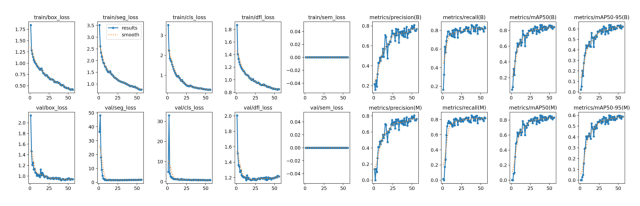

confusion_matrix.png


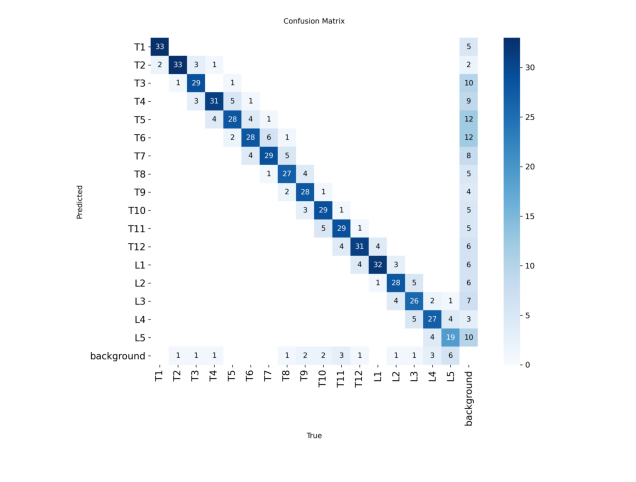

confusion_matrix_normalized.png


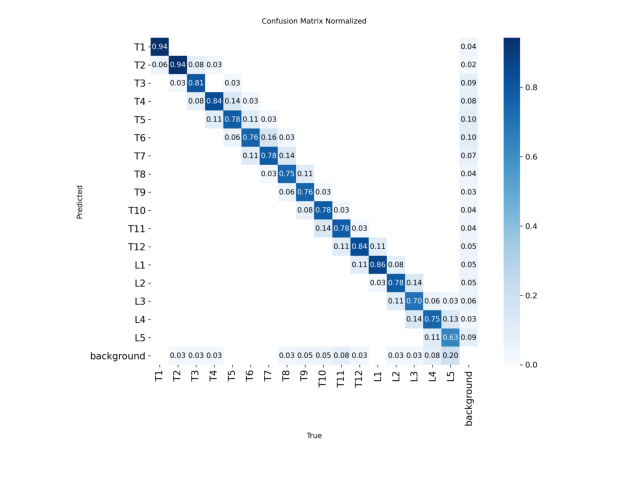

MaskPR_curve.png


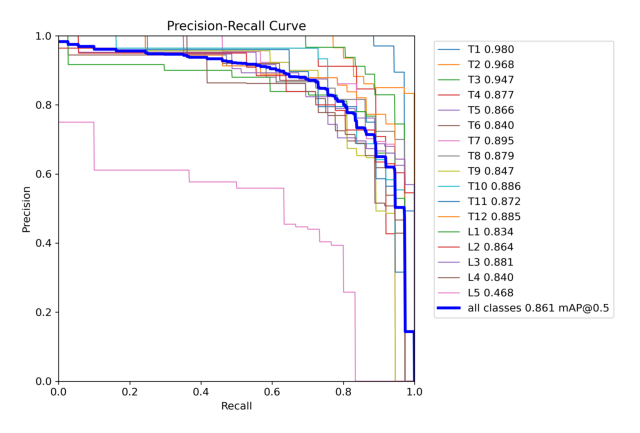

MaskF1_curve.png


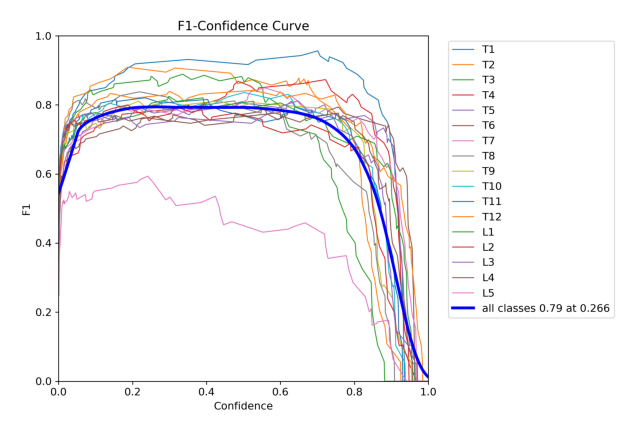

MaskP_curve.png


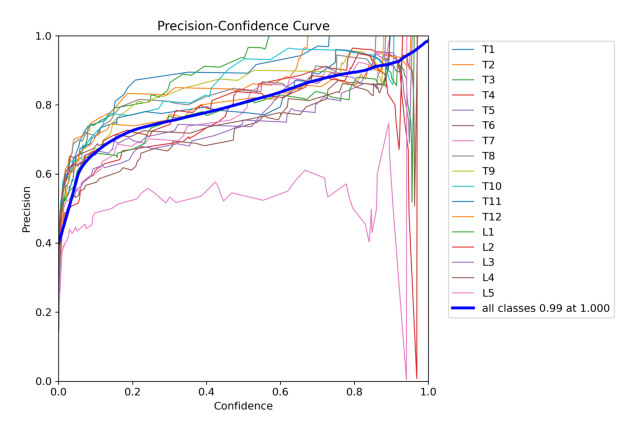

MaskR_curve.png


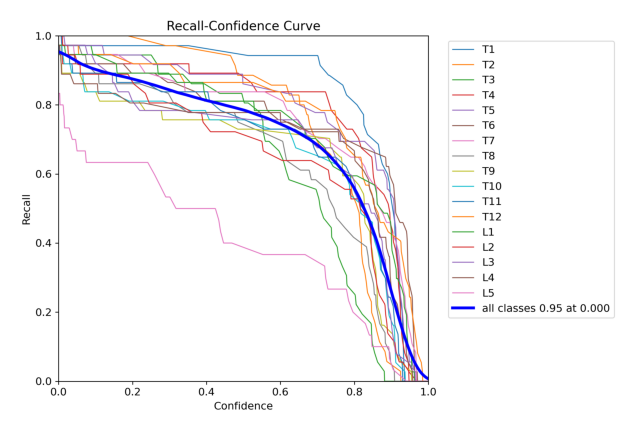

In [ ]:
# =========================================================
# Show Ultralytics-generated plots if present
# =========================================================

possible_plot_files = [
    RUN_DIR / "results.png",
    RUN_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix_normalized.png",
    RUN_DIR / "MaskPR_curve.png",
    RUN_DIR / "MaskF1_curve.png",
    RUN_DIR / "MaskP_curve.png",
    RUN_DIR / "MaskR_curve.png",
]

for plot_path in possible_plot_files:
    if plot_path.exists():
        print(plot_path.name)
        img = Image.open(plot_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

In [ ]:
# =========================================================
# Final artifacts for later sections
# =========================================================

BEST_MODEL_PATH = BEST_WEIGHTS_PATH
LAST_MODEL_PATH = LAST_WEIGHTS_PATH
TRAIN_RUN_DIR = RUN_DIR

print("BEST_MODEL_PATH =", BEST_MODEL_PATH)
print("LAST_MODEL_PATH =", LAST_MODEL_PATH)
print("TRAIN_RUN_DIR   =", TRAIN_RUN_DIR)

BEST_MODEL_PATH = /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights/best.pt
LAST_MODEL_PATH = /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights/last.pt
TRAIN_RUN_DIR   = /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42


In [ ]:
# =========================================================
# Inference config (single-image visualization)
# =========================================================

# This section is for practical single-image inference checks.
# It is separate from Ultralytics validation-grid visualizations.

INFERENCE_CONFIG = {
    # Model selection
    "model_source_mode": "current_run_best_if_available",
    # Options:
    # - "current_run_best_if_available"
    # - "current_run_last"
    # - "manual_path"

    "manual_model_path": None,

    # Sample selection
    "default_split": "test",   # "train", "val", or "test"
    "sample_index_within_split": 0,

    # Explicit predict settings
    "imgsz": ACTIVE_TRAIN_PARAMS["imgsz"],
    "conf_threshold": 0.10,
    "iou_threshold": 0.50,
    "max_det": 30,
    "agnostic_nms": False,
    "retina_masks": True,

    # Visualization
    "line_width": 3,
    "font_size": 16,

    # Saving
    "save_outputs": True,
    "output_subdir_name": "inference",
    "main_output_subdir_name": "main",
    "diagnostic_output_subdir_name": "diagnostics",
}

# Always save under the CURRENT run directory only
INFERENCE_OUTPUT_DIR = RUN_DIR / INFERENCE_CONFIG["output_subdir_name"]
INFERENCE_MAIN_OUTPUT_DIR = INFERENCE_OUTPUT_DIR / INFERENCE_CONFIG["main_output_subdir_name"]
INFERENCE_DIAGNOSTIC_OUTPUT_DIR = INFERENCE_OUTPUT_DIR / INFERENCE_CONFIG["diagnostic_output_subdir_name"]

if INFERENCE_CONFIG["save_outputs"]:
    INFERENCE_MAIN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    INFERENCE_DIAGNOSTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("INFERENCE_CONFIG")
print(json.dumps(INFERENCE_CONFIG, indent=2, ensure_ascii=False))
print("RUN_DIR:", RUN_DIR)
print("INFERENCE_OUTPUT_DIR:", INFERENCE_OUTPUT_DIR)
print("INFERENCE_MAIN_OUTPUT_DIR:", INFERENCE_MAIN_OUTPUT_DIR)
print("INFERENCE_DIAGNOSTIC_OUTPUT_DIR:", INFERENCE_DIAGNOSTIC_OUTPUT_DIR)

INFERENCE_CONFIG
{
  "model_source_mode": "current_run_best_if_available",
  "manual_model_path": null,
  "default_split": "test",
  "sample_index_within_split": 0,
  "imgsz": 960,
  "conf_threshold": 0.1,
  "iou_threshold": 0.5,
  "max_det": 30,
  "agnostic_nms": false,
  "retina_masks": true,
  "line_width": 3,
  "font_size": 16,
  "save_outputs": true,
  "output_subdir_name": "inference",
  "main_output_subdir_name": "main",
  "diagnostic_output_subdir_name": "diagnostics"
}
RUN_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42
INFERENCE_OUTPUT_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg1

In [ ]:
# =========================================================
# Visualization style config
# =========================================================

VIS_CONFIG = {
    "clean_overlay_alpha": 0.35,
    "save_clean_overlay": True,
    "save_labeled_prediction": True,
    "show_ground_truth_if_available": True,
}

print("VIS_CONFIG")
print(json.dumps(VIS_CONFIG, indent=2))

VIS_CONFIG
{
  "clean_overlay_alpha": 0.35,
  "save_clean_overlay": true,
  "save_labeled_prediction": true,
  "show_ground_truth_if_available": true
}


Resolved inference model path: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/weights/best.pt
Resolved inference model tag : current_run_best
Sample split                : test
Sample index                : 0
Source image                : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Normal/N_7.jpg
Inference imgsz             : 960
Inference conf_threshold    : 0.1
Inference iou_threshold     : 0.5
Inference max_det           : 30
Inference retina_masks      : True
Inference main output dir   : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_

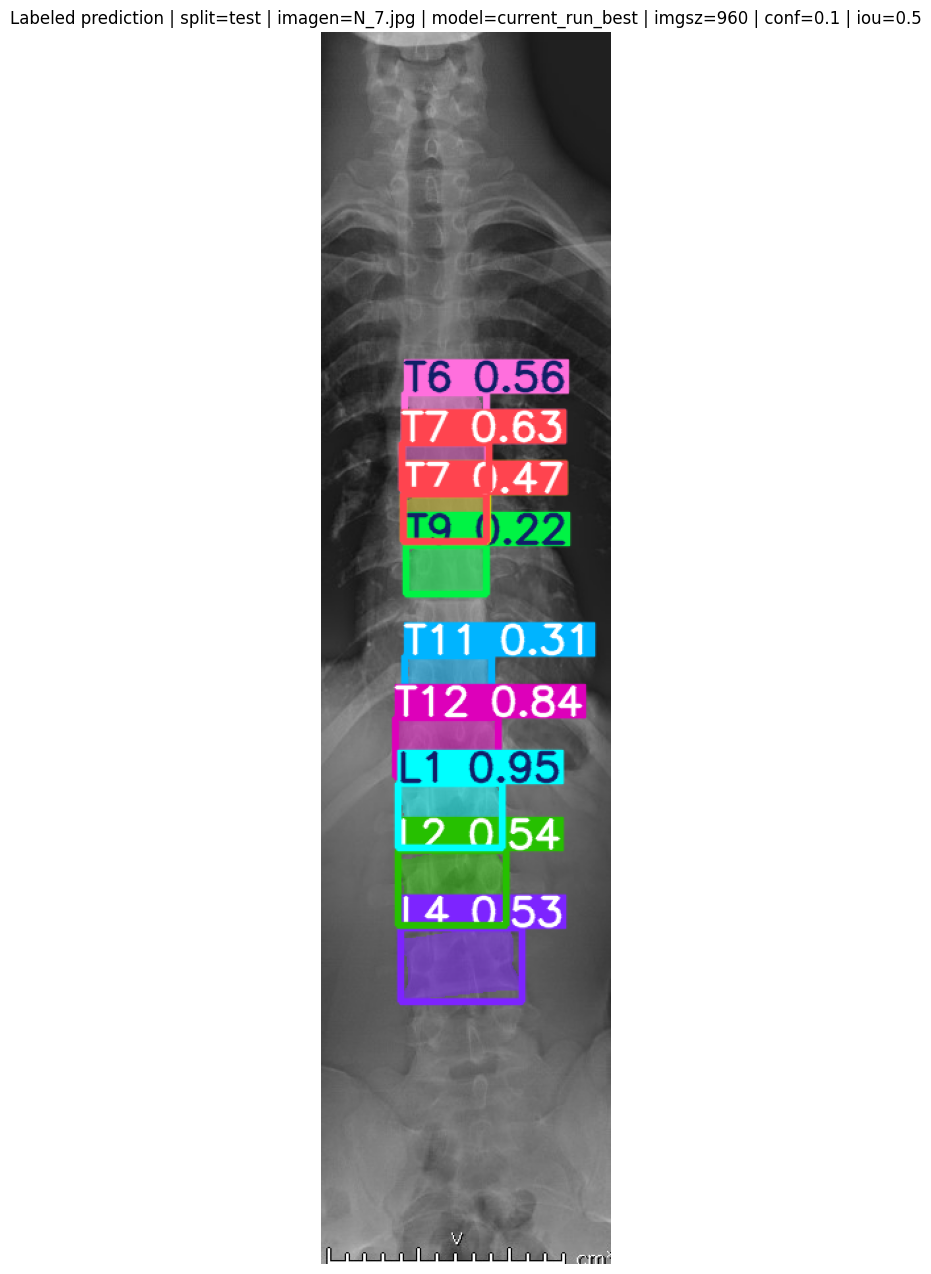

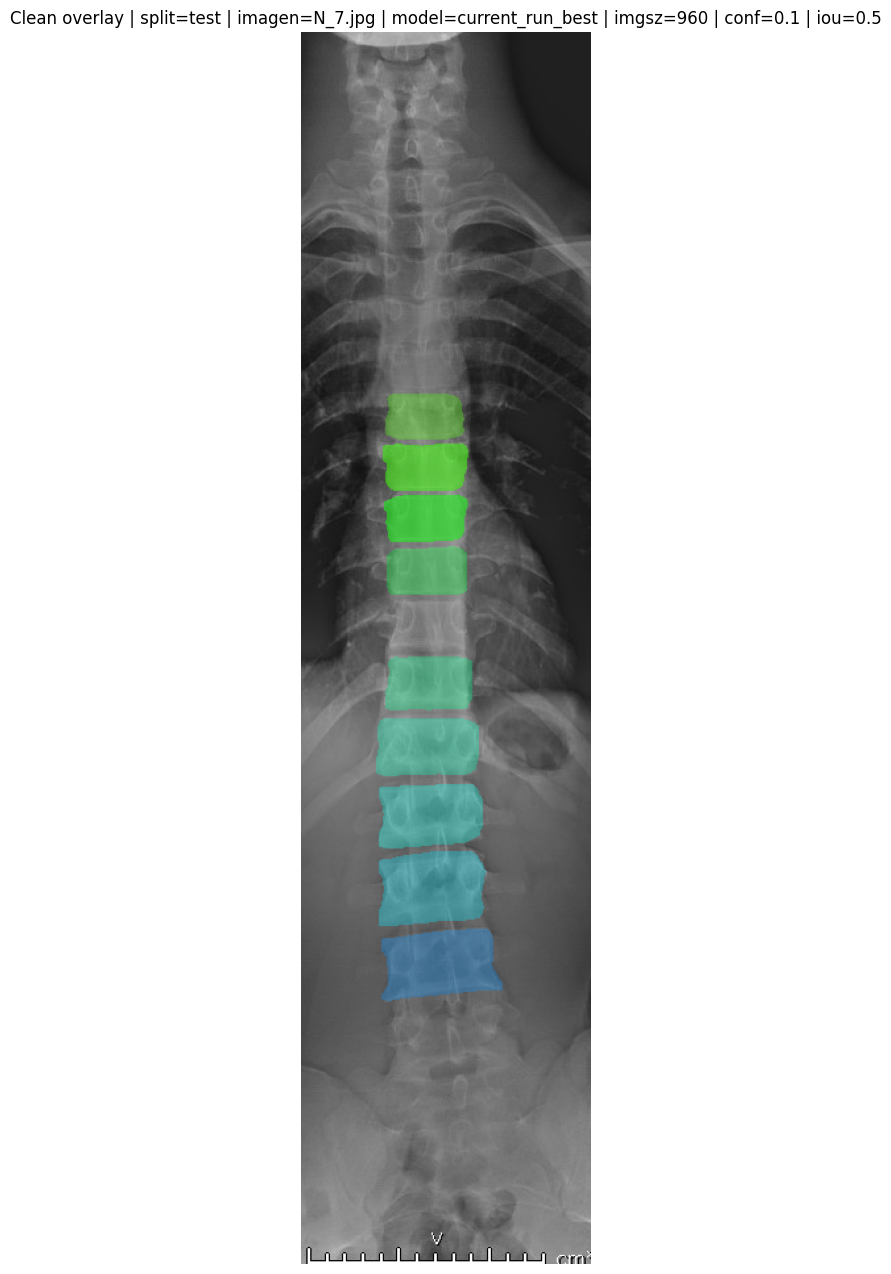

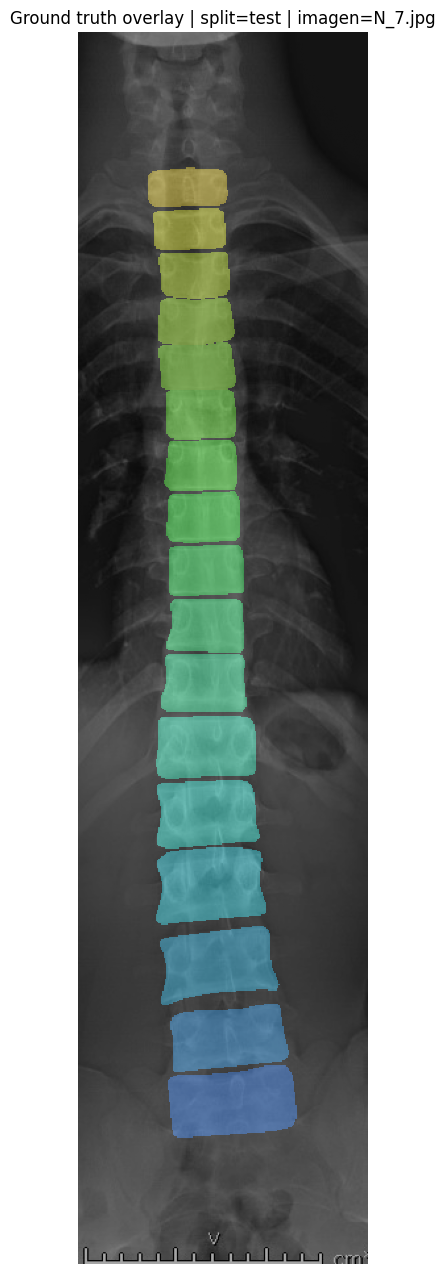

Saved labeled prediction: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/inference/main/N_7_current_run_best_imgsz960_conf0p1_iou0p5_pred_labeled.png
Saved clean overlay: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/inference/main/N_7_current_run_best_imgsz960_conf0p1_iou0p5_pred_clean_overlay.png

Predicted vertebrae:


,det_idx,class_id,class_name,confidence,x1,y1,x2,y2
0,3,5,T6,0.561543,63.778625,274.474304,125.025505,309.548431
1,7,5,T6,0.403524,61.094719,312.291656,126.766197,348.794220
2,2,6,T7,0.628374,61.112068,312.689392,127.148880,348.722229
3,6,6,T7,0.467135,62.343067,351.611572,125.835670,387.268646
4,8,7,T8,0.354378,62.169250,351.619141,126.310287,387.615204
5,10,8,T9,0.218064,64.446434,390.517761,125.835373,427.986816
6,9,10,T11,0.305530,63.062695,474.787964,129.739624,515.137756
7,1,11,T12,0.842595,56.617805,521.900146,134.385651,566.441345
8,0,12,L1,0.949423,58.705997,571.205750,137.658783,620.344299
9,4,13,L2,0.538932,58.504166,622.903076,140.458389,679.091980


Saved prediction table: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_seg_v11_corrected_masks_minfg10_pretrained_all_current_corrected_priority_minfg10_ignorelist_colab_strong_img960_seed42/inference/main/N_7_current_run_best_imgsz960_conf0p1_iou0p5_pred_table.csv


In [ ]:
# =========================================================
# Inference on one image at a time
# =========================================================

def get_manifest_for_split(split_name):
    if split_name == "train":
        return train_manifest
    elif split_name == "val":
        return val_manifest
    elif split_name == "test":
        return test_manifest
    else:
        raise ValueError(f"Unknown split: {split_name}")

def resolve_inference_model_path(cfg):
    mode = cfg["model_source_mode"]

    if mode == "current_run_best_if_available":
        best_path = Path(BEST_MODEL_PATH)
        last_path = Path(LAST_MODEL_PATH)

        if best_path.exists():
            return best_path, "current_run_best"
        elif last_path.exists():
            return last_path, "current_run_last_fallback"
        else:
            raise FileNotFoundError(
                f"Neither best nor last model exists.\nBEST_MODEL_PATH={BEST_MODEL_PATH}\nLAST_MODEL_PATH={LAST_MODEL_PATH}"
            )

    elif mode == "current_run_last":
        last_path = Path(LAST_MODEL_PATH)
        if last_path.exists():
            return last_path, "current_run_last"
        raise FileNotFoundError(f"LAST_MODEL_PATH does not exist: {LAST_MODEL_PATH}")

    elif mode == "manual_path":
        manual_path = cfg.get("manual_model_path")
        if manual_path in [None, ""]:
            raise ValueError("manual_path mode requires INFERENCE_CONFIG['manual_model_path'].")
        manual_path = Path(manual_path)
        if not manual_path.exists():
            raise FileNotFoundError(f"manual_model_path does not exist: {manual_path}")
        return manual_path, "manual_path"

    else:
        raise ValueError(f"Unknown model_source_mode: {mode}")

def build_clean_mask_overlay(base_image_path, result_obj, alpha=0.35):
    base_img = np.array(Image.open(base_image_path).convert("RGB")).astype(np.float32) / 255.0
    overlay = base_img.copy()
    h, w = base_img.shape[:2]

    if result_obj.masks is None or result_obj.boxes is None or len(result_obj.boxes) == 0:
        return (overlay * 255.0).astype(np.uint8)

    masks = result_obj.masks.data.cpu().numpy()
    classes = result_obj.boxes.cls.cpu().numpy().astype(int)

    for i in range(len(classes)):
        cls_id = int(classes[i])
        color = np.array(class_colors[min(cls_id + 1, 17)], dtype=np.float32)

        mask_i = masks[i].astype(np.float32)
        mask_i_resized = cv2.resize(
            mask_i,
            (w, h),
            interpolation=cv2.INTER_NEAREST
        ) > 0.5

        overlay[mask_i_resized] = (1 - alpha) * overlay[mask_i_resized] + alpha * color

    overlay = np.clip(overlay * 255.0, 0, 255).astype(np.uint8)
    return overlay

active_manifest = get_manifest_for_split(INFERENCE_CONFIG["default_split"]).reset_index(drop=True)
assert len(active_manifest) > 0, f"No rows found for split: {INFERENCE_CONFIG['default_split']}"

sample_idx = min(INFERENCE_CONFIG["sample_index_within_split"], len(active_manifest) - 1)
sample_row = active_manifest.iloc[sample_idx]

inference_model_path, inference_model_tag = resolve_inference_model_path(INFERENCE_CONFIG)

print("Resolved inference model path:", inference_model_path)
print("Resolved inference model tag :", inference_model_tag)
print("Sample split                :", INFERENCE_CONFIG["default_split"])
print("Sample index                :", sample_idx)
print("Source image                :", sample_row["image_path"])
print("Inference imgsz             :", INFERENCE_CONFIG["imgsz"])
print("Inference conf_threshold    :", INFERENCE_CONFIG["conf_threshold"])
print("Inference iou_threshold     :", INFERENCE_CONFIG["iou_threshold"])
print("Inference max_det           :", INFERENCE_CONFIG["max_det"])
print("Inference retina_masks      :", INFERENCE_CONFIG["retina_masks"])
print("Inference main output dir   :", INFERENCE_MAIN_OUTPUT_DIR)

inference_model = YOLO(str(inference_model_path))
results = inference_model.predict(
    source=str(sample_row["image_path"]),
    imgsz=INFERENCE_CONFIG["imgsz"],
    conf=INFERENCE_CONFIG["conf_threshold"],
    iou=INFERENCE_CONFIG["iou_threshold"],
    max_det=INFERENCE_CONFIG["max_det"],
    agnostic_nms=INFERENCE_CONFIG["agnostic_nms"],
    retina_masks=INFERENCE_CONFIG["retina_masks"],
    save=False,
    verbose=False,
)

assert len(results) > 0, "No inference results returned."
result = results[0]

num_boxes = 0 if result.boxes is None else len(result.boxes)
num_masks = 0 if result.masks is None else len(result.masks)

print("\nPrediction object summary:")
print("num_boxes:", num_boxes)
print("num_masks:", num_masks)

annotated_bgr = result.plot(
    conf=True,
    labels=True,
    line_width=INFERENCE_CONFIG["line_width"],
    font_size=INFERENCE_CONFIG["font_size"],
)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 16))
plt.imshow(annotated_rgb)
plt.title(
    f"Labeled prediction | split={INFERENCE_CONFIG['default_split']} | "
    f"imagen={sample_row['imagen']} | model={inference_model_tag} | "
    f"imgsz={INFERENCE_CONFIG['imgsz']} | conf={INFERENCE_CONFIG['conf_threshold']} | "
    f"iou={INFERENCE_CONFIG['iou_threshold']}"
)
plt.axis("off")
plt.show()

clean_overlay_rgb = build_clean_mask_overlay(
    base_image_path=str(sample_row["image_path"]),
    result_obj=result,
    alpha=VIS_CONFIG["clean_overlay_alpha"],
)

plt.figure(figsize=(12, 16))
plt.imshow(clean_overlay_rgb)
plt.title(
    f"Clean overlay | split={INFERENCE_CONFIG['default_split']} | "
    f"imagen={sample_row['imagen']} | model={inference_model_tag} | "
    f"imgsz={INFERENCE_CONFIG['imgsz']} | conf={INFERENCE_CONFIG['conf_threshold']} | "
    f"iou={INFERENCE_CONFIG['iou_threshold']}"
)
plt.axis("off")
plt.show()

if VIS_CONFIG.get("show_ground_truth_if_available", True) and "multiclass_mask_path" in sample_row.index:
    gt_img = load_image_grayscale(sample_row["image_path"])
    gt_mask = load_mask_multiclass_id(sample_row["multiclass_mask_path"])

    plt.figure(figsize=(12, 16))
    plt.imshow(gt_img, cmap="gray")
    plt.imshow(gt_mask, cmap=vertebra_cmap, alpha=0.35, interpolation="nearest", vmin=0, vmax=17)
    plt.title(
        f"Ground truth overlay | split={INFERENCE_CONFIG['default_split']} | "
        f"imagen={sample_row['imagen']}"
    )
    plt.axis("off")
    plt.show()

if INFERENCE_CONFIG["save_outputs"]:
    stem = Path(str(sample_row["imagen"])).stem
    save_stub = (
        f"{stem}_{inference_model_tag}"
        f"_imgsz{INFERENCE_CONFIG['imgsz']}"
        f"_conf{str(INFERENCE_CONFIG['conf_threshold']).replace('.', 'p')}"
        f"_iou{str(INFERENCE_CONFIG['iou_threshold']).replace('.', 'p')}"
    )

    labeled_out_path = INFERENCE_MAIN_OUTPUT_DIR / f"{save_stub}_pred_labeled.png"
    clean_out_path = INFERENCE_MAIN_OUTPUT_DIR / f"{save_stub}_pred_clean_overlay.png"

    if VIS_CONFIG.get("save_labeled_prediction", True):
        Image.fromarray(annotated_rgb).save(labeled_out_path)
        print("Saved labeled prediction:", labeled_out_path)

    if VIS_CONFIG.get("save_clean_overlay", True):
        Image.fromarray(clean_overlay_rgb).save(clean_out_path)
        print("Saved clean overlay:", clean_out_path)

pred_rows = []
names_map = result.names if hasattr(result, "names") else {}

if result.boxes is not None and len(result.boxes) > 0:
    boxes_xyxy = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for i in range(len(classes)):
        cls_id = int(classes[i])
        cls_name = names_map.get(cls_id, str(cls_id))
        x1, y1, x2, y2 = boxes_xyxy[i].tolist()

        pred_rows.append({
            "det_idx": i,
            "class_id": cls_id,
            "class_name": cls_name,
            "confidence": float(confs[i]),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
        })

pred_df = (
    pd.DataFrame(pred_rows)
    .sort_values(["class_id", "confidence"], ascending=[True, False])
    .reset_index(drop=True)
    if len(pred_rows) > 0 else pd.DataFrame()
)

print("\nPredicted vertebrae:")
display(pred_df)

if INFERENCE_CONFIG["save_outputs"]:
    pred_csv_path = INFERENCE_MAIN_OUTPUT_DIR / f"{save_stub}_pred_table.csv"
    pred_df.to_csv(pred_csv_path, index=False)
    print("Saved prediction table:", pred_csv_path)

In [ ]:
# =========================================================
# Confidence-threshold diagnostic on the same fixed image
# =========================================================

THRESHOLD_DIAG_CONFIG = {
    "enabled": False,   # keep optional; turn on only when needed
    "thresholds": [0.03, 0.05, 0.10, 0.20, 0.30],
    "save_outputs": True,
}

if THRESHOLD_DIAG_CONFIG["enabled"]:
    diag_model_path, diag_model_tag = resolve_inference_model_path(INFERENCE_CONFIG)
    diag_model = YOLO(str(diag_model_path))

    diag_rows = []
    diag_sample_path = str(sample_row["image_path"])
    diag_stem = Path(str(sample_row["imagen"])).stem

    print("Running threshold diagnostic")
    print("Model :", diag_model_path)
    print("Image :", diag_sample_path)
    print("Diagnostic output dir:", INFERENCE_DIAGNOSTIC_OUTPUT_DIR)

    for thr in THRESHOLD_DIAG_CONFIG["thresholds"]:
        diag_results = diag_model.predict(
            source=diag_sample_path,
            imgsz=INFERENCE_CONFIG["imgsz"],
            conf=thr,
            iou=INFERENCE_CONFIG["iou_threshold"],
            max_det=INFERENCE_CONFIG["max_det"],
            agnostic_nms=INFERENCE_CONFIG["agnostic_nms"],
            retina_masks=INFERENCE_CONFIG["retina_masks"],
            save=False,
            verbose=False,
        )

        diag_result = diag_results[0]
        diag_num_boxes = 0 if diag_result.boxes is None else len(diag_result.boxes)
        diag_num_masks = 0 if diag_result.masks is None else len(diag_result.masks)

        diag_classes = []
        diag_conf_list = []

        if diag_result.boxes is not None and len(diag_result.boxes) > 0:
            diag_classes = diag_result.boxes.cls.cpu().numpy().astype(int).tolist()
            diag_conf_list = diag_result.boxes.conf.cpu().numpy().tolist()

        unique_classes = sorted(set(diag_classes))

        diag_rows.append({
            "threshold": thr,
            "iou_threshold": INFERENCE_CONFIG["iou_threshold"],
            "num_boxes": diag_num_boxes,
            "num_masks": diag_num_masks,
            "num_unique_classes": len(unique_classes),
            "unique_class_ids": unique_classes,
            "max_conf": float(max(diag_conf_list)) if len(diag_conf_list) > 0 else np.nan,
            "min_conf": float(min(diag_conf_list)) if len(diag_conf_list) > 0 else np.nan,
        })

        annotated_bgr = diag_result.plot(
            conf=True,
            labels=True,
            line_width=INFERENCE_CONFIG["line_width"],
            font_size=INFERENCE_CONFIG["font_size"],
        )
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 14))
        plt.imshow(annotated_rgb)
        plt.title(
            f"Threshold diagnostic | imagen={sample_row['imagen']} | "
            f"model={diag_model_tag} | imgsz={INFERENCE_CONFIG['imgsz']} | "
            f"conf={thr} | iou={INFERENCE_CONFIG['iou_threshold']}"
        )
        plt.axis("off")
        plt.show()

        if THRESHOLD_DIAG_CONFIG["save_outputs"] and INFERENCE_CONFIG["save_outputs"]:
            thr_stub = str(thr).replace(".", "p")
            diag_out_path = INFERENCE_DIAGNOSTIC_OUTPUT_DIR / (
                f"{diag_stem}_{diag_model_tag}_imgsz{INFERENCE_CONFIG['imgsz']}"
                f"_conf{thr_stub}_iou{str(INFERENCE_CONFIG['iou_threshold']).replace('.', 'p')}.png"
            )
            Image.fromarray(annotated_rgb).save(diag_out_path)
            print("Saved threshold diagnostic image:", diag_out_path)

    threshold_diag_df = pd.DataFrame(diag_rows)
    print("\nThreshold diagnostic summary:")
    display(threshold_diag_df)

    if THRESHOLD_DIAG_CONFIG["save_outputs"] and INFERENCE_CONFIG["save_outputs"]:
        threshold_diag_csv_path = INFERENCE_DIAGNOSTIC_OUTPUT_DIR / (
            f"{diag_stem}_{diag_model_tag}_imgsz{INFERENCE_CONFIG['imgsz']}"
            f"_threshold_diagnostic.csv"
        )
        threshold_diag_df.to_csv(threshold_diag_csv_path, index=False)
        print("Saved threshold diagnostic CSV:", threshold_diag_csv_path)
else:
    print("Threshold diagnostic is disabled. Set THRESHOLD_DIAG_CONFIG['enabled'] = True when needed.")

Threshold diagnostic is disabled. Set THRESHOLD_DIAG_CONFIG['enabled'] = True when needed.


In [ ]:
print("Section 4 complete.")

print("\nMain artifact paths:")
print("PROJECT_ROOT       :", PROJECT_ROOT)
print("YOLO_EXPORT_BASE_ROOT:", YOLO_EXPORT_BASE_ROOT)
print("YOLO_DATASET_VARIANT :", YOLO_DATASET_VARIANT)
print("YOLO_ROOT          :", YOLO_ROOT)
print("TRAINING_RUNS_ROOT :", TRAINING_RUNS_ROOT)
print("RUN_DIR            :", RUN_DIR)
print("BEST_MODEL_PATH    :", BEST_MODEL_PATH)
print("LAST_MODEL_PATH    :", LAST_MODEL_PATH)
print("RESULTS_CSV_PATH   :", RESULTS_CSV_PATH)
print("ARGS_YAML_PATH     :", ARGS_YAML_PATH)
print("training_summary   :", training_summary_path)